# PERFECT4 — v11 LOCKED + Strict Text Price Extractor

This version keeps the proven v11 feature/model pipeline locked, then adds one narrow, auditable post-processing layer: extracting explicit prices already present in `title` / `features_list` using the same deterministic rules for train and test. No sample-submission prices, no IDs, no external lookup, no hand labels.

# FITE Car Price Prediction — v11 Stable v8 + Validation-Tuned High-Tail

هذه النسخة تبدأ من v8-safe الذي أعطى أفضل score فعلياً، ولا ترجع إلى v10/v9.

الجديد:
1. **Stability guard**: إذا اختار OOF إعدادات مختلفة بفارق ضعيف، نعود تلقائياً إلى إعدادات v8 المعروفة بدلاً من الانجراف بسبب noise.
2. **Super-tail postprocess**: تعديل صغير جداً ومختار من OOF فقط للسيارات عالية الاحتمال/الفاخرة، بهدف تحسين R2 بدون tuning على leaderboard.

لا يوجد استخدام لـ test labels أو sample_submission prices أو أي external lookup.


## 0. Imports and configuration

In [1]:

# Core
import os
import re
import math
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 160)
pd.set_option('display.max_rows', 220)
pd.set_option('display.max_colwidth', 140)

# Scikit-learn
from sklearn.base import clone
from sklearn.model_selection import KFold, GroupKFold, GroupShuffleSplit
try:
    from sklearn.model_selection import StratifiedGroupKFold
except Exception:
    StratifiedGroupKFold = None

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error, roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MaxAbsScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDRegressor, SGDClassifier, Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neighbors import NearestNeighbors

try:
    from catboost import CatBoostRegressor, CatBoostClassifier, Pool
    CATBOOST_AVAILABLE = True
except Exception as e:
    print("CatBoost import failed; CatBoost models will be disabled:", repr(e))
    CATBOOST_AVAILABLE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -----------------------
# Main experiment settings
# -----------------------
# R2 is the new official metric, confirmed by the TA.
PRIMARY_METRIC = 'r2'

# Use more folds than before and stratify by log-price when possible.
# This reduces fold-to-fold price distribution noise, which is important for R2.
N_SPLITS = 5
CV_STRATEGY = 'stratified_group'  # 'stratified_group', 'group', or 'kfold'
PRICE_BIN_Q = 8

# Robust training filter.
# The train file contains a multi-million suspicious dealer row. It can dominate R2,
# but it is not representative of normal used-car prices.
MIN_TRAIN_PRICE = 500
MAX_TRAIN_PRICE = 500_000

# Prediction clipping is tuned indirectly through validation candidates.
PRED_CLIP_LOW = 500
PRED_CLIP_HIGH = 300_000

# v5: allow validation to cap risky/non-sale ad patterns.
ENABLE_LOW_VALUE_AD_CAPS = True

# v6: feature-engineering/modeling improvements from the validation diagnostics.
# All features are derived only from the official train/test columns.
ENABLE_OOF_TARGET_ENCODING = True
ENABLE_ODOMETER_GROUP_RATIOS = True
TARGET_ENCODING_SMOOTHING = 12.0
TARGET_ENCODING_COLS = [
    'make_fe', 'model_fe', 'make_model_fe',
    'label_make_s1', 'label_model_s1', 'vehicle_value_bucket_v3'
]
TARGET_ENCODING_N_SPLITS = 5

# Extra robust raw-price learners. They are kept as candidates and selected only by OOF validation.
RUN_HUBER_RAW_MODELS = True



# v7: validation-safe local-neighborhood and grouped-imputation features.
# KNN price features are created OOF for train rows and from full train for test rows.
ENABLE_SMART_GROUP_IMPUTATION = True
ENABLE_KNN_PRICE_FEATURES = True
KNN_PRICE_NEIGHBORS = [3, 5, 10, 20]
KNN_PRICE_MAX_NEIGHBORS = max(KNN_PRICE_NEIGHBORS)
KNN_DISTANCE_METRIC = 'cosine'

# Validation selection mode.
# PUBLIC leaderboard must not be used for choosing parameters. However, using test FEATURES
# without labels to build a more test-like validation weighting is allowed and helps when
# train/test feature distributions differ.
USE_TEST_LIKE_FEATURES = True
SELECTION_MODE = 'testlike_blended_r2'  # 'r2' or 'testlike_blended_r2'
TESTLIKE_SCORE_WEIGHT = 0.65           # selection_score = 0.35*R2 + 0.65*test-like weighted R2


# -----------------------
# v8 LLM semantic features
# -----------------------
# Default: use existing CSV cache and do NOT call Groq again.
USE_LLM_FEATURES = True
RUN_LLM_EXTRACTION = False
LLM_CACHE_PATH = Path('groq_targeted_semantic_features.csv')

# v8-safe LLM integration controls.
# Do not feed raw LLM categories/booleans directly to all base models by default.
# The previous FINAL did that and public score dropped.
LLM_INTEGRATION_MODE = 'safe_numeric_only'  # choices: 'off', 'safe_numeric_only', 'raw_experimental'
LLM_ALLOW_RULE_FLAG_OVERRIDE = False
LLM_USE_NOISY_FINANCE_FLAG = False

LLM_MAX_NEW_ROWS_PER_RUN = 150
LLM_MAX_CHARS_PER_ROW = 3500
LLM_SLEEP_SECONDS = 0.15
LLM_RETRY_ATTEMPTS = 3
LLM_RETRY_BASE_SLEEP = 5
GROQ_MODEL = os.getenv('GROQ_MODEL', 'llama-3.1-8b-instant')
# Prefer environment/file key. You may set this manually only on your local machine if you choose to rerun extraction.
GROQ_API_KEY = os.getenv('GROQ_API_KEY', '')
LOCAL_GROQ_KEY_FILE = Path('groq_api_key.txt')


# -----------------------
# v11 stability settings
# -----------------------
USE_STABILITY_GUARD = True
STABILITY_MIN_SELECTION_GAIN = 0.010  # require meaningful validation gain before abandoning known-good v8 params
USE_SUPER_TAIL_POSTPROCESS = True

# Known-good params from v8-safe run that scored about 0.159 public R2.
KNOWN_GOOD_V8_PARAMS = {
    'w_sgd_alt': 0.10,
    'w_sgd_raw': 0.05,
    'w_sgd_huber': 0.05,
    'w_log_cat': 0.30,
    'w_raw_cat': 0.10,
    'w_huber_cat': 0.10,
    'w_knn': 0.00,
    'tau50': 0.35,
    'tau100': 0.35,
    'alpha': 0.00,
    'uplift': 1.15,
    'min_pred_for_uplift': 40_000.0,
    'max_pred_cap': 240_000.0,
    'low_value_cap': None,
    'nonsale_cap': None,
}

# Text representation
TITLE_MAX_FEATURES = 4_000
DESC_MAX_FEATURES = 12_000
CHAR_MAX_FEATURES = 6_000

RUN_CATBOOST = CATBOOST_AVAILABLE
RUN_TABULAR_MODEL = False
RUN_HEAVY_MODELS = False

CAT_VERBOSE = 100
CAT_VERBOSE_CV = False

# Base model hyperparameters.
# This version adds a raw-price SGD and an alternate log-SGD so validation/stacking can choose.
BASE_MODEL_PARAMS = {
    # Main log-target SGD
    'sgd_alpha': 2e-5,
    'sgd_l1_ratio': 0.10,
    'sgd_max_iter': 5000,

    # Alternate log-target SGD. It often behaves differently enough to help stacking.
    'sgd_alt_alpha': 8e-5,
    'sgd_alt_l1_ratio': 0.10,

    # Raw-price SGD. R2 is an absolute-price metric, so a raw-target text model can help.
    'sgd_raw_alpha': 1e-4,
    'sgd_raw_l1_ratio': 0.05,

    # Robust raw-price SGD using Huber loss.
    # This follows the course idea that changing the loss function can reduce outlier sensitivity.
    'sgd_huber_alpha': 8e-5,
    'sgd_huber_l1_ratio': 0.05,
    'sgd_huber_epsilon': 4500.0,

    # Sample weighting for expensive vehicles
    'weight_exponent': 0.95,
    'weight_clip': 14.0,

    # CatBoost log-price model
    'cat_log_iterations': 900,
    'cat_log_lr': 0.025,
    'cat_log_depth': 5,
    'cat_log_l2': 10,

    # CatBoost raw-price model
    'cat_raw_iterations': 600,
    'cat_raw_lr': 0.025,
    'cat_raw_depth': 4,
    'cat_raw_l2': 25,

    # Robust CatBoost raw-price model. Huber avoids letting a few extreme ads dominate.
    'cat_huber_iterations': 700,
    'cat_huber_lr': 0.025,
    'cat_huber_depth': 4,
    'cat_huber_l2': 35,
    'cat_huber_delta': 8000.0,

    # High-price classifiers
    'cat_clf_iterations': 500,
    'cat_clf_lr': 0.03,
    'cat_clf_depth': 4,
    'cat_clf_l2': 20,

    # High-value specialist regressor
    'cat_specialist_iterations': 600,
    'cat_specialist_lr': 0.025,
    'cat_specialist_depth': 3,
    'cat_specialist_l2': 35,
    'specialist_min_price': 30_000,
}


## 1. Load the new official train/test/sample files

In [2]:

def find_file(filename, search_roots=None):
    """Find a competition file in common local/Kaggle paths."""
    if search_roots is None:
        search_roots = [
            Path('.'),
            Path('/Users/fangyuan/Desktop/new/data'),
            Path('/kaggle/working'),
            Path('/kaggle/input'),
            Path('/mnt/data'),
        ]
    for root in search_roots:
        if not root.exists():
            continue
        direct = root / filename
        if direct.exists():
            return direct
        # Search one level deep first, then recursively if needed.
        for p in root.glob(f'*/{filename}'):
            if p.exists():
                return p
        for p in root.rglob(filename):
            if p.exists():
                return p
    raise FileNotFoundError(f"Could not find {filename}. Put it next to the notebook or under /kaggle/input.")

train_path = find_file('train_data.csv')
test_path = find_file('test_data.csv')
sub_path = find_file('sample_submission.csv')

print('train:', train_path)
print('test :', test_path)
print('sub  :', sub_path)

train_raw = pd.read_csv(train_path)
test_raw = pd.read_csv(test_path)
sample_submission = pd.read_csv(sub_path)

print('train shape:', train_raw.shape)
print('test shape :', test_raw.shape)
print('sample shape:', sample_submission.shape)

display(train_raw.head(3))
display(test_raw.head(3))
display(sample_submission.head(3))


train: data/train_data.csv
test : data/test_data.csv
sub  : data/sample_submission.csv
train shape: (784, 28)
test shape : (278, 27)
sample shape: (278, 2)


,ID,condition,cylinders,drive,engine,est._monthly_pmt,ext_color,feature_count,features_list,fuel,image_count,int_color,make,mileage,model,odometer,paint_color,price,scrape_timestamp,search_price,title,title_status,trans,transmission,trim,type,vin,year
0,1,like new,3 cylinders,4wd,NaN,NaN,NaN,1,"QR Code Link to This Post\r\n\r\n\r\n\r\nCACTUS GREY W/ BLACK INTERIOR\r\n\r\nKeyless Entry\r\n17"" Alloy Wheels\r\nSatellite Radio\r\nCl...",gas,4,NaN,NaN,NaN,NaN,60700.0,grey,18500,2026-06-23T20:52:06.693266,NaN,2021 Ford Bronco Sport,clean,NaN,automatic,NaN,SUV,NaN,NaN
1,2,NaN,4 cylinders,rwd,NaN,NaN,NaN,1,QR Code Link to This Post\r \r \r \r Autotrader Private Seller - 2004 Ford Ranger XL -- $Vehicle Information: 2004 Ford Ranger XL Price:...,gas,7,NaN,*Ford** Model: *Ranger** Series: *XL** Body Style: Truck* VIN:...,288,*Ranger** Series: *XL** Body Style: Truck* VIN:...,288977.0,NaN,3999,2026-06-23T20:52:10.857962,NaN,2004 Ford Ranger,clean,NaN,other,NaN,truck,1FTYR10DX4PA32355,2004* Make: *Ford** Model: *Ranger** Series: *XL** Body Style: Truck* VIN:...
2,3,NaN,8 cylinders,rwd,NaN,NaN,NaN,1,QR Code Link to This Post\r \r \r \r Autotrader Private Seller - 2004 Ford F-150 Lariat -- $Vehicle Information: 2004 Ford F-150 Lariat ...,gas,13,NaN,*Ford** Model: *F-150** Series: *Lariat** Body Style: Truck*...,247,*F-150** Series: *Lariat** Body Style: Truck*...,247619.0,white,4999,2026-06-23T20:52:14.989644,NaN,2004 Ford F-150,clean,NaN,other,NaN,truck,1FTPW12534KC63718,2004* Make: *Ford** Model: *F-150** Series: *Lariat** Body Style: Truck*...


,ID,condition,cylinders,drive,engine,est._monthly_pmt,ext_color,feature_count,features_list,fuel,image_count,int_color,make,mileage,model,odometer,paint_color,scrape_timestamp,search_price,title,title_status,trans,transmission,trim,type,vin,year
0,1001,NaN,NaN,NaN,NaN,NaN,NaN,1,QR Code Link to This Post\r\n\r\n\r\n\r\n1965 Ford Mustang Fastback ���� Timeless American muscle with the perfect look and sound. Power...,gas,22,NaN,NaN,NaN,NaN,83489,NaN,2026-06-23T17:50:50.589255,NaN,1965 Ford Mustang Fastback,clean,NaN,automatic,NaN,other,NaN,NaN
1,1002,NaN,6 cylinders,fwd,NaN,NaN,NaN,1,QR Code Link to This Post\r \r \r \r 2002 Chevrolet Monte Carlo SS Pace Car Edition CoupePrice: .00Atomic Motors Classic Cars & Motorcyc...,gas,24,NaN,NaN,NaN,NaN,64131,yellow,2026-06-23T17:51:12.751196,NaN,2002 Chevrolet Monte Carlo SS Pace Car Edition SKU:AA1026 Coupe,clean,NaN,automatic,NaN,coupe,NaN,NaN
2,1003,NaN,NaN,NaN,NaN,NaN,NaN,1,QR Code Link to This Post\r \r \r \r - 350 GM crate motor (L-43 - approx 320 hp with headers and manifold)\r - Muncie M-20 4-speed trans...,gas,18,NaN,NaN,NaN,NaN,61950,NaN,2026-06-23T17:51:25.520115,NaN,1968 Chevelle 300 post,clean,NaN,manual,NaN,NaN,NaN,NaN


,ID,price
0,1001,93751
1,1002,92626
2,1003,8702


## 2. Format sanity checks

In [3]:

assert 'price' in train_raw.columns, "train_data.csv must contain price."
assert 'price' not in test_raw.columns, "test_data.csv should not contain price."
assert list(sample_submission.columns) == ['ID', 'price'], "sample_submission.csv should have ID,price columns."
assert len(test_raw) == len(sample_submission), "test and sample_submission row counts must match."
assert test_raw['ID'].tolist() == sample_submission['ID'].tolist(), "sample_submission IDs are not aligned with test IDs."

common_cols = [c for c in train_raw.columns if c != 'price']
assert common_cols == list(test_raw.columns), "Train/test columns differ after removing price."

print('All format checks passed.')


All format checks passed.


## 3. EDA audit and target/outlier inspection

In [4]:

def audit_table(train_df, test_df):
    rows = []
    for col in train_df.columns:
        rows.append({
            'column': col,
            'train_dtype': str(train_df[col].dtype),
            'in_test': col in test_df.columns,
            'train_missing': int(train_df[col].isna().sum()),
            'train_missing_pct': float(train_df[col].isna().mean() * 100),
            'test_missing': int(test_df[col].isna().sum()) if col in test_df.columns else np.nan,
            'test_missing_pct': float(test_df[col].isna().mean() * 100) if col in test_df.columns else np.nan,
            'train_unique': int(train_df[col].nunique(dropna=True)),
            'test_unique': int(test_df[col].nunique(dropna=True)) if col in test_df.columns else np.nan,
            'example_values': '; '.join(train_df[col].dropna().astype(str).head(2).tolist())
        })
    return pd.DataFrame(rows).sort_values('train_missing_pct', ascending=False)

profile = audit_table(train_raw, test_raw)
display(profile)


,column,train_dtype,in_test,train_missing,train_missing_pct,test_missing,test_missing_pct,train_unique,test_unique,example_values
19,search_price,float64,True,784,100.000000,278.0,100.000000,0,0.0,
5,est._monthly_pmt,object,True,782,99.744898,275.0,98.920863,1,3.0,$1; $1
11,int_color,object,True,778,99.234694,278.0,100.000000,6,0.0,Brown Power Door...; Gray Ext Color: White Power...
6,ext_color,object,True,778,99.234694,278.0,100.000000,6,0.0,Gray Int Color: Brown Power Door...; White Power...
22,trans,object,True,750,95.663265,278.0,100.000000,21,0.0,Auto; Automatic
24,trim,object,True,719,91.709184,278.0,100.000000,59,0.0,740i Sedan 4D Mileage: 107; Van 3D Mileage: 98
14,model,object,True,715,91.198980,277.0,99.640288,69,1.0,*Ranger** Series: *XL** Body Style: Truck* VIN:...; *F-150** Series: *Lariat** Body Style: Truck*...
27,year,object,True,711,90.688776,278.0,100.000000,73,0.0,2004* Make: *Ford** Model: *Ranger** Series: *XL** Body Style: Truck* VIN:...; 2004* Make: *Ford** Model: *F-150** Series: *Lariat** Bod...
12,make,object,True,707,90.178571,278.0,100.000000,76,0.0,*Ford** Model: *Ranger** Series: *XL** Body Style: Truck* VIN:...; *Ford** Model: *F-150** Series: *Lariat** Body Style: Truck*...
4,engine,object,True,701,89.413265,265.0,95.323741,73,13.0,6-Cyl; V6


Target missing: 0
Target non-missing: 784
Target <= 0: 1
Target <= 100: 5
Target > 100k: 9
Target > 1M: 1


,price
count,7.840000e+02
mean,2.315409e+04
std,2.065775e+05
min,0.000000e+00
1%,9.415000e+02
5%,2.400000e+03
10%,3.000000e+03
25%,4.995000e+03
50%,9.500000e+03
75%,1.912300e+04


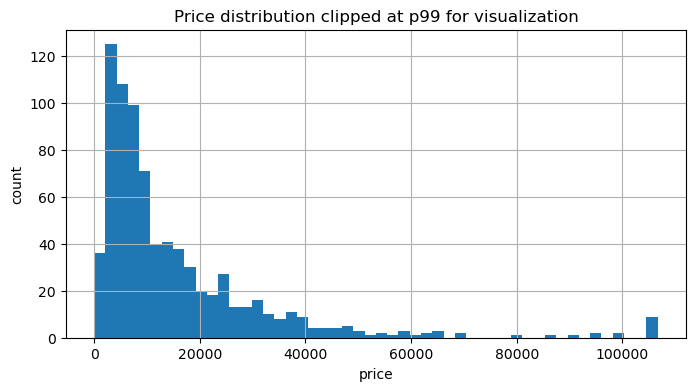

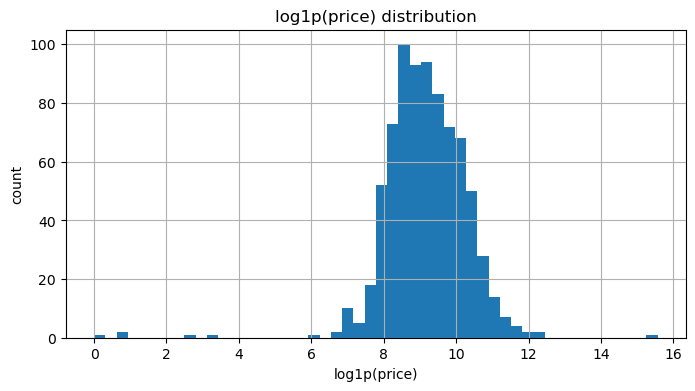

In [5]:

# Target distribution and suspicious values
y_all = train_raw['price']
print('Target missing:', int(y_all.isna().sum()))
print('Target non-missing:', int(y_all.notna().sum()))
print('Target <= 0:', int((y_all.fillna(np.nan) <= 0).sum()))
print('Target <= 100:', int((y_all.fillna(np.nan) <= 100).sum()))
print('Target > 100k:', int((y_all.fillna(np.nan) > 100_000).sum()))
print('Target > 1M:', int((y_all.fillna(np.nan) > 1_000_000).sum()))

display(y_all.describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99]).to_frame('price'))

plt.figure(figsize=(8,4))
y_all.dropna().clip(upper=y_all.dropna().quantile(.99)).hist(bins=50)
plt.title('Price distribution clipped at p99 for visualization')
plt.xlabel('price')
plt.ylabel('count')
plt.show()

plt.figure(figsize=(8,4))
np.log1p(y_all.dropna().clip(lower=0)).hist(bins=50)
plt.title('log1p(price) distribution')
plt.xlabel('log1p(price)')
plt.ylabel('count')
plt.show()


In [6]:

# Duplicate analysis. Duplicates are important because random CV can leak near-identical ads.
def normalized_text_for_key(s):
    return (s.fillna('')
              .astype(str)
              .str.lower()
              .str.replace(r'\W+', ' ', regex=True)
              .str.strip())

train_no_id_price_time = train_raw.drop(columns=[c for c in ['ID','price','scrape_timestamp'] if c in train_raw.columns])
test_no_id_time = test_raw.drop(columns=[c for c in ['ID','scrape_timestamp'] if c in test_raw.columns])

print('Full duplicate rows in train:', int(train_raw.duplicated().sum()))
print('Duplicates in train after ignoring ID/price/scrape_timestamp:', int(train_no_id_price_time.duplicated().sum()))
print('Duplicates by title:', int(train_raw.duplicated('title').sum()))
print('Duplicates by features_list:', int(train_raw.duplicated('features_list').sum()))
print('Duplicates by title+odometer:', int(train_raw.duplicated(['title','odometer']).sum()))
print('Duplicate non-missing VIN rows:', int(train_raw[train_raw['vin'].notna()].duplicated('vin').sum()))

id_overlap = set(train_raw['ID']).intersection(set(test_raw['ID']))
print('Numerical ID overlap between train and test:', len(id_overlap))


Full duplicate rows in train: 0
Duplicates in train after ignoring ID/price/scrape_timestamp: 1
Duplicates by title: 15
Duplicates by features_list: 17
Duplicates by title+odometer: 1
Duplicate non-missing VIN rows: 0
Numerical ID overlap between train and test: 0


## 4. Feature engineering helpers

`KNOWN_MAKES` is inferred from **train only** to avoid test-informed feature design.

In [7]:

def clean_text(s):
    if pd.isna(s):
        return ''
    s = str(s).lower()
    s = s.replace('\n', ' ')
    s = re.sub(r'http\S+|www\.\S+', ' URL ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def normalize_category(s):
    if pd.isna(s):
        return np.nan
    s = str(s).lower().strip()
    s = re.sub(r'\s+', ' ', s)
    if s in {'', 'nan', 'none', 'null'}:
        return np.nan
    return s

def first_float(s):
    if pd.isna(s):
        return np.nan
    s = str(s)
    m = re.search(r'-?\d[\d,]*(?:\.\d+)?', s)
    if not m:
        return np.nan
    try:
        return float(m.group(0).replace(',', ''))
    except Exception:
        return np.nan

def extract_year_from_text(s):
    if pd.isna(s):
        return np.nan
    years = re.findall(r'(?<!\d)(19[5-9]\d|20[0-3]\d)(?!\d)', str(s))
    if not years:
        return np.nan
    y = int(years[0])
    return y if 1950 <= y <= 2030 else np.nan

def extract_labeled_value(label, s, max_len=70):
    """Extract text after a label like Make:, Model:, Trim:, Engine: from raw scraped text."""
    if pd.isna(s):
        return np.nan
    pattern = rf'{label}\s*:\s*([^\n\r]+)'
    m = re.search(pattern, str(s), flags=re.I)
    if not m:
        return np.nan
    val = m.group(1)
    # Stop when the next common label starts.
    val = re.split(r'\s+(?:Make|Model|Trim|Mileage|Fuel|Exterior|Ext\.?|Interior|Int\.?|Bodystyle|Body|Engine|Transmission|VIN|Stock|Drivetrain|Title|Color)\s*:', val, flags=re.I)[0]
    val = re.sub(r'[^A-Za-z0-9 ._\-/&]', ' ', val)
    val = re.sub(r'\s+', ' ', val).strip().lower()[:max_len]
    return val if val else np.nan

def looks_like_make(s):
    if not isinstance(s, str):
        return False
    s = s.strip().lower()
    if len(s) < 2 or len(s) > 30:
        return False
    if any(x in s for x in ['model', 'trim', 'mileage', '*', '/', '...', 'qr code']):
        return False
    return bool(re.fullmatch(r'[a-z][a-z .-]+', s))

def build_known_makes_from_competition(train_df, test_df):
    """Build a make vocabulary from train/test raw columns only; no external mapping."""
    df_all = pd.concat([train_df.drop(columns=['price'], errors='ignore'), test_df], ignore_index=True)
    vals = []
    for col in ['make', 'year', 'features_list', 'title']:
        if col not in df_all.columns:
            continue
        for s in df_all[col].dropna().astype(str):
            # Prefer explicit scraped labels: Make: Ford Model: ...
            m = re.search(r'Make\s*:\s*([A-Za-z][A-Za-z .-]{1,30})\s+Model\s*:', s, flags=re.I)
            if m:
                cand = re.sub(r'\s+', ' ', m.group(1)).strip().lower()
                if looks_like_make(cand):
                    vals.append(cand)
                    continue
            # Raw make sometimes begins as: Toyota Model: Yaris...
            if col == 'make':
                cand = re.split(r'\s+model\s*:', s, flags=re.I)[0]
                cand = re.sub(r'[^A-Za-z .-]', ' ', cand)
                cand = re.sub(r'\s+', ' ', cand).strip().lower()
                if looks_like_make(cand):
                    vals.append(cand)
    vc = pd.Series(vals).value_counts()
    # Keep any observed clean make. This is still derived from the official files only.
    return set(vc.index)

KNOWN_MAKES = build_known_makes_from_competition(train_raw, pd.DataFrame(columns=train_raw.drop(columns=['price'], errors='ignore').columns))
print('Known makes inferred from official files only:', len(KNOWN_MAKES))
print(sorted(KNOWN_MAKES)[:50])

def extract_make_model_from_title(title, known_makes=None):
    t = '' if pd.isna(title) else str(title)
    t = re.sub(r'[^A-Za-z0-9 ]', ' ', t)
    toks = t.split()
    if toks and re.fullmatch(r'(19[5-9]\d|20[0-3]\d)', toks[0]):
        toks = toks[1:]
    stop = {'clean','title','sale','for','by','owner','new','used','bad','credit','down','payment',
            'special','low','miles','excellent','like','good','manual','automatic'}
    toks = [x for x in toks if x.lower() not in stop]
    low_title = ' '.join(toks).lower()
    make = ''
    if known_makes:
        for mk in sorted(known_makes, key=len, reverse=True):
            if re.search(r'\b' + re.escape(mk) + r'\b', low_title):
                make = mk
                break
    if not make and toks:
        make = toks[0].lower()
    model = ' '.join(toks[1:4]).lower() if len(toks) > 1 else ''
    return make if make else np.nan, model if model else np.nan


Known makes inferred from official files only: 25
['acura', 'audi', 'bmw', 'buick', 'chevrolet', 'dodge', 'fiat', 'ford', 'freightliner', 'genesis', 'gmc', 'hino', 'honda', 'hyundai', 'international', 'isuzu', 'kia', 'lexus', 'lincoln', 'mercedes-benz', 'mini', 'porsche', 'ram', 'tesla', 'toyota']


## 5. Feature engineering function

In [8]:

def engineer_features(df):
    out = pd.DataFrame(index=df.index)

    title = df.get('title', pd.Series('', index=df.index)).fillna('').astype(str)
    desc = df.get('features_list', pd.Series('', index=df.index)).fillna('').astype(str)
    combo = title + ' ' + desc
    combo_lower = combo.str.lower()

    # Text columns used by TF-IDF
    out['is_luxury_text'] = combo_lower.str.contains(
    r'rolls|royce|bentley|ferrari|lamborghini|maserati|porsche|mclaren|aston|maybach|amg|m5|m3|rs7|gtr|hellcat',
        regex=True
    ).astype(int)

    out['is_classic_text'] = combo_lower.str.contains(
        r'195[0-9]|196[0-9]|197[0-9]|classic|restomod|pro tour|frame off|bubble top|bel air|impala|corvette|samba|vw bus',
        regex=True
    ).astype(int)
    
    out['is_heavy_truck_text'] = combo_lower.str.contains(
        r'f-?250|f-?350|f250|f350|super duty|platinum|dually|diesel|cummins|duramax|powerstroke',
        regex=True
    ).astype(int)
    
    out['is_special_build_text'] = combo_lower.str.contains(
        r'custom|one of one|carbon|ceramic|collector|show car|nut and bolt|ls swap|ls2|ls3|crate engine',
        regex=True
    ).astype(int)
    out['text_title'] = title.map(clean_text)
    out['text_desc'] = desc.map(clean_text)

    # Numeric conversions
    out['odometer_num'] = df.get('odometer', pd.Series(np.nan, index=df.index)).map(first_float)
    out['mileage_num_raw'] = df.get('mileage', pd.Series(np.nan, index=df.index)).map(first_float)
    out['image_count_num'] = pd.to_numeric(df.get('image_count', pd.Series(np.nan, index=df.index)), errors='coerce')
    out['est_monthly_pmt_num'] = df.get('est._monthly_pmt', pd.Series(np.nan, index=df.index)).map(first_float)
    out['feature_count_num'] = pd.to_numeric(df.get('feature_count', pd.Series(np.nan, index=df.index)), errors='coerce')

    # Year extraction. In test-like mode, do not let raw year dominate validation,
    # because the official test has year missing. Use title/features first for both train and test.
    y1 = df.get('year', pd.Series(np.nan, index=df.index)).map(extract_year_from_text)
    y2 = title.map(extract_year_from_text)
    y3 = desc.map(extract_year_from_text)
    if USE_TEST_LIKE_FEATURES:
        out['year_num'] = y2.combine_first(y3).combine_first(y1)
    else:
        out['year_num'] = y1.combine_first(y2).combine_first(y3)
    out['vehicle_age_2026'] = 2026 - out['year_num']
    out.loc[(out['vehicle_age_2026'] < 0) | (out['vehicle_age_2026'] > 100), 'vehicle_age_2026'] = np.nan

    # Clean categorical columns that are relatively meaningful
    categorical_raw = ['condition', 'cylinders', 'drive', 'fuel', 'title_status', 'transmission', 'paint_color', 'type']
    for c in categorical_raw:
        out[c + '_clean'] = df.get(c, pd.Series(np.nan, index=df.index)).map(normalize_category)

    # Extract make/model/trim/engine from messy labeled text and fallback to title
    makes, models, trims, engines = [], [], [], []
    for _, row in df.iterrows():
        pieces = []
        source_cols = ['title', 'features_list'] if USE_TEST_LIKE_FEATURES else ['make','model','trim','engine','year','title','features_list']
        for col in source_cols:
            val = row.get(col, '')
            if not pd.isna(val):
                pieces.append(str(val))
        all_text = ' '.join(pieces)

        mk = extract_labeled_value('Make', all_text, max_len=40)
        md = extract_labeled_value('Model', all_text, max_len=60)
        tr = extract_labeled_value('Trim', all_text, max_len=60)
        en = extract_labeled_value('Engine', all_text, max_len=80)

        raw_make = row.get('make', np.nan)
        raw_model = row.get('model', np.nan)
        raw_trim = row.get('trim', np.nan)
        raw_engine = row.get('engine', np.nan)

        if (not USE_TEST_LIKE_FEATURES) and pd.isna(mk) and not pd.isna(raw_make):
            candidate = re.split(r'\s+model\s*:', normalize_category(raw_make) or '', flags=re.I)[0].strip()
            mk = candidate if candidate else np.nan
        if (not USE_TEST_LIKE_FEATURES) and pd.isna(md) and not pd.isna(raw_model):
            candidate = re.split(r'\s+trim\s*:', normalize_category(raw_model) or '', flags=re.I)[0].strip()
            md = candidate if candidate else np.nan

        title_mk, title_md = extract_make_model_from_title(row.get('title',''), known_makes=KNOWN_MAKES)
        if pd.isna(mk):
            mk = title_mk
        if pd.isna(md):
            md = title_md
        if (not USE_TEST_LIKE_FEATURES) and pd.isna(tr) and not pd.isna(raw_trim):
            tr = normalize_category(raw_trim)
        if (not USE_TEST_LIKE_FEATURES) and pd.isna(en) and not pd.isna(raw_engine):
            en = normalize_category(raw_engine)

        makes.append(mk)
        models.append(md)
        trims.append(tr)
        engines.append(en)

    out['make_fe'] = makes
    out['model_fe'] = models
    out['trim_fe'] = trims
    out['engine_fe'] = engines
    out['make_model_fe'] = (
        out['make_fe'].fillna('missing').astype(str)
        + ' | '
        + out['model_fe'].fillna('missing').astype(str)
    )

    # Text indicators from description/title
    out['has_clean_title_text'] = combo_lower.str.contains(r'clean title').astype(int)
    out['has_salvage_text'] = combo_lower.str.contains(r'salvage|rebuilt|branded title|parts only').astype(int)
    out['has_bad_credit_text'] = combo_lower.str.contains(r'bad credit|no credit|credit approval').astype(int)
    out['has_finance_text'] = combo_lower.str.contains(r'finance|financing|monthly|down payment|\$0').astype(int)
    out['has_warranty_text'] = combo_lower.str.contains(r'warranty|certified|guarantee').astype(int)
    out['has_one_owner_text'] = combo_lower.str.contains(r'one owner|1 owner').astype(int)
    out['has_low_miles_text'] = combo_lower.str.contains(r'low miles|low mileage').astype(int)
    out['has_spanish_text'] = combo_lower.str.contains(r'espa[nñ]ol|hablamos').astype(int)
    out['has_trade_text'] = combo_lower.str.contains(r'trade[- ]?in|trade in').astype(int)
    out['has_accident_text'] = combo_lower.str.contains(r'accident|damage').astype(int)

    # Dollar-like values inside title/features_list; useful because ads often mention price/down payment/payment.
    stats = []
    for s in combo.fillna('').astype(str):
        vals = []
        for m in re.finditer(r'\$\s*([0-9][0-9,]{0,8}(?:\.\d+)?)', s):
            try:
                vals.append(float(m.group(1).replace(',', '')))
            except Exception:
                pass
        reasonable = [v for v in vals if 100 <= v <= 300_000]
        stats.append({
            'dollar_count': len(vals),
            'dollar_max': max(reasonable) if reasonable else np.nan,
            'dollar_min': min(reasonable) if reasonable else np.nan,
            'dollar_mean': float(np.mean(reasonable)) if reasonable else np.nan,
        })
    out = out.join(pd.DataFrame(stats, index=df.index))

    # Text length features
    out['title_len'] = title.str.len()
    out['desc_len'] = desc.str.len()
    out['title_word_count'] = title.str.split().map(len)
    out['desc_word_count'] = desc.str.split().map(len)
    out['desc_unique_word_ratio'] = desc.map(lambda s: len(set(str(s).lower().split())) / (1 + len(str(s).split())))

    # VIN features
    vin = df.get('vin', pd.Series('', index=df.index)).fillna('').astype(str).str.strip()
    out['vin_len'] = vin.str.len().replace(0, np.nan)
    out['vin_valid17'] = vin.str.fullmatch(r'[A-HJ-NPR-Z0-9]{17}', case=False).fillna(False).astype(int)
    out['vin_missing'] = vin.eq('').astype(int)

    # Missing flags: missingness itself can be predictive in messy scraped data.
    for c in ['condition','cylinders','drive','odometer','paint_color','type','vin','make','model','year','engine','trim']:
        out[c + '_is_missing'] = df.get(c, pd.Series(np.nan, index=df.index)).isna().astype(int)

    # Interactions and transforms
    out['odo_missing'] = out['odometer_num'].isna().astype(int)
    out['odo_log1p'] = np.log1p(out['odometer_num'].clip(lower=0))
    out['age_x_odo'] = out['vehicle_age_2026'] * out['odo_log1p']
    out['year_decade'] = pd.cut(
        out['year_num'],
        bins=[0, 1989, 1999, 2005, 2010, 2015, 2020, 2035],
        labels=['pre90','90s','00_05','06_10','11_15','16_20','21plus']
    ).astype(object)
    out['high_value_signal_count'] = (
        out.get('is_luxury_text', 0)
        + out.get('is_classic_text', 0)
        + out.get('is_heavy_truck_text', 0)
        + out.get('is_special_build_text', 0)
    )
    
    out['is_new_low_miles'] = (
        (out['year_num'] >= 2021)
        & (out['odometer_num'].fillna(999999) <= 20000)
    ).astype(int)
    
    out['is_classic_low_miles'] = (
        (out['year_num'] <= 1980)
        & (out['odometer_num'].fillna(999999) <= 50000)
    ).astype(int)
    
    out['is_luxury_low_miles'] = (
        (out.get('is_luxury_text', 0) == 1)
        & (out['odometer_num'].fillna(999999) <= 60000)
    ).astype(int)
    
    out['is_heavy_truck_low_miles'] = (
        (out.get('is_heavy_truck_text', 0) == 1)
        & (out['odometer_num'].fillna(999999) <= 80000)
    ).astype(int)
    
    out['is_high_value_cluster'] = (
        (out['high_value_signal_count'] >= 2)
        | (out['is_new_low_miles'] == 1)
        | (out['is_classic_low_miles'] == 1)
        | (out['is_luxury_low_miles'] == 1)
        | (out['is_heavy_truck_low_miles'] == 1)
    ).astype(int)
    
    out['luxury_x_odo_log'] = out.get('is_luxury_text', 0) * out['odo_log1p'].fillna(0)
    out['classic_x_odo_log'] = out.get('is_classic_text', 0) * out['odo_log1p'].fillna(0)
    out['truck_x_odo_log'] = out.get('is_heavy_truck_text', 0) * out['odo_log1p'].fillna(0)
    
    out['luxury_x_age'] = out.get('is_luxury_text', 0) * out['vehicle_age_2026'].fillna(0)
    out['classic_x_age'] = out.get('is_classic_text', 0) * out['vehicle_age_2026'].fillna(0)
    out['truck_x_age'] = out.get('is_heavy_truck_text', 0) * out['vehicle_age_2026'].fillna(0)

    # More specific high-value legal text signals.
    # These are general text-derived features, not matching, not VIN lookup, not explicit test price extraction.
    
    out['is_ultra_luxury_text'] = combo_lower.str.contains(
        r'rolls[\s-]?royce|cullinan|ghost|phantom|wraith|dawn|corniche|'
        r'bentley|flying spur|continental gt|mulsanne|'
        r'ferrari|lamborghini|huracan|aventador|mclaren|aston martin|maybach',
        regex=True
    ).astype(int)
    
    out['is_performance_text'] = combo_lower.str.contains(
        r'\bm5\b|\bm3\b|\bm4\b|\bamg\b|\brs[357]\b|\bs[3456]\b|'
        r'gtr|gt-r|hellcat|scat pack|srt|zl1|z06|z51|gt500|gt350|'
        r'carbon ceramic|carbon ceramics|carbon package|track pack',
        regex=True
    ).astype(int)
    
    out['is_classic_premium_text'] = combo_lower.str.contains(
        r'bel air|impala|bubble top|corvette|camaro ss|chevelle|nova ss|'
        r'vw bus|samba|21 window|split window|restomod|pro tour|frame off|'
        r'nut and bolt|rotisserie|show car|collector|one of one',
        regex=True
    ).astype(int)
    
    out['is_hd_truck_premium_text'] = combo_lower.str.contains(
        r'f-?250|f-?350|f-?450|super duty|platinum|king ranch|limited|larariat|lariat|'
        r'cummins|duramax|powerstroke|power stroke|dually|diesel|6\.7l|'
        r'ram 2500|ram 3500|silverado 2500|silverado 3500|sierra 2500|sierra 3500',
        regex=True
    ).astype(int)
    
    out['is_commercial_special_text'] = combo_lower.str.contains(
        r'billboard|led screen|box truck|food truck|utility truck|bucket truck|'
        r'tow truck|flatbed|dump truck|cargo van|sprinter|promaster|transit',
        regex=True
    ).astype(int)
    
    out['premium_signal_count_v2'] = (
        out['is_ultra_luxury_text']
        + out['is_performance_text']
        + out['is_classic_premium_text']
        + out['is_hd_truck_premium_text']
        + out['is_commercial_special_text']
        + out.get('is_luxury_text', 0)
        + out.get('is_classic_text', 0)
        + out.get('is_heavy_truck_text', 0)
        + out.get('is_special_build_text', 0)
    )
    
    out['is_premium_cluster_v2'] = (
        (out['premium_signal_count_v2'] >= 2)
        | (
            (out['is_ultra_luxury_text'] == 1)
            & (out['odometer_num'].fillna(999999) <= 80000)
        )
        | (
            (out['is_performance_text'] == 1)
            & (out['year_num'].fillna(0) >= 2015)
        )
        | (
            (out['is_hd_truck_premium_text'] == 1)
            & (out['year_num'].fillna(0) >= 2017)
        )
        | (
            (out['is_classic_premium_text'] == 1)
            & (out['year_num'].fillna(9999) <= 1985)
        )
    ).astype(int)
    
    # Interactions: help the linear text model understand that the same mileage/year has different meaning in premium groups.
    out['premium_v2_x_odo_log'] = out['is_premium_cluster_v2'] * out['odo_log1p'].fillna(0)
    out['premium_v2_x_age'] = out['is_premium_cluster_v2'] * out['vehicle_age_2026'].fillna(0)
    out['ultra_luxury_x_odo_log'] = out['is_ultra_luxury_text'] * out['odo_log1p'].fillna(0)
    out['performance_x_year'] = out['is_performance_text'] * out['year_num'].fillna(0)
    out['truck_premium_x_year'] = out['is_hd_truck_premium_text'] * out['year_num'].fillna(0)

    # ============================================================
    # V3 broad legal feature expansion
    # Uses only title/features_list/raw official fields.
    # No train-test matching, no VIN lookup, no explicit test price extraction.
    # ============================================================
    
    # ---------- 1) Broader premium / luxury / exotic / performance signals ----------
    
    out['is_exotic_v3'] = combo_lower.str.contains(
        r'ferrari|lamborghini|huracan|aventador|gallardo|mclaren|720s|570s|650s|'
        r'aston martin|vantage|db11|db9|bentley|continental gt|flying spur|mulsanne|'
        r'rolls[\s-]?royce|cullinan|phantom|ghost|wraith|dawn|corniche|'
        r'maybach|g[-\s]?wagon|g63|g550|amg g|'
        r'porsche|911|carrera|turbo s|gt3|gt4|panamera|taycan',
        regex=True
    ).astype(int)
    
    out['is_german_performance_v3'] = combo_lower.str.contains(
        r'\bm2\b|\bm3\b|\bm4\b|\bm5\b|\bm6\b|\bm8\b|'
        r'\bamg\b|c63|e63|s63|cla45|gle63|gls63|'
        r'\brs3\b|\brs5\b|\brs6\b|\brs7\b|\bs4\b|\bs5\b|\bs6\b|\bs7\b|'
        r'm performance|competition package|carbon ceramic|carbon ceramics',
        regex=True
    ).astype(int)
    
    out['is_american_performance_v3'] = combo_lower.str.contains(
        r'corvette|z06|z51|zr1|stingray|camaro ss|zl1|'
        r'mustang gt|gt350|gt500|shelby|cobra|'
        r'hellcat|scat pack|srt|demon|charger rt|challenger rt|'
        r'viper|cts-v|ct5-v|blackwing',
        regex=True
    ).astype(int)
    
    out['is_tesla_ev_premium_v3'] = combo_lower.str.contains(
        r'tesla|model s|model x|model y performance|model 3 performance|'
        r'long range|dual motor|plaid|rivian|lucid|polestar',
        regex=True
    ).astype(int)
    
    # ---------- 2) Classic / collector / restoration / show-car signals ----------
    
    out['is_collector_classic_v3'] = combo_lower.str.contains(
        r'195[0-9]|196[0-9]|197[0-9]|'
        r'classic|collector|collectible|antique|vintage|'
        r'restomod|pro tour|pro-touring|frame off|rotisserie|nut and bolt|'
        r'show car|one of one|numbers matching|matching numbers|'
        r'bel air|chevelle|nova ss|impala|bubble top|c10|k10|'
        r'camaro ss|firebird|gto|trans am|'
        r'vw bus|samba|21 window|split window|'
        r'bronco|land cruiser|fj40|defender',
        regex=True
    ).astype(int)
    
    out['is_restoration_quality_v3'] = combo_lower.str.contains(
        r'frame off|rotisserie|nut and bolt|fully restored|restored|'
        r'ls swap|ls1|ls2|ls3|crate engine|custom build|'
        r'paint job|show quality|museum|collector grade',
        regex=True
    ).astype(int)
    
    # ---------- 3) Heavy-duty truck / commercial premium signals ----------
    
    out['is_hd_diesel_truck_v3'] = combo_lower.str.contains(
        r'f-?250|f-?350|f-?450|f-?550|super duty|'
        r'ram 2500|ram 3500|ram 4500|ram 5500|'
        r'silverado 2500|silverado 3500|sierra 2500|sierra 3500|'
        r'cummins|duramax|powerstroke|power stroke|6\.7l|6\.6l|diesel|'
        r'dually|dual rear wheel|crew cab long bed',
        regex=True
    ).astype(int)
    
    out['is_truck_high_trim_v3'] = combo_lower.str.contains(
        r'platinum|king ranch|limited|lariat|laramie|longhorn|denali|high country|'
        r'trd pro|raptor|tremor|rubicon|mojave',
        regex=True
    ).astype(int)
    
    out['is_commercial_money_vehicle_v3'] = combo_lower.str.contains(
        r'sprinter|promaster|transit|cargo van|box truck|utility truck|'
        r'flatbed|dump truck|bucket truck|tow truck|food truck|'
        r'billboard|led screen|commercial|work truck|service truck',
        regex=True
    ).astype(int)
    
    # ---------- 4) Negative / low-value / risk signals ----------
    
    out['is_bad_title_or_damage_text_v3'] = combo_lower.str.contains(
        r'salvage|rebuilt|branded title|parts only|flood|fire damage|'
        r'accident|damage|damaged|total loss|lemon|junk|scrap',
        regex=True
    ).astype(int)
    
    out['is_needs_work_text_v3'] = combo_lower.str.contains(
        r'needs work|mechanic special|not running|does not run|won.?t start|'
        r'bad engine|bad transmission|transmission problem|engine problem|'
        r'as is|project car|parts car|fixer|tow away',
        regex=True
    ).astype(int)
    
    out['is_finance_ad_text_v3'] = combo_lower.str.contains(
        r'down payment|monthly payment|bad credit|no credit|financing|finance|'
        r'\$0 down|0 down|oac|approval|weekly payment',
        regex=True
    ).astype(int)
    
    # ---------- 5) Mileage/year quality clusters ----------
    
    out['age_num_clean_v3'] = out['vehicle_age_2026'].clip(lower=0, upper=100)
    out['odo_clean_v3'] = out['odometer_num'].clip(lower=0, upper=500000)
    
    out['is_very_new_v3'] = (out['year_num'] >= 2022).astype(int)
    out['is_newish_v3'] = (out['year_num'] >= 2018).astype(int)
    out['is_old_classic_year_v3'] = (out['year_num'] <= 1985).astype(int)
    
    out['is_ultra_low_miles_v3'] = (out['odometer_num'].fillna(999999) <= 10000).astype(int)
    out['is_low_miles_v3'] = (out['odometer_num'].fillna(999999) <= 30000).astype(int)
    out['is_reasonable_miles_v3'] = (
        (out['odometer_num'].fillna(-1) >= 0)
        & (out['odometer_num'].fillna(999999) <= 90000)
    ).astype(int)
    
    out['is_new_low_miles_v3'] = (
        (out['year_num'] >= 2020)
        & (out['odometer_num'].fillna(999999) <= 30000)
    ).astype(int)
    
    out['is_premium_low_miles_v3'] = (
        (
            out['is_exotic_v3']
            | out['is_german_performance_v3']
            | out['is_american_performance_v3']
            | out['is_tesla_ev_premium_v3']
        )
        & (out['odometer_num'].fillna(999999) <= 70000)
    ).astype(int)
    
    out['is_hd_truck_newish_v3'] = (
        (out['is_hd_diesel_truck_v3'] == 1)
        & (out['year_num'].fillna(0) >= 2017)
    ).astype(int)
    
    out['is_classic_quality_v3'] = (
        (out['is_collector_classic_v3'] == 1)
        & (
            (out['is_restoration_quality_v3'] == 1)
            | (out['odometer_num'].fillna(999999) <= 80000)
        )
    ).astype(int)
    
    # ---------- 6) Combined high-value scores ----------
    
    out['premium_signal_count_v3'] = (
        out['is_exotic_v3']
        + out['is_german_performance_v3']
        + out['is_american_performance_v3']
        + out['is_tesla_ev_premium_v3']
        + out['is_collector_classic_v3']
        + out['is_restoration_quality_v3']
        + out['is_hd_diesel_truck_v3']
        + out['is_truck_high_trim_v3']
        + out['is_commercial_money_vehicle_v3']
        + out.get('is_luxury_text', 0)
        + out.get('is_classic_text', 0)
        + out.get('is_heavy_truck_text', 0)
        + out.get('is_special_build_text', 0)
        + out.get('is_ultra_luxury_text', 0)
        + out.get('is_performance_text', 0)
        + out.get('is_classic_premium_text', 0)
        + out.get('is_hd_truck_premium_text', 0)
    )
    
    out['risk_signal_count_v3'] = (
        out['is_bad_title_or_damage_text_v3']
        + out['is_needs_work_text_v3']
        + out['is_finance_ad_text_v3']
        + out.get('has_salvage_text', 0)
        + out.get('has_bad_credit_text', 0)
        + out.get('has_accident_text', 0)
    )
    
    out['is_high_value_cluster_v3'] = (
        (out['premium_signal_count_v3'] >= 2)
        | (out['is_premium_low_miles_v3'] == 1)
        | (out['is_hd_truck_newish_v3'] == 1)
        | (out['is_classic_quality_v3'] == 1)
        | (out['is_new_low_miles_v3'] == 1)
    ).astype(int)
    
    out['is_high_value_but_risky_v3'] = (
        (out['is_high_value_cluster_v3'] == 1)
        & (out['risk_signal_count_v3'] >= 1)
    ).astype(int)
    
    # ---------- 7) Interactions for linear model ----------
    
    out['premium_count_x_odo_log_v3'] = out['premium_signal_count_v3'] * out['odo_log1p'].fillna(0)
    out['premium_count_x_age_v3'] = out['premium_signal_count_v3'] * out['vehicle_age_2026'].fillna(0)
    
    out['high_value_x_odo_log_v3'] = out['is_high_value_cluster_v3'] * out['odo_log1p'].fillna(0)
    out['high_value_x_age_v3'] = out['is_high_value_cluster_v3'] * out['vehicle_age_2026'].fillna(0)
    out['high_value_x_year_v3'] = out['is_high_value_cluster_v3'] * out['year_num'].fillna(0)
    
    out['exotic_x_odo_log_v3'] = out['is_exotic_v3'] * out['odo_log1p'].fillna(0)
    out['classic_x_year_v3'] = out['is_collector_classic_v3'] * out['year_num'].fillna(0)
    out['hd_truck_x_year_v3'] = out['is_hd_diesel_truck_v3'] * out['year_num'].fillna(0)
    out['performance_x_odo_log_v3'] = out['is_german_performance_v3'] * out['odo_log1p'].fillna(0)
    
    # ---------- 8) Categorical premium bucket ----------
    
    conditions = [
        out['is_exotic_v3'].eq(1),
        out['is_collector_classic_v3'].eq(1),
        out['is_hd_diesel_truck_v3'].eq(1),
        out['is_german_performance_v3'].eq(1) | out['is_american_performance_v3'].eq(1),
        out['is_tesla_ev_premium_v3'].eq(1),
        out['is_commercial_money_vehicle_v3'].eq(1),
        out['risk_signal_count_v3'].ge(1),
    ]
    
    choices = [
        'exotic_luxury',
        'collector_classic',
        'hd_diesel_truck',
        'performance',
        'premium_ev',
        'commercial_special',
        'risk_low_value',
    ]
    
    out['vehicle_value_bucket_v3'] = np.select(conditions, choices, default='standard')





    # ============================================================
    # V5: low-value / non-sale risk features
    # Built from title/features_list only. These are not price extraction rules.
    # They help validation tune caps for ads that look like payment/rental/project/parts listings.
    # ============================================================
    out['is_rental_or_non_sale_ad_v5'] = combo_lower.str.contains(
        r'\brent\b|rental|rent to own|rent-a-car|car rental|turo|ez qualify|no credit|bad credit|buy here pay here',
        regex=True
    ).astype(int)

    out['is_payment_down_ad_v5'] = combo_lower.str.contains(
        r'\$\s*0\s*down|0\s*down|down payment|monthly payment|weekly payment|biweekly|\bpayment\b|\bpayments\b|oac|approved financing|easy approval',
        regex=True
    ).astype(int)

    out['is_parts_project_mechanic_v5'] = combo_lower.str.contains(
        r'parts only|parts car|project car|mechanic special|needs work|not running|does not run|won.?t start|fixer|tow away|as[- ]?is',
        regex=True
    ).astype(int)

    out['is_generic_dealer_or_listing_v5'] = combo_lower.str.contains(
        r'cars for sale|se habla|hablamos|call now|apply online|visit our website|more inventory|stock#|stock #',
        regex=True
    ).astype(int)

    out['is_strong_low_value_ad_v5'] = (
        (out['is_rental_or_non_sale_ad_v5'] == 1)
        | (out['is_parts_project_mechanic_v5'] == 1)
        | (
            (out['is_payment_down_ad_v5'] == 1)
            & (out.get('is_exotic_v3', 0) == 0)
            & (out.get('is_hd_diesel_truck_v3', 0) == 0)
            & (out.get('is_collector_classic_v3', 0) == 0)
        )
    ).astype(int)

    out['low_value_risk_count_v5'] = (
        out['is_rental_or_non_sale_ad_v5']
        + out['is_payment_down_ad_v5']
        + out['is_parts_project_mechanic_v5']
        + out['is_generic_dealer_or_listing_v5']
        + out.get('risk_signal_count_v3', 0)
    )

    # ============================================================
    # V6 numeric usage features
    # Mileage has different meaning for a 3-year-old car vs a 30-year-old classic.
    # These features are computed from odometer/year extracted from official fields only.
    # ============================================================
    age_for_mileage = out['vehicle_age_2026'].clip(lower=0).fillna(np.nan) + 1.0
    out['yearly_mileage_v6'] = (out['odometer_num'] / age_for_mileage).replace([np.inf, -np.inf], np.nan)
    out['yearly_mileage_v6'] = out['yearly_mileage_v6'].clip(lower=0, upper=120000)
    out['yearly_mileage_log1p_v6'] = np.log1p(out['yearly_mileage_v6'])
    out['is_high_yearly_mileage_v6'] = (out['yearly_mileage_v6'].fillna(0) >= 20000).astype(int)
    out['is_very_high_yearly_mileage_v6'] = (out['yearly_mileage_v6'].fillna(0) >= 30000).astype(int)
    out['is_old_low_yearly_mileage_v6'] = (
        (out['vehicle_age_2026'].fillna(0) >= 20)
        & (out['yearly_mileage_v6'].fillna(999999) <= 3500)
    ).astype(int)
    out['is_new_low_yearly_mileage_v6'] = (
        (out['vehicle_age_2026'].fillna(999999) <= 6)
        & (out['yearly_mileage_v6'].fillna(999999) <= 8000)
    ).astype(int)
    out['yearly_mileage_x_age_v6'] = out['yearly_mileage_log1p_v6'].fillna(0) * out['vehicle_age_2026'].fillna(0)
    out['yearly_mileage_x_premium_v6'] = (
        out['yearly_mileage_log1p_v6'].fillna(0)
        * (out.get('premium_signal_count_v3', 0) + out.get('is_exotic_v3', 0))
    )

    # ============================================================
    # V6 stricter regex flags requested in the recommendation.
    # These do not extract or override prices; they only describe listing type/risk.
    # ============================================================
    out['is_installment_ad_v6'] = combo_lower.str.contains(
        r'down payment|\$\s*0\s*down|0\s*down|monthly|/\s*mo\b|per month|weekly payment|'
        r'finance|financing|bad credit|no credit|buy here pay here|oac|approved credit|easy approval',
        regex=True
    ).astype(int)

    out['is_salvage_damage_v6'] = combo_lower.str.contains(
        r'salvage|rebuilt|branded title|parts only|mechanic special|needs work|not running|'
        r'does not run|won.?t start|accident|damage|flood|lemon|as[- ]?is',
        regex=True
    ).astype(int)

    out['is_exotic_luxury_v6'] = combo_lower.str.contains(
        r'ferrari|rolls[\s-]?royce|bentley|lamborghini|huracan|aventador|mclaren|'
        r'porsche|911|carrera|turbo s|gt3|gt4|maybach|aston martin|vantage|db11|db9',
        regex=True
    ).astype(int)

    out['low_value_risk_count_v6'] = (
        out['is_installment_ad_v6']
        + out['is_salvage_damage_v6']
        + out.get('is_rental_or_non_sale_ad_v5', 0)
        + out.get('is_parts_project_mechanic_v5', 0)
    )

    out['premium_risk_interaction_v6'] = (
        out['is_exotic_luxury_v6'] * out['low_value_risk_count_v6']
    )

    return out

X_train = engineer_features(train_raw.drop(columns=['price'], errors='ignore'))
X_test = engineer_features(test_raw)

print('Engineered train shape:', X_train.shape)
print('Engineered test shape :', X_test.shape)
display(X_train.head(3))


# ============================================================
# V7 feature-only smart grouped imputation.
# These are additional features, not label-derived target encodings.
# The maps are fitted from official train feature columns only and then applied to train/test.
# ============================================================

def _safe_group_key_from_cols(df, cols):
    parts = []
    for c in cols:
        if c in df.columns:
            s = df[c].fillna('missing').astype(str)
        else:
            s = pd.Series('missing', index=df.index)
        parts.append(s)
    key = parts[0].copy()
    for p in parts[1:]:
        key = key + ' | ' + p
    return key.replace('', 'missing')

def _group_median_map(df, key_cols, value_col):
    key = _safe_group_key_from_cols(df, key_cols)
    vals = pd.to_numeric(df[value_col], errors='coerce')
    return vals.groupby(key).median()

def _group_mode_map(df, key_cols, value_col):
    key = _safe_group_key_from_cols(df, key_cols)
    vals = df[value_col].fillna('missing').astype(str)
    tmp = pd.DataFrame({'key': key, 'val': vals})
    def mode_or_missing(s):
        vc = s[s != 'missing'].value_counts()
        return vc.index[0] if len(vc) else 'missing'
    return tmp.groupby('key')['val'].agg(mode_or_missing)

def add_smart_group_imputation_features(X_train, X_test):
    if not ENABLE_SMART_GROUP_IMPUTATION:
        return X_train, X_test

    Xtr = X_train.copy()
    Xte = X_test.copy()

    # Odometer imputation by increasingly broad vehicle context.
    if 'odometer_num' in Xtr.columns:
        global_odo = pd.to_numeric(Xtr['odometer_num'], errors='coerce').median()
        if pd.isna(global_odo):
            global_odo = 60000.0

        specs = [
            ('make_year', ['make_fe', 'year_num']),
            ('model_year', ['model_fe', 'year_num']),
            ('make_model', ['make_fe', 'model_fe']),
            ('make', ['make_fe']),
            ('bucket', ['vehicle_value_bucket_v3']),
        ]

        # Start from raw odometer, then fill from the most specific available maps.
        for Z, prefix in [(Xtr, 'train'), (Xte, 'test')]:
            Z['odo_missing_v7'] = pd.to_numeric(Z['odometer_num'], errors='coerce').isna().astype(int)
            Z['odo_smart_imputed_v7'] = pd.to_numeric(Z['odometer_num'], errors='coerce')

        for name, cols in specs:
            med_map = _group_median_map(Xtr, cols, 'odometer_num')
            for Z in [Xtr, Xte]:
                key = _safe_group_key_from_cols(Z, cols)
                fill_vals = key.map(med_map).astype(float)
                Z[f'odo_group_median_{name}_v7'] = fill_vals.fillna(global_odo).clip(0, 1_000_000)
                Z['odo_smart_imputed_v7'] = Z['odo_smart_imputed_v7'].fillna(fill_vals)

        for Z in [Xtr, Xte]:
            Z['odo_smart_imputed_v7'] = Z['odo_smart_imputed_v7'].fillna(global_odo).clip(0, 1_000_000)
            denom = Z['odo_group_median_make_model_v7'].replace(0, np.nan)
            Z['odo_to_smart_make_model_ratio_v7'] = (Z['odo_smart_imputed_v7'] / denom).replace([np.inf, -np.inf], np.nan).clip(0, 10)
            age = pd.to_numeric(Z.get('vehicle_age_2026', pd.Series(np.nan, index=Z.index)), errors='coerce').clip(lower=0) + 1
            Z['yearly_mileage_smart_v7'] = (Z['odo_smart_imputed_v7'] / age).replace([np.inf, -np.inf], np.nan).clip(0, 150000)
            Z['yearly_mileage_smart_log1p_v7'] = np.log1p(Z['yearly_mileage_smart_v7'])
            Z['is_smart_high_yearly_mileage_v7'] = (Z['yearly_mileage_smart_v7'].fillna(0) >= 22000).astype(int)
            Z['is_smart_low_yearly_mileage_v7'] = (Z['yearly_mileage_smart_v7'].fillna(999999) <= 4500).astype(int)

    # Year imputation from make/model context. This helps rows where year is missing in raw fields.
    if 'year_num' in Xtr.columns:
        global_year = pd.to_numeric(Xtr['year_num'], errors='coerce').median()
        if pd.isna(global_year):
            global_year = 2015.0
        for Z in [Xtr, Xte]:
            Z['year_missing_v7'] = pd.to_numeric(Z['year_num'], errors='coerce').isna().astype(int)
            Z['year_smart_imputed_v7'] = pd.to_numeric(Z['year_num'], errors='coerce')
        for name, cols in [('model', ['model_fe']), ('make_model', ['make_fe', 'model_fe']), ('make', ['make_fe'])]:
            med_map = _group_median_map(Xtr, cols, 'year_num')
            for Z in [Xtr, Xte]:
                key = _safe_group_key_from_cols(Z, cols)
                fill_vals = key.map(med_map).astype(float)
                Z[f'year_group_median_{name}_v7'] = fill_vals.fillna(global_year).clip(1900, 2027)
                Z['year_smart_imputed_v7'] = Z['year_smart_imputed_v7'].fillna(fill_vals)
        for Z in [Xtr, Xte]:
            Z['year_smart_imputed_v7'] = Z['year_smart_imputed_v7'].fillna(global_year).clip(1900, 2027)
            Z['age_smart_v7'] = (2026 - Z['year_smart_imputed_v7']).clip(0, 100)

    # Cylinders imputation as both categorical and numeric signal.
    if 'cylinders_clean' in Xtr.columns:
        for Z in [Xtr, Xte]:
            Z['cylinders_missing_v7'] = Z['cylinders_clean'].isna().astype(int)
            Z['cylinders_smart_clean_v7'] = Z['cylinders_clean'].fillna('missing').astype(str)

        for cols in [['model_fe'], ['make_fe', 'model_fe'], ['make_fe'], ['vehicle_value_bucket_v3']]:
            mode_map = _group_mode_map(Xtr, cols, 'cylinders_clean')
            for Z in [Xtr, Xte]:
                key = _safe_group_key_from_cols(Z, cols)
                fill_vals = key.map(mode_map).fillna('missing').astype(str)
                missing_mask = Z['cylinders_smart_clean_v7'].eq('missing')
                Z.loc[missing_mask, 'cylinders_smart_clean_v7'] = fill_vals.loc[missing_mask]

        for Z in [Xtr, Xte]:
            Z['cylinders_smart_code_v7'] = Z['cylinders_smart_clean_v7'].map(first_float).fillna(0).clip(0, 16)
            Z['is_v8_or_more_smart_v7'] = (Z['cylinders_smart_code_v7'] >= 8).astype(int)
            Z['is_four_cyl_smart_v7'] = (Z['cylinders_smart_code_v7'] == 4).astype(int)

    return Xtr, Xte


# ============================================================
# V6 cross-row feature engineering without test-label leakage
# 1) Odometer-to-group-average ratios use only official feature values.
# 2) Target encoding uses K-fold OOF values for train rows and full-train maps for test rows.
# ============================================================

def add_group_ratio_and_oof_target_encoding(X_train, X_test, train_raw, random_state=RANDOM_STATE):
    Xtr = X_train.copy()
    Xte = X_test.copy()

    def safe_group_key(df, cols):
        parts = []
        for c in cols:
            if c in df.columns:
                parts.append(df[c].fillna('missing').astype(str))
            else:
                parts.append(pd.Series('missing', index=df.index))
        key = parts[0]
        for p in parts[1:]:
            key = key + ' | ' + p
        return key.replace('', 'missing')

    # Feature-only odometer ratios. These are allowed because they do not use price.
    if ENABLE_ODOMETER_GROUP_RATIOS and 'odometer_num' in Xtr.columns:
        Xall = pd.concat([Xtr, Xte], axis=0, ignore_index=True)
        group_specs = {
            'make': ['make_fe'],
            'model': ['model_fe'],
            'make_model': ['make_fe', 'model_fe'],
            'bucket': ['vehicle_value_bucket_v3'],
        }
        global_odo_med = pd.to_numeric(Xall['odometer_num'], errors='coerce').median()
        for name, cols in group_specs.items():
            key_all = safe_group_key(Xall, cols)
            med_map = Xall.groupby(key_all)['odometer_num'].median()
            med_vals_all = key_all.map(med_map).astype(float).fillna(global_odo_med)
            ratio_all = Xall['odometer_num'].astype(float) / med_vals_all.replace(0, np.nan)
            ratio_all = ratio_all.replace([np.inf, -np.inf], np.nan).clip(0, 8)
            Xall[f'odo_to_{name}_median_ratio_v6'] = ratio_all
            Xall[f'odo_to_{name}_median_log_ratio_v6'] = np.log1p(ratio_all)
            Xall[f'is_above_{name}_median_odo_v6'] = (ratio_all > 1.15).fillna(False).astype(int)
            Xall[f'is_below_{name}_median_odo_v6'] = (ratio_all < 0.65).fillna(False).astype(int)

        Xtr = Xall.iloc[:len(Xtr)].copy().reset_index(drop=True)
        Xte = Xall.iloc[len(Xtr):].copy().reset_index(drop=True)

    # OOF target encoding for high-cardinality extracted labels.
    # Train rows receive encodings computed from other folds only.
    if ENABLE_OOF_TARGET_ENCODING:
        y_all = pd.to_numeric(train_raw['price'], errors='coerce').reset_index(drop=True)
        te_mask = y_all.notna() & y_all.between(MIN_TRAIN_PRICE, MAX_TRAIN_PRICE)
        y_log = np.log1p(y_all)
        global_log_mean = float(y_log[te_mask].mean())
        global_raw_median = float(y_all[te_mask].median())

        # group-aware folds if possible, to reduce duplicate-ad leakage.
        try:
            local_groups = (
                train_raw['title'].fillna('').astype(str).str.lower().str.replace(r'\s+', ' ', regex=True).str[:80]
                + ' | '
                + train_raw['odometer'].fillna('').astype(str)
            )
            local_groups = pd.factorize(local_groups)[0]
            if pd.Series(local_groups[te_mask]).nunique() >= TARGET_ENCODING_N_SPLITS:
                splitter = GroupKFold(n_splits=TARGET_ENCODING_N_SPLITS)
                split_iter = list(splitter.split(Xtr.loc[te_mask], y_log.loc[te_mask], local_groups[te_mask]))
            else:
                splitter = KFold(n_splits=TARGET_ENCODING_N_SPLITS, shuffle=True, random_state=random_state)
                split_iter = list(splitter.split(Xtr.loc[te_mask], y_log.loc[te_mask]))
        except Exception:
            splitter = KFold(n_splits=TARGET_ENCODING_N_SPLITS, shuffle=True, random_state=random_state)
            split_iter = list(splitter.split(Xtr.loc[te_mask], y_log.loc[te_mask]))

        valid_indices = np.where(te_mask.values)[0]

        for c in TARGET_ENCODING_COLS:
            if c not in Xtr.columns:
                continue

            tr_key = Xtr[c].fillna('missing').astype(str).reset_index(drop=True)
            te_key = Xte[c].fillna('missing').astype(str).reset_index(drop=True)

            oof_enc = pd.Series(global_log_mean, index=Xtr.index, dtype=float)
            for fold_tr_rel, fold_va_rel in split_iter:
                fold_tr_idx = valid_indices[fold_tr_rel]
                fold_va_idx = valid_indices[fold_va_rel]

                tmp = pd.DataFrame({
                    'key': tr_key.iloc[fold_tr_idx].values,
                    'target': y_log.iloc[fold_tr_idx].values
                })
                stats = tmp.groupby('key')['target'].agg(['mean', 'count'])
                smooth = (
                    (stats['mean'] * stats['count'] + global_log_mean * TARGET_ENCODING_SMOOTHING)
                    / (stats['count'] + TARGET_ENCODING_SMOOTHING)
                )
                oof_enc.iloc[fold_va_idx] = tr_key.iloc[fold_va_idx].map(smooth).fillna(global_log_mean).values

            # Rows outside supervised training mask get a full-train smoothed map. They are not used in fitting.
            full_tmp = pd.DataFrame({
                'key': tr_key.loc[te_mask].values,
                'target_log': y_log.loc[te_mask].values,
                'target_raw': y_all.loc[te_mask].values
            })
            full_stats = full_tmp.groupby('key').agg(
                target_log_mean=('target_log', 'mean'),
                target_raw_median=('target_raw', 'median'),
                count=('target_log', 'count')
            )
            smooth_full = (
                (full_stats['target_log_mean'] * full_stats['count'] + global_log_mean * TARGET_ENCODING_SMOOTHING)
                / (full_stats['count'] + TARGET_ENCODING_SMOOTHING)
            )

            Xtr[f'te_{c}_log_mean_oof_v6'] = oof_enc.astype(float)
            Xte[f'te_{c}_log_mean_oof_v6'] = te_key.map(smooth_full).fillna(global_log_mean).astype(float)

            # Count encodings are safe and often useful for rare makes/models.
            count_map = full_stats['count']
            Xtr[f'te_{c}_count_log1p_v6'] = tr_key.map(count_map).fillna(0).map(np.log1p).astype(float)
            Xte[f'te_{c}_count_log1p_v6'] = te_key.map(count_map).fillna(0).map(np.log1p).astype(float)

            # Raw median fallback is included as a separate numeric signal but computed OOF for train.
            # For train, convert OOF log mean back to a dollar-scale feature; for test, use full-train medians.
            Xtr[f'te_{c}_price_proxy_oof_v6'] = np.expm1(Xtr[f'te_{c}_log_mean_oof_v6']).clip(PRED_CLIP_LOW, PRED_CLIP_HIGH)
            Xte[f'te_{c}_price_proxy_oof_v6'] = te_key.map(full_stats['target_raw_median']).fillna(global_raw_median).clip(PRED_CLIP_LOW, PRED_CLIP_HIGH).astype(float)

    return Xtr, Xte

X_train, X_test = add_smart_group_imputation_features(X_train, X_test)
print('V7 feature shapes after smart grouped imputation:', X_train.shape, X_test.shape)

X_train, X_test = add_group_ratio_and_oof_target_encoding(X_train, X_test, train_raw)
print('V7 feature shapes after group ratios + OOF target encoding:', X_train.shape, X_test.shape)



Engineered train shape: (784, 145)
Engineered test shape : (278, 145)


,is_luxury_text,is_classic_text,is_heavy_truck_text,is_special_build_text,text_title,text_desc,odometer_num,mileage_num_raw,image_count_num,est_monthly_pmt_num,feature_count_num,year_num,vehicle_age_2026,condition_clean,cylinders_clean,drive_clean,fuel_clean,title_status_clean,transmission_clean,paint_color_clean,type_clean,make_fe,model_fe,trim_fe,engine_fe,make_model_fe,has_clean_title_text,has_salvage_text,has_bad_credit_text,has_finance_text,has_warranty_text,has_one_owner_text,has_low_miles_text,has_spanish_text,has_trade_text,has_accident_text,dollar_count,dollar_max,dollar_min,dollar_mean,title_len,desc_len,title_word_count,desc_word_count,desc_unique_word_ratio,vin_len,vin_valid17,vin_missing,condition_is_missing,cylinders_is_missing,drive_is_missing,odometer_is_missing,paint_color_is_missing,type_is_missing,vin_is_missing,make_is_missing,model_is_missing,year_is_missing,engine_is_missing,trim_is_missing,odo_missing,odo_log1p,age_x_odo,year_decade,high_value_signal_count,is_new_low_miles,is_classic_low_miles,is_luxury_low_miles,is_heavy_truck_low_miles,is_high_value_cluster,luxury_x_odo_log,classic_x_odo_log,truck_x_odo_log,luxury_x_age,classic_x_age,truck_x_age,is_ultra_luxury_text,is_performance_text,is_classic_premium_text,is_hd_truck_premium_text,is_commercial_special_text,premium_signal_count_v2,is_premium_cluster_v2,premium_v2_x_odo_log,premium_v2_x_age,ultra_luxury_x_odo_log,performance_x_year,truck_premium_x_year,is_exotic_v3,is_german_performance_v3,is_american_performance_v3,is_tesla_ev_premium_v3,is_collector_classic_v3,is_restoration_quality_v3,is_hd_diesel_truck_v3,is_truck_high_trim_v3,is_commercial_money_vehicle_v3,is_bad_title_or_damage_text_v3,is_needs_work_text_v3,is_finance_ad_text_v3,age_num_clean_v3,odo_clean_v3,is_very_new_v3,is_newish_v3,is_old_classic_year_v3,is_ultra_low_miles_v3,is_low_miles_v3,is_reasonable_miles_v3,is_new_low_miles_v3,is_premium_low_miles_v3,is_hd_truck_newish_v3,is_classic_quality_v3,premium_signal_count_v3,risk_signal_count_v3,is_high_value_cluster_v3,is_high_value_but_risky_v3,premium_count_x_odo_log_v3,premium_count_x_age_v3,high_value_x_odo_log_v3,high_value_x_age_v3,high_value_x_year_v3,exotic_x_odo_log_v3,classic_x_year_v3,hd_truck_x_year_v3,performance_x_odo_log_v3,vehicle_value_bucket_v3,is_rental_or_non_sale_ad_v5,is_payment_down_ad_v5,is_parts_project_mechanic_v5,is_generic_dealer_or_listing_v5,is_strong_low_value_ad_v5,low_value_risk_count_v5,yearly_mileage_v6,yearly_mileage_log1p_v6,is_high_yearly_mileage_v6,is_very_high_yearly_mileage_v6,is_old_low_yearly_mileage_v6,is_new_low_yearly_mileage_v6,yearly_mileage_x_age_v6,yearly_mileage_x_premium_v6,is_installment_ad_v6,is_salvage_damage_v6,is_exotic_luxury_v6,low_value_risk_count_v6,premium_risk_interaction_v6
0,0,0,0,0,2021 ford bronco sport,"qr code link to this post cactus grey w/ black interior keyless entry 17"" alloy wheels satellite radio cloth seats 2nd row split/folding...",60700.0,NaN,4,NaN,1,2021.0,5.0,like new,3 cylinders,4wd,gas,clean,automatic,grey,suv,ford,bronco sport,NaN,NaN,ford | bronco sport,0,0,0,0,1,0,0,0,0,0,0,NaN,NaN,NaN,22,1303,4,173,0.729885,NaN,0,1,0,0,0,0,0,0,1,1,1,1,1,1,0,11.013715,55.068577,21plus,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,1,0,0,0,0,0,0,0,5.0,60700.0,0,1,0,0,0,1,0,0,0,1,1,0,1,0,11.013715,5.0,11.013715,5.0,2021.0,0.0,2021.0,0.0,0.000000,collector_classic,0,0,0,0,0,0,10116.666667,9.222038,0,0,0,0,46.110192,9.222038,0,0,0,0,0
1,0,0,0,0,2004 ford ranger,qr code link to this post autotrader private seller - 2004 ford ranger xl -- $vehicle information: 2004 ford ranger xl price: $ year: 20...,288977.0,288.0,7,NaN,1,2004.0,22.0,NaN,4 cylinders,rwd,gas,clean,other,NaN,truck,ford,ranger series xl body style truck,NaN,NaN,ford | ranger series xl body style truck,1,0,0,1,1,0,0,0,0,0,0,NaN,NaN,NaN,16,2646,3,434,0.652874,17.0,1,0,1,0,0,0,1,0,0,0,0,0,1,1,0,12.574106,276.630328,00_05,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0

V7 feature shapes after smart grouped imputation: (784, 168) (278, 168)
V7 feature shapes after group ratios + OOF target encoding: (784, 196) (278, 196)


## 5.1. v8-safe LLM semantic features — load CSV cache without trusting noisy raw flags

تستخدم هذه الخلية ملف `groq_targeted_semantic_features.csv` الموجود، لكنها لا تضيف كل مخرجات LLM الخام للنموذج. النسخة السابقة أضافتها مباشرة وعدّلت flags مهمة، وهذا سبب تدهور السكور.


In [9]:

# ============================================================
# v8-safe LLM semantic features: load existing Groq CSV cache and merge conservatively
# ============================================================

LLM_SCHEMA_COLUMNS = [
    'llm_vehicle_segment',
    'llm_body_type',
    'llm_title_status_context',
    'llm_condition_issue',
    'llm_price_context',
    'llm_accident_damage',
    'llm_salvage_rebuilt',
    'llm_needs_work',
    'llm_not_running',
    'llm_finance_or_down_payment_ad',
    'llm_one_owner_claim',
    'llm_warranty_or_certified_claim',
    'llm_low_miles_claim',
    'llm_luxury_exotic',
    'llm_classic_collector',
    'llm_heavy_duty_diesel',
    'llm_commercial_special',
    'llm_performance_modified',
]

LLM_BOOL_COLUMNS = [
    'llm_accident_damage',
    'llm_salvage_rebuilt',
    'llm_needs_work',
    'llm_not_running',
    'llm_finance_or_down_payment_ad',
    'llm_one_owner_claim',
    'llm_warranty_or_certified_claim',
    'llm_low_miles_claim',
    'llm_luxury_exotic',
    'llm_classic_collector',
    'llm_heavy_duty_diesel',
    'llm_commercial_special',
    'llm_performance_modified',
]
LLM_CAT_COLUMNS = [c for c in LLM_SCHEMA_COLUMNS if c not in LLM_BOOL_COLUMNS]

LLM_ALLOWED_VALUES = {
    'llm_vehicle_segment': {
        'standard', 'luxury_exotic', 'classic_collector', 'heavy_duty_truck',
        'commercial_special', 'performance_modified', 'project_parts', 'unknown'
    },
    'llm_body_type': {
        'sedan', 'suv', 'pickup', 'van', 'coupe', 'hatchback', 'wagon',
        'convertible', 'box_truck', 'tow_truck', 'bus', 'rv', 'other', 'unknown'
    },
    'llm_title_status_context': {
        'clean', 'salvage', 'rebuilt', 'lien', 'parts_only', 'missing', 'unknown'
    },
    'llm_condition_issue': {
        'none', 'minor_damage', 'accident_damage', 'mechanical_issue',
        'not_running', 'flood_fire', 'project', 'unknown'
    },
    'llm_price_context': {
        'no_price', 'real_cash_price_mentioned', 'down_payment_only',
        'monthly_payment_only', 'mixed_financing', 'unknown'
    },
}


def normalize_llm_bool(x):
    if isinstance(x, bool):
        return x
    if pd.isna(x):
        return False
    s = str(x).strip().lower()
    if s in ['true', '1', 'yes', 'y', 't']:
        return True
    if s in ['false', '0', 'no', 'n', 'f', '']:
        return False
    return False


def normalize_llm_cat(x, allowed=None):
    if pd.isna(x):
        return 'unknown'
    s = str(x).strip().lower()
    s = re.sub(r'[^a-z0-9_]+', '_', s).strip('_')
    if allowed is not None and s not in allowed:
        return 'unknown'
    return s if s else 'unknown'


def find_llm_cache_file():
    candidates = []
    try:
        candidates.append(Path(LLM_CACHE_PATH))
    except Exception:
        pass
    candidates += [
        Path('groq_targeted_semantic_features.csv'),
        Path('/mnt/data/groq_targeted_semantic_features.csv'),
        Path('/kaggle/working/groq_targeted_semantic_features.csv'),
        Path('/kaggle/input/groq_targeted_semantic_features.csv'),
        Path('/kaggle/input/llm-features/groq_targeted_semantic_features.csv'),
        Path('/Users/fangyuan/Desktop/new/groq_targeted_semantic_features.csv'),
        Path('/Users/fangyuan/Desktop/new/data/groq_targeted_semantic_features.csv'),
    ]
    seen = set()
    for p in candidates:
        p = Path(p)
        if str(p) in seen:
            continue
        seen.add(str(p))
        if p.exists():
            return p
    return None


def make_empty_llm_cache(n_total):
    out = pd.DataFrame({'row_id_all': np.arange(n_total)})
    for c in LLM_CAT_COLUMNS:
        out[c] = 'unknown'
    for c in LLM_BOOL_COLUMNS:
        out[c] = False
    return out


def load_existing_llm_cache(train_df, test_df):
    n_train = len(train_df)
    n_test = len(test_df)
    n_total = n_train + n_test

    path = find_llm_cache_file()
    if path is None:
        print('No existing LLM cache CSV found. Continuing with neutral LLM features.')
        print('Expected filename: groq_targeted_semantic_features.csv')
        return make_empty_llm_cache(n_total), None

    print('Loading existing LLM cache:', path)
    df = pd.read_csv(path)

    for c in LLM_SCHEMA_COLUMNS:
        if c not in df.columns:
            df[c] = np.nan

    if 'row_id_all' in df.columns:
        df['row_id_all'] = pd.to_numeric(df['row_id_all'], errors='coerce')
        df = df.dropna(subset=['row_id_all']).copy()
        df['row_id_all'] = df['row_id_all'].astype(int)
    elif 'ID' in df.columns:
        id_to_row = {}
        for i, v in enumerate(train_df['ID'].values):
            id_to_row[v] = i
        for i, v in enumerate(test_df['ID'].values):
            id_to_row[v] = n_train + i
        df['row_id_all'] = df['ID'].map(id_to_row)
        df = df.dropna(subset=['row_id_all']).copy()
        df['row_id_all'] = df['row_id_all'].astype(int)
    elif len(df) == n_total:
        print('LLM cache has no row_id_all/ID; assuming train+test order.')
        df['row_id_all'] = np.arange(n_total)
    else:
        print('LLM cache has no usable row identifier and wrong length; using neutral features.')
        return make_empty_llm_cache(n_total), path

    df = df[(df['row_id_all'] >= 0) & (df['row_id_all'] < n_total)].copy()
    df = df.drop_duplicates('row_id_all', keep='last')

    for c in LLM_CAT_COLUMNS:
        allowed = LLM_ALLOWED_VALUES.get(c)
        df[c] = df[c].map(lambda x: normalize_llm_cat(x, allowed))
    for c in LLM_BOOL_COLUMNS:
        df[c] = df[c].map(normalize_llm_bool).astype(int)

    template = make_empty_llm_cache(n_total).set_index('row_id_all')
    df = df.set_index('row_id_all')
    template.update(df[LLM_SCHEMA_COLUMNS])
    out = template.reset_index()

    valid_source_rows = len(df)
    print('LLM cache rows loaded:', valid_source_rows, '/', n_total)
    print('Neutral/missing rows:', int(n_total - valid_source_rows))
    return out, path


def llm_rows_for_train_test(llm_cache, train_df, test_df):
    n_train = len(train_df)
    n_test = len(test_df)
    cache = llm_cache.set_index('row_id_all')
    train_rows = cache.reindex(np.arange(n_train)).reset_index(drop=True)
    test_rows = cache.reindex(np.arange(n_train, n_train + n_test)).reset_index(drop=True)
    return train_rows, test_rows


def add_llm_features_to_X(X_train_in, X_test_in, train_df, test_df):
    if (not USE_LLM_FEATURES) or (LLM_INTEGRATION_MODE == 'off'):
        print('LLM features disabled; using v7 feature set.')
        return X_train_in, X_test_in, None

    llm_cache, llm_path = load_existing_llm_cache(train_df, test_df)
    llm_train, llm_test = llm_rows_for_train_test(llm_cache, train_df, test_df)

    Xtr = X_train_in.copy().reset_index(drop=True)
    Xte = X_test_in.copy().reset_index(drop=True)

    def add_safe_numeric(X, L):
        # SAFE: no raw LLM categories, no overriding rule-based flags.
        # Exclude llm_finance_or_down_payment_ad because this cache marks about 94% rows True,
        # which is too broad and was the main source of noise in FINAL.
        X['llm_safe_classic_collector_v8'] = L['llm_classic_collector'].astype(int).values
        X['llm_safe_heavy_duty_diesel_v8'] = L['llm_heavy_duty_diesel'].astype(int).values
        X['llm_safe_commercial_special_v8'] = L['llm_commercial_special'].astype(int).values
        X['llm_safe_performance_modified_v8'] = L['llm_performance_modified'].astype(int).values
        X['llm_safe_salvage_rebuilt_v8'] = L['llm_salvage_rebuilt'].astype(int).values
        X['llm_safe_not_running_v8'] = L['llm_not_running'].astype(int).values
        X['llm_safe_needs_work_v8'] = L['llm_needs_work'].astype(int).values
        X['llm_safe_one_owner_v8'] = L['llm_one_owner_claim'].astype(int).values
        X['llm_safe_low_miles_claim_v8'] = L['llm_low_miles_claim'].astype(int).values
        X['llm_safe_premium_count_v8'] = (
            X['llm_safe_classic_collector_v8']
            + X['llm_safe_heavy_duty_diesel_v8']
            + X['llm_safe_commercial_special_v8']
            + X['llm_safe_performance_modified_v8']
        )
        X['llm_safe_risk_count_v8'] = (
            X['llm_safe_salvage_rebuilt_v8']
            + X['llm_safe_not_running_v8']
            + X['llm_safe_needs_work_v8']
        )
        X['llm_safe_cash_price_context_v8'] = (L['llm_price_context'].astype(str).values == 'real_cash_price_mentioned').astype(int)
        X['llm_safe_no_price_context_v8'] = (L['llm_price_context'].astype(str).values == 'no_price').astype(int)
        return X

    if LLM_INTEGRATION_MODE == 'raw_experimental':
        print('WARNING: raw_experimental LLM mode is enabled. This previously hurt leaderboard score.')
        for c in LLM_CAT_COLUMNS:
            Xtr[c] = llm_train[c].fillna('unknown').astype(str).values
            Xte[c] = llm_test[c].fillna('unknown').astype(str).values
        for c in LLM_BOOL_COLUMNS:
            Xtr[c] = llm_train[c].fillna(0).astype(int).values
            Xte[c] = llm_test[c].fillna(0).astype(int).values

    Xtr = add_safe_numeric(Xtr, llm_train)
    Xte = add_safe_numeric(Xte, llm_test)

    print('Added SAFE LLM semantic features only.')
    print('LLM integration mode:', LLM_INTEGRATION_MODE)
    print('LLM cache path:', llm_path)
    print('Train/Test shapes after safe LLM:', Xtr.shape, Xte.shape)

    # QA: show why we avoid raw finance/luxury flags.
    qa_cols = [
        'llm_finance_or_down_payment_ad', 'llm_luxury_exotic', 'llm_classic_collector',
        'llm_heavy_duty_diesel', 'llm_commercial_special', 'llm_performance_modified',
        'llm_needs_work', 'llm_not_running', 'llm_salvage_rebuilt'
    ]
    qa = pd.DataFrame({
        'train_rate': [float(llm_train[c].mean()) for c in qa_cols],
        'test_rate': [float(llm_test[c].mean()) for c in qa_cols],
    }, index=qa_cols)
    display(qa)

    safe_cols = [c for c in Xtr.columns if c.startswith('llm_safe_')]
    display(Xtr[safe_cols].describe().T)

    return Xtr, Xte, llm_cache


X_train, X_test, llm_cache_df = add_llm_features_to_X(X_train, X_test, train_raw, test_raw)


Loading existing LLM cache: groq_targeted_semantic_features.csv
LLM cache rows loaded: 1062 / 1062
Neutral/missing rows: 0
Added SAFE LLM semantic features only.
LLM integration mode: safe_numeric_only
LLM cache path: groq_targeted_semantic_features.csv
Train/Test shapes after safe LLM: (784, 209) (278, 209)


,train_rate,test_rate
llm_finance_or_down_payment_ad,0.942602,0.935252
llm_luxury_exotic,0.257653,0.251799
llm_classic_collector,0.051020,0.122302
llm_heavy_duty_diesel,0.066327,0.050360
llm_commercial_special,0.058673,0.025180
llm_performance_modified,0.062500,0.093525
llm_needs_work,0.100765,0.129496
llm_not_running,0.021684,0.014388
llm_salvage_rebuilt,0.038265,0.046763


,count,mean,std,min,25%,50%,75%,max
llm_safe_classic_collector_v8,784.0,0.051020,0.220180,0.0,0.0,0.0,0.0,1.0
llm_safe_heavy_duty_diesel_v8,784.0,0.066327,0.249011,0.0,0.0,0.0,0.0,1.0
llm_safe_commercial_special_v8,784.0,0.058673,0.235163,0.0,0.0,0.0,0.0,1.0
llm_safe_performance_modified_v8,784.0,0.062500,0.242216,0.0,0.0,0.0,0.0,1.0
llm_safe_salvage_rebuilt_v8,784.0,0.038265,0.191959,0.0,0.0,0.0,0.0,1.0
llm_safe_not_running_v8,784.0,0.021684,0.145741,0.0,0.0,0.0,0.0,1.0
llm_safe_needs_work_v8,784.0,0.100765,0.301210,0.0,0.0,0.0,0.0,1.0
llm_safe_one_owner_v8,784.0,0.177296,0.382163,0.0,0.0,0.0,0.0,1.0
llm_safe_low_miles_claim_v8,784.0,0.192602,0.394595,0.0,0.0,0.0,0.0,1.0
llm_safe_premium_count_v8,784.0,0.238520,0.515899,0.0,0.0,0.0,0.0,2.0


### Optional: run Groq extraction only if cache is missing/incomplete

لا تشغّل هذه الخلية في التجربة الأولى. اترك `RUN_LLM_EXTRACTION=False` واستعمل CSV الموجود. إذا احتجت لاحقاً لإكمال الملف، ضع المفتاح في `groq_api_key.txt` أو `GROQ_API_KEY` وشغّل هذه الخلية فقط، ثم أعد تشغيل خلية التحميل السابقة.


In [10]:

# ============================================================
# Optional Groq extraction/resume cell. Default is OFF.
# Run this only if you want to create/repair groq_targeted_semantic_features.csv.
# ============================================================

if RUN_LLM_EXTRACTION:
    import json as _json
    import time as _time
    from getpass import getpass as _getpass

    def llm_prompt_for_row(title, features_list):
        text = (str(title or '') + '\n' + str(features_list or ''))[:LLM_MAX_CHARS_PER_ROW]
        return f"""
You are extracting ONLY targeted semantic vehicle-ad features from the text below.
Use only the text provided. Do not use outside knowledge. Do not estimate price. Do not output exact dollar values.

Return compact valid JSON only with exactly these keys:
vehicle_segment, body_type, title_status_context, condition_issue, price_context,
accident_damage, salvage_rebuilt, needs_work, not_running,
finance_or_down_payment_ad, one_owner_claim, warranty_or_certified_claim, low_miles_claim,
luxury_exotic, classic_collector, heavy_duty_diesel, commercial_special, performance_modified.

Allowed categorical values:
- vehicle_segment: standard, luxury_exotic, classic_collector, heavy_duty_truck, commercial_special, performance_modified, project_parts, unknown
- body_type: sedan, suv, pickup, van, coupe, hatchback, wagon, convertible, box_truck, tow_truck, bus, rv, other, unknown
- title_status_context: clean, salvage, rebuilt, lien, parts_only, missing, unknown
- condition_issue: none, minor_damage, accident_damage, mechanical_issue, not_running, flood_fire, project, unknown
- price_context: no_price, real_cash_price_mentioned, down_payment_only, monthly_payment_only, mixed_financing, unknown

Boolean rules:
- Output true only if the text explicitly supports it.
- Handle negation carefully: "no accidents" means accident_damage=false.
- Finance/down-payment ads like "$0 down", "bad credit", "monthly", "OAC" are not real cash prices.
- Do not copy or return any exact price number.
- Do not extract make/model/year/trim/engine.

TEXT:
{text}
""".strip()

    def parse_json_safely(content):
        content = str(content or '').strip()
        try:
            return _json.loads(content)
        except Exception:
            m = re.search(r'\{.*\}', content, flags=re.S)
            if m:
                return _json.loads(m.group(0))
            raise

    def normalize_llm_record(record):
        key_map = {
            'vehicle_segment': 'llm_vehicle_segment',
            'body_type': 'llm_body_type',
            'title_status_context': 'llm_title_status_context',
            'condition_issue': 'llm_condition_issue',
            'price_context': 'llm_price_context',
            'accident_damage': 'llm_accident_damage',
            'salvage_rebuilt': 'llm_salvage_rebuilt',
            'needs_work': 'llm_needs_work',
            'not_running': 'llm_not_running',
            'finance_or_down_payment_ad': 'llm_finance_or_down_payment_ad',
            'one_owner_claim': 'llm_one_owner_claim',
            'warranty_or_certified_claim': 'llm_warranty_or_certified_claim',
            'low_miles_claim': 'llm_low_miles_claim',
            'luxury_exotic': 'llm_luxury_exotic',
            'classic_collector': 'llm_classic_collector',
            'heavy_duty_diesel': 'llm_heavy_duty_diesel',
            'commercial_special': 'llm_commercial_special',
            'performance_modified': 'llm_performance_modified',
        }
        out = {}
        for raw_key, target_key in key_map.items():
            val = record.get(raw_key, None) if isinstance(record, dict) else None
            if target_key in LLM_BOOL_COLUMNS:
                out[target_key] = bool(normalize_llm_bool(val))
            else:
                out[target_key] = normalize_llm_cat(val, LLM_ALLOWED_VALUES.get(target_key))
        return out

    def get_groq_client():
        key = str(GROQ_API_KEY or '').strip()
        if not key and LOCAL_GROQ_KEY_FILE.exists():
            key = LOCAL_GROQ_KEY_FILE.read_text().strip()
        if not key:
            key = _getpass('Enter Groq API key: ').strip()
        if not key:
            raise RuntimeError('Groq API key is empty.')
        try:
            from groq import Groq
        except Exception as e:
            raise RuntimeError('Install groq first: pip install groq') from e
        return Groq(api_key=key)

    def load_cache_dict(cache_path, expected_n):
        if not Path(cache_path).exists():
            return {}
        df = pd.read_csv(cache_path)
        if 'row_id_all' not in df.columns:
            return {}
        for c in LLM_SCHEMA_COLUMNS:
            if c not in df.columns:
                df[c] = np.nan
        valid = {}
        for _, row in df.drop_duplicates('row_id_all', keep='last').iterrows():
            try:
                rid = int(row['row_id_all'])
            except Exception:
                continue
            if rid < 0 or rid >= expected_n:
                continue
            rec = {'row_id_all': rid}
            for c in LLM_CAT_COLUMNS:
                rec[c] = normalize_llm_cat(row[c], LLM_ALLOWED_VALUES.get(c))
            for c in LLM_BOOL_COLUMNS:
                rec[c] = bool(normalize_llm_bool(row[c]))
            valid[rid] = rec
        return valid

    def save_cache_dict(valid, cache_path):
        if valid:
            out = pd.DataFrame([valid[k] for k in sorted(valid)])
        else:
            out = pd.DataFrame(columns=['row_id_all'] + LLM_SCHEMA_COLUMNS)
        for c in ['row_id_all'] + LLM_SCHEMA_COLUMNS:
            if c not in out.columns:
                out[c] = np.nan
        out = out[['row_id_all'] + LLM_SCHEMA_COLUMNS].sort_values('row_id_all')
        out.to_csv(cache_path, index=False)
        print('Saved LLM cache:', cache_path, out.shape)

    def call_groq(client, prompt):
        resp = client.chat.completions.create(
            model=GROQ_MODEL,
            messages=[
                {'role': 'system', 'content': 'Return only valid compact JSON.'},
                {'role': 'user', 'content': prompt},
            ],
            temperature=0,
            response_format={'type': 'json_object'},
        )
        return normalize_llm_record(parse_json_safely(resp.choices[0].message.content))

    all_raw_no_price = pd.concat([train_raw.drop(columns=['price'], errors='ignore'), test_raw], ignore_index=True)
    cache_path = Path(LLM_CACHE_PATH)
    expected_n = len(all_raw_no_price)
    valid = load_cache_dict(cache_path, expected_n)
    pending = [i for i in range(expected_n) if i not in valid]
    print('LLM rows needed:', expected_n)
    print('Already cached:', len(valid))
    print('Pending:', len(pending))

    if pending:
        client = get_groq_client()
        to_process = pending if not LLM_MAX_NEW_ROWS_PER_RUN else pending[:int(LLM_MAX_NEW_ROWS_PER_RUN)]
        print('Processing this run:', len(to_process))
        for k, row_id in enumerate(to_process, 1):
            row = all_raw_no_price.iloc[row_id]
            try:
                rec = call_groq(client, llm_prompt_for_row(row.get('title', ''), row.get('features_list', '')))
                rec['row_id_all'] = row_id
                valid[row_id] = rec
                if k % 10 == 0:
                    save_cache_dict(valid, cache_path)
                _time.sleep(LLM_SLEEP_SECONDS)
            except Exception as e:
                print('Stopping safely at row', row_id, 'error:', repr(e))
                save_cache_dict(valid, cache_path)
                raise
        save_cache_dict(valid, cache_path)
    else:
        print('Cache already complete.')
else:
    print('RUN_LLM_EXTRACTION=False. Skipping Groq calls. This is the recommended mode when CSV cache exists.')


RUN_LLM_EXTRACTION=False. Skipping Groq calls. This is the recommended mode when CSV cache exists.


## 6. Feature inspection

In [11]:

num_cols = [c for c in X_train.columns if pd.api.types.is_numeric_dtype(X_train[c])]
cat_cols = [c for c in X_train.columns if X_train[c].dtype == 'object' and not c.startswith('text_')]
text_cols = [c for c in X_train.columns if c.startswith('text_')]

print('Numeric columns:', len(num_cols))
print('Categorical columns:', len(cat_cols))
print('Text columns:', text_cols)

display(X_train[num_cols].describe().T.head(30))

def category_shift_report(col, top_n=15):
    a = X_train[col].fillna('MISSING').astype(str).value_counts(normalize=True).head(top_n)
    b = X_test[col].fillna('MISSING').astype(str).value_counts(normalize=True).head(top_n)
    return pd.concat([a.rename('train_pct'), b.rename('test_pct')], axis=1).fillna(0)

for c in ['make_fe', 'model_fe', 'condition_clean', 'type_clean', 'fuel_clean', 'transmission_clean', 'year_decade']:
    if c in X_train.columns:
        print('\n', c)
        display(category_shift_report(c, top_n=10))


Numeric columns: 191
Categorical columns: 16
Text columns: ['text_title', 'text_desc']


,count,mean,std,min,25%,50%,75%,max
is_luxury_text,784.0,0.112245,0.315869,0.000000,0.000000,0.000000,0.000000,1.000000e+00
is_classic_text,784.0,0.160714,0.367502,0.000000,0.000000,0.000000,0.000000,1.000000e+00
is_heavy_truck_text,784.0,0.121173,0.326537,0.000000,0.000000,0.000000,0.000000,1.000000e+00
is_special_build_text,784.0,0.135204,0.342160,0.000000,0.000000,0.000000,0.000000,1.000000e+00
odometer_num,770.0,116738.248052,98062.467505,1.000000,72250.000000,109817.500000,148366.750000,1.970000e+06
mileage_num_raw,91.0,4624.670330,23775.382531,4.000000,75.500000,107.000000,148.000000,1.798760e+05
image_count_num,784.0,15.160714,6.874142,1.000000,9.000000,16.000000,22.000000,2.400000e+01
est_monthly_pmt_num,2.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00
feature_count_num,784.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00
year_num,753.0,2010.011952,13.409115,1950.000000,2006.000000,2013.000000,2018.000000,2.027000e+03



 make_fe


,train_pct,test_pct
make_fe,,
ford,0.117347,0.061151
toyota,0.117347,0.136691
bmw,0.068878,0.039568
chevrolet,0.057398,0.039568
honda,0.057398,0.079137
mercedes,0.034439,0.064748
nissan,0.033163,0.025180
lexus,0.031888,0.000000
hyundai,0.029337,0.000000



 model_fe


...

,train_pct,test_pct
fuel_clean,,
gas,0.849490,0.866906
hybrid,0.053571,0.061151
diesel,0.048469,0.043165
electric,0.026786,0.028777
other,0.020408,0.000000
MISSING,0.001276,0.000000



 transmission_clean


,train_pct,test_pct
transmission_clean,,
automatic,0.892857,0.881295
manual,0.071429,0.118705
other,0.021684,0.000000
MISSING,0.014031,0.000000



 year_decade


,train_pct,test_pct
year_decade,,
16_20,0.257653,0.179856
11_15,0.210459,0.187050
06_10,0.155612,0.151079
21plus,0.128827,0.097122
00_05,0.100765,0.133094
pre90,0.065051,0.143885
90s,0.042092,0.053957
MISSING,0.039541,0.053957


## 7. Training mask and grouped validation setup

In [12]:

def make_ad_groups(raw_df):
    vin = raw_df['vin'].fillna('').astype(str).str.strip()
    fallback = (
        raw_df['title'].fillna('').astype(str).str.lower().str.replace(r'\W+', ' ', regex=True).str[:70]
        + '_' + raw_df['odometer'].fillna('').astype(str)
    )
    return np.where(vin != '', 'vin_' + vin, 'ad_' + fallback)

def make_train_mask(df, min_price=100, max_price=None):
    mask = df['price'].notna() & (df['price'] > min_price)
    if max_price is not None:
        mask &= (df['price'] <= max_price)
    return mask

train_mask = make_train_mask(train_raw, MIN_TRAIN_PRICE, MAX_TRAIN_PRICE)
X_model = X_train.loc[train_mask].reset_index(drop=True)
y_model = train_raw.loc[train_mask, 'price'].astype(float).reset_index(drop=True)
groups_model = make_ad_groups(train_raw.loc[train_mask])

print('Rows in train_raw:', len(train_raw))
print('Rows used for supervised training:', len(y_model))
print('Dropped rows because missing/invalid/outlier target:', len(train_raw) - len(y_model))
print('Target max used:', y_model.max())
print('Unique groups:', pd.Series(groups_model).nunique())

display(y_model.describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99]).to_frame('filtered_price'))


Rows in train_raw: 784
Rows used for supervised training: 777
Dropped rows because missing/invalid/outlier target: 7
Target max used: 227750.0
Unique groups: 775


,filtered_price
count,777.000000
mean,15933.796654
std,20444.408894
min,748.000000
1%,1152.000000
5%,2499.800000
10%,3000.000000
25%,4999.000000
50%,9500.000000
75%,19495.000000


## 7.1. V7 validation-safe KNN price meta-features

هذه الخلية تطبق فكرة “أقرب سيارات مشابهة” بطريقة لا تستخدم سعر صف التحقق نفسه: في التدريب يتم حساب KNN بشكل OOF، أما في الاختبار فيتم تدريب KNN على كامل train المفلتر فقط.

In [13]:

def make_ohe_knn():
    try:
        return OneHotEncoder(handle_unknown='ignore', min_frequency=2, sparse_output=True)
    except TypeError:
        try:
            return OneHotEncoder(handle_unknown='ignore', min_frequency=2)
        except TypeError:
            return OneHotEncoder(handle_unknown='ignore')

def knn_feature_columns(X):
    numeric_candidates = [
        'year_num', 'year_smart_imputed_v7', 'vehicle_age_2026', 'age_smart_v7',
        'odometer_num', 'odo_log1p', 'odo_smart_imputed_v7',
        'yearly_mileage_log1p_v6', 'yearly_mileage_smart_log1p_v7',
        'odo_to_make_median_ratio_v6', 'odo_to_model_median_ratio_v6',
        'odo_to_make_model_median_ratio_v6', 'odo_to_smart_make_model_ratio_v7',
        'image_count_num', 'feature_count_num',
        'premium_signal_count_v3', 'risk_signal_count_v3',
        'is_exotic_v3', 'is_exotic_luxury_v6', 'is_hd_diesel_truck_v3',
        'is_collector_classic_v3', 'is_commercial_money_vehicle_v3',
        'is_installment_ad_v6', 'is_salvage_damage_v6',
        'is_high_yearly_mileage_v6', 'is_old_low_yearly_mileage_v6',
        'cylinders_smart_code_v7', 'is_v8_or_more_smart_v7',
        'te_make_fe_log_mean_oof_v6', 'te_model_fe_log_mean_oof_v6',
        'te_make_model_fe_log_mean_oof_v6', 'te_vehicle_value_bucket_v3_log_mean_oof_v6'
    ]
    cat_candidates = [
        'make_fe', 'model_fe', 'make_model_fe', 'vehicle_value_bucket_v3',
        'condition_clean', 'cylinders_clean', 'cylinders_smart_clean_v7',
        'drive_clean', 'fuel_clean', 'title_status_clean', 'transmission_clean',
        'paint_color_clean', 'type_clean'
    ]
    num = [c for c in numeric_candidates if c in X.columns and pd.api.types.is_numeric_dtype(X[c])]
    cat = [c for c in cat_candidates if c in X.columns and X[c].dtype == 'object']
    return num, cat

def build_knn_preprocessor(X):
    knn_num_cols, knn_cat_cols = knn_feature_columns(X)
    transformers = []
    if knn_num_cols:
        transformers.append(('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scale', StandardScaler(with_mean=False))
        ]), knn_num_cols))
    if knn_cat_cols:
        transformers.append(('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', make_ohe_knn())
        ]), knn_cat_cols))
    if not transformers:
        raise ValueError('No KNN feature columns were found.')
    return ColumnTransformer(transformers, sparse_threshold=0.8), knn_num_cols, knn_cat_cols

def _knn_price_stats_from_neighbors(neighbor_prices, distances, k):
    vals = neighbor_prices[:, :k].astype(float)
    dist = distances[:, :k].astype(float)
    inv_w = 1.0 / np.maximum(dist, 1e-6)
    return {
        f'knn{k}_price_mean_v7': np.mean(vals, axis=1),
        f'knn{k}_price_median_v7': np.median(vals, axis=1),
        f'knn{k}_price_log_mean_v7': np.expm1(np.mean(np.log1p(vals), axis=1)),
        f'knn{k}_price_iw_mean_v7': np.sum(vals * inv_w, axis=1) / np.sum(inv_w, axis=1),
        f'knn{k}_dist_mean_v7': np.mean(dist, axis=1),
    }


def knn_price_bins_for_stratification(y, q=PRICE_BIN_Q):
    y = pd.Series(y).astype(float)
    try:
        bins = pd.qcut(np.log1p(y).rank(method='first'), q=min(q, len(y)//10), labels=False, duplicates='drop')
    except Exception:
        bins = pd.cut(np.log1p(y), bins=min(q, max(2, len(y)//20)), labels=False)
    return pd.Series(bins, index=y.index).fillna(0).astype(int)

def compute_oof_knn_price_features(X, y, groups=None, X_test_external=None):
    X = X.reset_index(drop=True)
    y = pd.Series(y).astype(float).reset_index(drop=True)
    n = len(X)
    max_k = int(min(KNN_PRICE_MAX_NEIGHBORS, max(1, n - 1)))
    k_list = [int(k) for k in KNN_PRICE_NEIGHBORS if int(k) <= max_k]
    if len(k_list) == 0:
        k_list = [min(3, max_k)]

    feature_names = []
    for k in k_list:
        feature_names += [
            f'knn{k}_price_mean_v7',
            f'knn{k}_price_median_v7',
            f'knn{k}_price_log_mean_v7',
            f'knn{k}_price_iw_mean_v7',
            f'knn{k}_dist_mean_v7',
        ]
    feature_names += ['knn_price_std_v7', 'knn_price_range_v7']

    oof_feat = pd.DataFrame(index=X.index, columns=feature_names, dtype=float)

    # Use the same validation philosophy: stratified/grouped OOF if possible.
    y_bins = knn_price_bins_for_stratification(y, q=PRICE_BIN_Q)
    if CV_STRATEGY == 'stratified_group' and StratifiedGroupKFold is not None and groups is not None and pd.Series(groups).nunique() >= N_SPLITS:
        splitter = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
        splits = splitter.split(X, y_bins, groups)
        split_name = 'StratifiedGroupKFold'
    elif groups is not None and pd.Series(groups).nunique() >= N_SPLITS:
        splitter = GroupKFold(n_splits=N_SPLITS)
        splits = splitter.split(X, y, groups)
        split_name = 'GroupKFold'
    else:
        splitter = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
        splits = splitter.split(X, y)
        split_name = 'KFold'

    print(f'Computing OOF KNN price features with {split_name}; k={k_list}')

    for fold, (tr_idx, va_idx) in enumerate(splits, 1):
        Xtr = X.iloc[tr_idx].reset_index(drop=True)
        Xva = X.iloc[va_idx].reset_index(drop=True)
        ytr = y.iloc[tr_idx].reset_index(drop=True)

        pre, used_num, used_cat = build_knn_preprocessor(Xtr)
        Xtr_mat = pre.fit_transform(Xtr)
        Xva_mat = pre.transform(Xva)

        local_k = min(max(k_list), len(Xtr))
        nn = NearestNeighbors(n_neighbors=local_k, metric=KNN_DISTANCE_METRIC)
        nn.fit(Xtr_mat)
        distances, indices = nn.kneighbors(Xva_mat)

        neighbor_prices = ytr.values[indices]
        tmp = {}
        for k in k_list:
            kk = min(k, local_k)
            tmp.update(_knn_price_stats_from_neighbors(neighbor_prices, distances, kk))
        tmp['knn_price_std_v7'] = np.std(neighbor_prices[:, :local_k], axis=1)
        tmp['knn_price_range_v7'] = np.max(neighbor_prices[:, :local_k], axis=1) - np.min(neighbor_prices[:, :local_k], axis=1)

        for col, vals in tmp.items():
            oof_feat.loc[va_idx, col] = vals

        if fold == 1:
            print('KNN numeric cols:', used_num)
            print('KNN categorical cols:', used_cat)

    # Test/full-train features.
    test_feat = None
    if X_test_external is not None:
        Xte = X_test_external.reset_index(drop=True)
        pre, used_num, used_cat = build_knn_preprocessor(X)
        X_mat = pre.fit_transform(X)
        Xte_mat = pre.transform(Xte)

        full_k = min(max(k_list), len(X))
        nn = NearestNeighbors(n_neighbors=full_k, metric=KNN_DISTANCE_METRIC)
        nn.fit(X_mat)
        distances, indices = nn.kneighbors(Xte_mat)
        neighbor_prices = y.values[indices]

        test_feat = pd.DataFrame(index=Xte.index)
        for k in k_list:
            kk = min(k, full_k)
            stats = _knn_price_stats_from_neighbors(neighbor_prices, distances, kk)
            for col, vals in stats.items():
                test_feat[col] = vals
        test_feat['knn_price_std_v7'] = np.std(neighbor_prices[:, :full_k], axis=1)
        test_feat['knn_price_range_v7'] = np.max(neighbor_prices[:, :full_k], axis=1) - np.min(neighbor_prices[:, :full_k], axis=1)

    oof_feat = oof_feat.astype(float)
    for c in oof_feat.columns:
        if ('price_' in c) and ('dist' not in c) and ('std' not in c) and ('range' not in c):
            oof_feat[c] = oof_feat[c].clip(PRED_CLIP_LOW, PRED_CLIP_HIGH)
    if test_feat is not None:
        for c in test_feat.columns:
            if ('price_' in c) and ('dist' not in c) and ('std' not in c) and ('range' not in c):
                test_feat[c] = test_feat[c].clip(PRED_CLIP_LOW, PRED_CLIP_HIGH)

    return oof_feat, test_feat

if ENABLE_KNN_PRICE_FEATURES:
    knn_oof_features, knn_test_features = compute_oof_knn_price_features(
        X_model, y_model, groups=groups_model, X_test_external=X_test
    )

    # Add to model/test frames. These are safe: train side is OOF, test side is full-train nearest-neighbor.
    for c in knn_oof_features.columns:
        X_model[c] = knn_oof_features[c].values
        X_test[c] = knn_test_features[c].values

    # A compact direct KNN prediction used as a candidate in the ensemble.
    if 'knn5_price_iw_mean_v7' in X_model.columns:
        X_model['knn_price_direct_v7'] = X_model['knn5_price_iw_mean_v7']
        X_test['knn_price_direct_v7'] = X_test['knn5_price_iw_mean_v7']
    else:
        first_knn_price_col = [c for c in knn_oof_features.columns if c.startswith('knn') and 'price_mean' in c][0]
        X_model['knn_price_direct_v7'] = X_model[first_knn_price_col]
        X_test['knn_price_direct_v7'] = X_test[first_knn_price_col]

    print('Added KNN features:', list(knn_oof_features.columns) + ['knn_price_direct_v7'])
    display(X_model[[c for c in X_model.columns if c.startswith('knn')]].describe(percentiles=[.5,.75,.9,.95,.99]).T.head(30))

# Refresh model column lists after adding v7 KNN features.
num_cols = [c for c in X_model.columns if pd.api.types.is_numeric_dtype(X_model[c])]
cat_cols = [c for c in X_model.columns if X_model[c].dtype == 'object' and not c.startswith('text_')]
text_cols = [c for c in X_model.columns if c.startswith('text_')]

print('Refreshed numeric columns:', len(num_cols))
print('Refreshed categorical columns:', len(cat_cols))
print('Text columns:', text_cols)


Computing OOF KNN price features with StratifiedGroupKFold; k=[3, 5, 10, 20]
KNN numeric cols: ['year_num', 'year_smart_imputed_v7', 'vehicle_age_2026', 'age_smart_v7', 'odometer_num', 'odo_log1p', 'odo_smart_imputed_v7', 'yearly_mileage_log1p_v6', 'yearly_mileage_smart_log1p_v7', 'odo_to_make_median_ratio_v6', 'odo_to_model_median_ratio_v6', 'odo_to_make_model_median_ratio_v6', 'odo_to_smart_make_model_ratio_v7', 'image_count_num', 'feature_count_num', 'premium_signal_count_v3', 'risk_signal_count_v3', 'is_exotic_v3', 'is_exotic_luxury_v6', 'is_hd_diesel_truck_v3', 'is_collector_classic_v3', 'is_commercial_money_vehicle_v3', 'is_installment_ad_v6', 'is_salvage_damage_v6', 'is_high_yearly_mileage_v6', 'is_old_low_yearly_mileage_v6', 'cylinders_smart_code_v7', 'is_v8_or_more_smart_v7', 'te_make_fe_log_mean_oof_v6', 'te_model_fe_log_mean_oof_v6', 'te_make_model_fe_log_mean_oof_v6', 'te_vehicle_value_bucket_v3_log_mean_oof_v6']
KNN categorical cols: ['make_fe', 'model_fe', 'make_model_fe'

,count,mean,std,min,50%,75%,90%,95%,99%,max
knn3_price_mean_v7,777.0,14349.867868,12923.502554,2233.333333,9499.666667,19128.000000,28565.000000,35651.000000,65086.333333,135662.000000
knn3_price_median_v7,777.0,12919.362934,11335.746739,1000.000000,8900.000000,17800.000000,27657.000000,33995.000000,48264.960000,127997.000000
knn3_price_log_mean_v7,777.0,12622.203741,10760.369368,1817.331805,8818.225266,16791.645607,26344.672327,30809.376147,46957.807924,129603.880285
knn3_price_iw_mean_v7,777.0,14588.594155,13560.158113,2224.333029,9631.833486,19348.341672,29632.365533,36339.412941,72396.481981,133007.750904
knn3_dist_mean_v7,777.0,0.000079,0.000097,0.000002,0.000060,0.000092,0.000130,0.000180,0.000328,0.002090
knn5_price_mean_v7,777.0,14267.587130,11491.349006,2800.000000,9679.000000,19257.800000,28442.680000,38130.360000,57000.048000,90544.800000
knn5_price_median_v7,777.0,12439.940798,9630.592332,2000.000000,8800.000000,17500.000000,25196.000000,29990.000000,44000.000000,89990.000000
knn5_price_log_mean_v7,777.0,11859.822418,8460.947189,2397.604693,8600.073652,15822.253056,24962.290998,29371.308783,37585.867466,50514.816962
knn5_price_iw_mean_v7,777.0,14441.289637,11890.065012,2801.493748,9741.081326,19303.541636,29392.579149,36727.668293,58918.006079,91811.855876
knn5_dist_mean_v7,777.0,0.000087,0.000112,0.000004,0.000065,0.000103,0.000144,0.000195,0.000372,0.002415


Refreshed numeric columns: 214
Refreshed categorical columns: 16
Text columns: ['text_title', 'text_desc']



## Methodology note

This notebook intentionally does **not** tune parameters on `test_data.csv` or on public leaderboard feedback.

The correct flow is:

1. Build features from official columns only.
2. Split train into grouped folds to avoid duplicate-ad leakage.
3. Produce out-of-fold predictions for each base learner.
4. Tune blend/gating/uplift hyperparameters using OOF validation only.
5. Fit the selected configuration on all filtered train rows.
6. Generate exactly one test submission from the validation-selected configuration.

The screenshot leaderboard now shows decimal scores sorted higher-is-better, so `PRIMARY_METRIC='r2'` is the default. If the official metric is updated again, change `PRIMARY_METRIC` near the top of the notebook.


## v7 improvement note

هذه النسخة تطبق التوصيات المفيدة دون استخدام أي بيانات خارجية:

- `yearly_mileage_v6` ومشتقاته لقياس الاستهلاك السنوي بدل الاعتماد على العداد الخام فقط.
- `odo_to_*_median_ratio_v6` لمقارنة عداد السيارة بمتوسط/وسيط فئتها داخل البيانات الرسمية.
- `te_*_oof_v6` كـ OOF Target Encoding على make/model/make_model، بحيث لا يرى صف التدريب سعره أثناء توليد الخاصية.
- Regex flags أكثر صرامة للإعلانات التي تبدو تمويل/دفعة أولى/سالڤج/تلف/سيارات فاخرة.
- نماذج Huber/MAE raw-price كمرشحات إضافية، ويتم اختيار وزنها فقط عبر OOF validation وليس من Public leaderboard.


- `knn*_price_*_v7`: validation-safe nearest-neighbor price features computed OOF for train rows.
- `*_smart_*_v7`: feature-only grouped imputation signals for odometer, year, and cylinders.

## 8. Models, metrics, and preprocessing

In [14]:

def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

def rmsle(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_pred = np.clip(y_pred, 0, None)
    return mean_squared_log_error(y_true, y_pred) ** 0.5

def clip_price(pred, low=None, high=None):
    low = PRED_CLIP_LOW if low is None else low
    high = PRED_CLIP_HIGH if high is None else high
    pred = np.asarray(pred, dtype=float)
    pred = np.nan_to_num(pred, nan=np.nanmedian(pred), posinf=high, neginf=low)
    return np.clip(pred, low, high)

def safe_expm1_log_predictions(log_pred):
    return clip_price(np.expm1(log_pred))

def metric_value(y_true, y_pred, metric=PRIMARY_METRIC):
    y_pred = clip_price(y_pred)
    if metric == 'r2':
        return r2_score(y_true, y_pred)
    if metric == 'rmse':
        return rmse(y_true, y_pred)
    if metric == 'rmsle':
        return rmsle(y_true, y_pred)
    if metric == 'mae':
        return mean_absolute_error(y_true, y_pred)
    raise ValueError(f'Unknown metric: {metric}')

def metric_higher_is_better(metric=PRIMARY_METRIC):
    return metric == 'r2'

def summarize_prediction(y_true, y_pred, name='prediction'):
    y_pred = clip_price(y_pred)
    return {
        'name': name,
        'r2': r2_score(y_true, y_pred),
        'rmse': rmse(y_true, y_pred),
        'rmsle': rmsle(y_true, y_pred),
        'mae': mean_absolute_error(y_true, y_pred),
        'mean_pred': float(np.mean(y_pred)),
        'std_pred': float(np.std(y_pred)),
        'max_pred': float(np.max(y_pred)),
        'n_gt_50k': int((y_pred > 50_000).sum()),
        'n_gt_100k': int((y_pred > 100_000).sum()),
        'n_gt_150k': int((y_pred > 150_000).sum()),
        'n_gt_200k': int((y_pred > 200_000).sum()),
    }

# OneHotEncoder API changed across sklearn versions.
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', min_frequency=2, sparse_output=True)
    except TypeError:
        try:
            return OneHotEncoder(handle_unknown='ignore', min_frequency=2)
        except TypeError:
            return OneHotEncoder(handle_unknown='ignore')

def make_price_weights(y, exponent=None, clip=None):
    exponent = BASE_MODEL_PARAMS['weight_exponent'] if exponent is None else exponent
    clip = BASE_MODEL_PARAMS['weight_clip'] if clip is None else clip
    y = pd.Series(y).astype(float)
    med = np.median(y)
    w = (y / med) ** exponent
    w = np.clip(w, 1.0, clip)
    return pd.Series(w, index=y.index)

def build_text_preprocessor():
    return ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scale', MaxAbsScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot', make_ohe())
        ]), cat_cols),
        ('title_tfidf', TfidfVectorizer(
            min_df=2, max_features=TITLE_MAX_FEATURES, ngram_range=(1,3), sublinear_tf=True
        ), 'text_title'),
        ('desc_tfidf', TfidfVectorizer(
            min_df=3, max_features=DESC_MAX_FEATURES, ngram_range=(1,2), sublinear_tf=True, stop_words='english'
        ), 'text_desc'),
        ('title_char_tfidf', TfidfVectorizer(
            analyzer='char_wb', min_df=2, max_features=CHAR_MAX_FEATURES, ngram_range=(3,5), sublinear_tf=True
        ), 'text_title'),
    ], sparse_threshold=0.3)

def build_text_model(params=None, seed=RANDOM_STATE, variant='sgd'):
    """Build a text/one-hot/numeric SGD model.
    variant='sgd'     -> log-price target, main alpha
    variant='sgd_alt' -> log-price target, alternate alpha
    variant='sgd_raw' -> raw-price target
    """
    params = BASE_MODEL_PARAMS if params is None else {**BASE_MODEL_PARAMS, **params}

    if variant == 'sgd_alt':
        alpha = params['sgd_alt_alpha']
        l1_ratio = params['sgd_alt_l1_ratio']
    elif variant == 'sgd_huber':
        alpha = params['sgd_huber_alpha']
        l1_ratio = params['sgd_huber_l1_ratio']
    elif variant == 'sgd_raw':
        alpha = params['sgd_raw_alpha']
        l1_ratio = params['sgd_raw_l1_ratio']
    else:
        alpha = params['sgd_alpha']
        l1_ratio = params['sgd_l1_ratio']

    loss = 'huber' if variant == 'sgd_huber' else 'squared_error'
    sgd_kwargs = dict(
        loss=loss,
        penalty='elasticnet',
        alpha=alpha,
        l1_ratio=l1_ratio,
        max_iter=params['sgd_max_iter'],
        tol=1e-4,
        random_state=seed,
        early_stopping=True,
        validation_fraction=0.10,
        n_iter_no_change=10
    )
    if variant == 'sgd_huber':
        sgd_kwargs['epsilon'] = params['sgd_huber_epsilon']

    return Pipeline([
        ('preprocess', build_text_preprocessor()),
        ('regressor', SGDRegressor(**sgd_kwargs))
    ])

def prepare_catboost_frame(X):
    Z = X.copy()
    for c in Z.columns:
        if Z[c].dtype == 'object':
            Z[c] = Z[c].fillna('missing').astype(str)
        else:
            Z[c] = pd.to_numeric(Z[c], errors='coerce').replace([np.inf, -np.inf], np.nan)
    return Z

X_cb_model = prepare_catboost_frame(X_model)
X_cb_test = prepare_catboost_frame(X_test)

text_features_cb = [c for c in ['text_title', 'text_desc'] if c in X_cb_model.columns]
cat_features_cb = [c for c in X_cb_model.columns if X_cb_model[c].dtype == 'object' and c not in text_features_cb]

print('CatBoost frame shape:', X_cb_model.shape)
print('CatBoost text features:', text_features_cb)
print('CatBoost categorical features:', len(cat_features_cb))


CatBoost frame shape: (777, 232)
CatBoost text features: ['text_title', 'text_desc']
CatBoost categorical features: 16


## 8.1. Test-like validation weighting

بسبب اختلاف توزيع train/test في الأعمدة المفقودة والنصوص، نستخدم فقط خصائص test بدون labels لبناء وزن validation أقرب إلى test. هذا ليس tuning على leaderboard ولا يستخدم السعر الحقيقي لـ test.


In [15]:

# ------------------------------------------------------------
# Adversarial validation: train-vs-test classifier from features only.
# The output is a per-train-row weight used only to select hyperparameters.
# ------------------------------------------------------------

def make_ohe_adv():
    try:
        return OneHotEncoder(handle_unknown='ignore', min_frequency=3, sparse_output=True)
    except TypeError:
        try:
            return OneHotEncoder(handle_unknown='ignore', min_frequency=3)
        except TypeError:
            return OneHotEncoder(handle_unknown='ignore')

adv_num_cols = num_cols
adv_cat_cols = cat_cols

adv_preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scale', MaxAbsScaler())
    ]), adv_num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', make_ohe_adv())
    ]), adv_cat_cols),
    ('title_tfidf', TfidfVectorizer(
        min_df=2, max_features=2_000, ngram_range=(1,2), sublinear_tf=True
    ), 'text_title'),
    ('desc_tfidf', TfidfVectorizer(
        min_df=3, max_features=4_000, ngram_range=(1,2), sublinear_tf=True, stop_words='english'
    ), 'text_desc'),
], sparse_threshold=0.3)

X_adv = pd.concat([X_model, X_test], axis=0, ignore_index=True)
y_adv = np.r_[np.zeros(len(X_model), dtype=int), np.ones(len(X_test), dtype=int)]

adv_model = Pipeline([
    ('preprocess', adv_preprocessor),
    ('classifier', SGDClassifier(
        loss='log_loss', alpha=1e-4, penalty='l2', max_iter=2000, tol=1e-4,
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

# Fit on feature distribution only; no target leakage.
adv_model.fit(X_adv, y_adv)
adv_prob_all = adv_model.predict_proba(X_adv)[:, 1]
try:
    adv_auc = roc_auc_score(y_adv, adv_prob_all)
except Exception:
    adv_auc = np.nan

train_testlike_prob = pd.Series(adv_prob_all[:len(X_model)], index=X_model.index)
test_testlike_prob = pd.Series(adv_prob_all[len(X_model):], index=X_test.index)

# Convert probability to stable importance weights.
# p/(1-p) upweights train rows that look more like test.
odds = train_testlike_prob / (1 - train_testlike_prob).clip(lower=1e-6)
VALIDATION_TESTLIKE_WEIGHTS = odds.clip(0.25, 4.0)
VALIDATION_TESTLIKE_WEIGHTS = VALIDATION_TESTLIKE_WEIGHTS / VALIDATION_TESTLIKE_WEIGHTS.mean()

print('Adversarial train-vs-test AUC:', adv_auc)
print('Train test-likeness probability:')
display(train_testlike_prob.describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).to_frame('train_p_testlike'))
print('Validation test-like weights:')
display(VALIDATION_TESTLIKE_WEIGHTS.describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).to_frame('w_testlike'))
print('Test test-likeness probability:')
display(test_testlike_prob.describe(percentiles=[.1,.25,.5,.75,.9,.95,.99]).to_frame('test_p_testlike'))


def weighted_r2_score(y_true, y_pred, weights):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = clip_price(y_pred)
    w = np.asarray(weights, dtype=float)
    w = np.nan_to_num(w, nan=1.0, posinf=1.0, neginf=1.0)
    y_bar = np.average(y_true, weights=w)
    ss_res = np.sum(w * (y_true - y_pred) ** 2)
    ss_tot = np.sum(w * (y_true - y_bar) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan


def validation_selection_score(y_true, y_pred):
    base_r2 = r2_score(y_true, clip_price(y_pred))
    if SELECTION_MODE == 'testlike_blended_r2':
        wr2 = weighted_r2_score(y_true, y_pred, VALIDATION_TESTLIKE_WEIGHTS)
        return (1 - TESTLIKE_SCORE_WEIGHT) * base_r2 + TESTLIKE_SCORE_WEIGHT * wr2
    return metric_value(y_true, y_pred, PRIMARY_METRIC)


def validation_diagnostics(y_true, y_pred):
    return {
        'r2_testlike': weighted_r2_score(y_true, y_pred, VALIDATION_TESTLIKE_WEIGHTS),
        'selection_score': validation_selection_score(y_true, y_pred),
    }


Adversarial train-vs-test AUC: 0.9999907409979352
Train test-likeness probability:


,train_p_testlike
count,7.770000e+02
mean,5.186416e-03
std,1.850680e-02
min,1.280483e-11
10%,4.899735e-06
25%,8.372498e-05
50%,7.642642e-04
75%,3.580811e-03
90%,1.236999e-02
95%,2.201023e-02


Validation test-like weights:


,w_testlike
count,777.000000
mean,1.000000
std,0.063886
min,0.997708
10%,0.997708
25%,0.997708
50%,0.997708
75%,0.997708
90%,0.997708
95%,0.997708


Test test-likeness probability:


,test_p_testlike
count,278.000000
mean,0.983877
std,0.065769
min,0.252260
10%,0.974724
25%,0.988823
50%,0.995442
75%,0.998626
90%,0.999623
95%,0.999801


## 9. Out-of-fold base predictions

This is the key replacement for public-test tuning. All later hyperparameters are tuned on these OOF predictions.

In [16]:

def price_bins_for_stratification(y, q=PRICE_BIN_Q):
    y = pd.Series(y).astype(float)
    # qcut can fail when duplicated values dominate; rank breaks ties safely.
    try:
        bins = pd.qcut(np.log1p(y).rank(method='first'), q=min(q, len(y)//10), labels=False, duplicates='drop')
    except Exception:
        bins = pd.cut(np.log1p(y), bins=min(q, max(2, len(y)//20)), labels=False)
    bins = pd.Series(bins, index=y.index).fillna(0).astype(int)
    return bins

def split_iterator(X, y, groups=None, n_splits=N_SPLITS):
    y_bins = price_bins_for_stratification(y, q=PRICE_BIN_Q)

    if CV_STRATEGY == 'stratified_group' and StratifiedGroupKFold is not None and groups is not None and pd.Series(groups).nunique() >= n_splits:
        splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
        return splitter.split(X, y_bins, groups), 'StratifiedGroupKFold'

    if CV_STRATEGY in ['stratified_group', 'group'] and groups is not None and pd.Series(groups).nunique() >= n_splits:
        splitter = GroupKFold(n_splits=n_splits)
        return splitter.split(X, y, groups), 'GroupKFold'

    splitter = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    return splitter.split(X, y), 'KFold'

def get_flag(X, col):
    if col in X.columns:
        return X[col].fillna(0).astype(int)
    return pd.Series(0, index=X.index)

def high_value_mask_for_specialist(X, y, min_price=None):
    min_price = BASE_MODEL_PARAMS['specialist_min_price'] if min_price is None else min_price
    y_ser = pd.Series(y, index=X.index).astype(float)
    return (
        (y_ser >= min_price)
        | (get_flag(X, 'is_high_value_cluster_v3') == 1)
        | (get_flag(X, 'is_exotic_v3') == 1)
        | (get_flag(X, 'is_hd_diesel_truck_v3') == 1)
        | (get_flag(X, 'is_collector_classic_v3') == 1)
        | (get_flag(X, 'is_commercial_money_vehicle_v3') == 1)
    )

def fit_predict_high_classifier(Xtr_cb, ytr, Xva_cb, threshold, seed, params=None):
    params = BASE_MODEL_PARAMS if params is None else {**BASE_MODEL_PARAMS, **params}
    y_high = (pd.Series(ytr).astype(float) > threshold).astype(int)
    if y_high.nunique() < 2 or not RUN_CATBOOST:
        return np.repeat(float(y_high.mean()), len(Xva_cb))
    clf = CatBoostClassifier(
        loss_function='Logloss',
        eval_metric='AUC',
        iterations=params['cat_clf_iterations'],
        learning_rate=params['cat_clf_lr'],
        depth=params['cat_clf_depth'],
        l2_leaf_reg=params['cat_clf_l2'],
        random_seed=seed,
        verbose=CAT_VERBOSE_CV,
        auto_class_weights='Balanced',
        allow_writing_files=False
    )
    pool = Pool(Xtr_cb, label=y_high, cat_features=cat_features_cb, text_features=text_features_cb)
    pred_pool = Pool(Xva_cb, cat_features=cat_features_cb, text_features=text_features_cb)
    clf.fit(pool)
    return clf.predict_proba(pred_pool)[:, 1]

def fit_predict_catboost_models(Xtr_cb, ytr, Xva_cb, weights, seed, params=None):
    params = BASE_MODEL_PARAMS if params is None else {**BASE_MODEL_PARAMS, **params}
    log_ytr = np.log1p(ytr)

    if not RUN_CATBOOST:
        fallback = np.repeat(float(np.median(ytr)), len(Xva_cb))
        return fallback, fallback, fallback

    train_log_pool = Pool(Xtr_cb, label=log_ytr, weight=weights, cat_features=cat_features_cb, text_features=text_features_cb)
    train_raw_pool = Pool(Xtr_cb, label=ytr, weight=weights, cat_features=cat_features_cb, text_features=text_features_cb)
    pred_pool = Pool(Xva_cb, cat_features=cat_features_cb, text_features=text_features_cb)

    cat_log = CatBoostRegressor(
        loss_function='RMSE',
        iterations=params['cat_log_iterations'],
        learning_rate=params['cat_log_lr'],
        depth=params['cat_log_depth'],
        l2_leaf_reg=params['cat_log_l2'],
        random_seed=seed,
        verbose=CAT_VERBOSE_CV,
        allow_writing_files=False
    )
    cat_log.fit(train_log_pool)
    pred_log = safe_expm1_log_predictions(cat_log.predict(pred_pool))

    cat_raw = CatBoostRegressor(
        loss_function='RMSE',
        iterations=params['cat_raw_iterations'],
        learning_rate=params['cat_raw_lr'],
        depth=params['cat_raw_depth'],
        l2_leaf_reg=params['cat_raw_l2'],
        random_seed=seed + 17,
        verbose=CAT_VERBOSE_CV,
        allow_writing_files=False
    )
    cat_raw.fit(train_raw_pool)
    pred_raw = clip_price(cat_raw.predict(pred_pool))

    # Robust raw-price model. Prefer Huber; if unavailable in the installed CatBoost, use MAE.
    try:
        robust_loss = f"Huber:delta={params['cat_huber_delta']}"
        cat_huber = CatBoostRegressor(
            loss_function=robust_loss,
            iterations=params['cat_huber_iterations'],
            learning_rate=params['cat_huber_lr'],
            depth=params['cat_huber_depth'],
            l2_leaf_reg=params['cat_huber_l2'],
            random_seed=seed + 29,
            verbose=CAT_VERBOSE_CV,
            allow_writing_files=False
        )
        cat_huber.fit(train_raw_pool)
    except Exception as e:
        print('Huber CatBoost failed, falling back to MAE:', repr(e))
        cat_huber = CatBoostRegressor(
            loss_function='MAE',
            iterations=params['cat_huber_iterations'],
            learning_rate=params['cat_huber_lr'],
            depth=params['cat_huber_depth'],
            l2_leaf_reg=params['cat_huber_l2'],
            random_seed=seed + 31,
            verbose=CAT_VERBOSE_CV,
            allow_writing_files=False
        )
        cat_huber.fit(train_raw_pool)

    pred_huber = clip_price(cat_huber.predict(pred_pool))

    return pred_log, pred_raw, pred_huber

def fit_predict_specialist(Xtr, Xtr_cb, ytr, Xva_cb, weights, seed, params=None):
    params = BASE_MODEL_PARAMS if params is None else {**BASE_MODEL_PARAMS, **params}
    if not RUN_CATBOOST:
        return np.repeat(float(np.median(ytr)), len(Xva_cb))

    hv = high_value_mask_for_specialist(Xtr, ytr, params['specialist_min_price'])
    # If too few rows, fallback to a broader expensive set.
    if int(hv.sum()) < 40:
        hv = pd.Series(pd.Series(ytr, index=Xtr.index).astype(float) >= np.percentile(ytr, 70), index=Xtr.index)

    Xh = Xtr_cb.loc[hv].copy()
    yh = pd.Series(ytr, index=Xtr.index).loc[hv].astype(float)
    wh = pd.Series(weights, index=Xtr.index).loc[hv]

    pool_h = Pool(Xh, label=yh, weight=wh, cat_features=cat_features_cb, text_features=text_features_cb)
    pred_pool = Pool(Xva_cb, cat_features=cat_features_cb, text_features=text_features_cb)

    specialist = CatBoostRegressor(
        loss_function='RMSE',
        iterations=params['cat_specialist_iterations'],
        learning_rate=params['cat_specialist_lr'],
        depth=params['cat_specialist_depth'],
        l2_leaf_reg=params['cat_specialist_l2'],
        random_seed=seed + 3001,
        verbose=CAT_VERBOSE_CV,
        allow_writing_files=False
    )
    specialist.fit(pool_h)
    return clip_price(specialist.predict(pred_pool))

def build_oof_base_predictions(params=None):
    params = BASE_MODEL_PARAMS if params is None else {**BASE_MODEL_PARAMS, **params}
    base_cols = ['sgd', 'sgd_alt', 'sgd_raw', 'sgd_huber', 'cat_log', 'cat_raw', 'cat_huber', 'knn_price', 'p_gt_50k', 'p_gt_100k', 'specialist']
    oof = pd.DataFrame(index=np.arange(len(y_model)))
    for c in base_cols:
        oof[c] = np.nan

    # v7 direct KNN prediction is already OOF-created in section 7.1.
    if ENABLE_KNN_PRICE_FEATURES and 'knn_price_direct_v7' in X_model.columns:
        oof['knn_price'] = clip_price(X_model['knn_price_direct_v7'].values)
    else:
        oof['knn_price'] = float(np.median(y_model))

    split_iter, split_name = split_iterator(X_model, y_model, groups_model, N_SPLITS)
    print(f'Building OOF predictions with {split_name}, metric={PRIMARY_METRIC}')
    fold_rows = []

    for fold, (tr_idx, va_idx) in enumerate(split_iter, 1):
        print(f'Fold {fold}/{N_SPLITS}...')

        Xtr = X_model.iloc[tr_idx].reset_index(drop=True)
        Xva = X_model.iloc[va_idx].reset_index(drop=True)
        ytr = y_model.iloc[tr_idx].reset_index(drop=True)
        yva = y_model.iloc[va_idx].reset_index(drop=True)

        wtr = make_price_weights(ytr, params['weight_exponent'], params['weight_clip'])
        log_ytr = np.log1p(ytr)

        # 1) SGD / TF-IDF log target
        m_sgd = build_text_model(params=params, seed=RANDOM_STATE + fold, variant='sgd')
        m_sgd.fit(Xtr, log_ytr, regressor__sample_weight=wtr)
        pred_sgd = safe_expm1_log_predictions(m_sgd.predict(Xva))
        oof.loc[va_idx, 'sgd'] = pred_sgd

        # 1b) Alternate log SGD
        m_sgd_alt = build_text_model(params=params, seed=RANDOM_STATE + 100 + fold, variant='sgd_alt')
        m_sgd_alt.fit(Xtr, log_ytr, regressor__sample_weight=wtr)
        pred_sgd_alt = safe_expm1_log_predictions(m_sgd_alt.predict(Xva))
        oof.loc[va_idx, 'sgd_alt'] = pred_sgd_alt

        # 1c) Raw-price SGD for R2
        m_sgd_raw = build_text_model(params=params, seed=RANDOM_STATE + 200 + fold, variant='sgd_raw')
        m_sgd_raw.fit(Xtr, ytr, regressor__sample_weight=wtr)
        pred_sgd_raw = clip_price(m_sgd_raw.predict(Xva))
        oof.loc[va_idx, 'sgd_raw'] = pred_sgd_raw

        # 1d) Robust raw-price Huber SGD
        if RUN_HUBER_RAW_MODELS:
            m_sgd_huber = build_text_model(params=params, seed=RANDOM_STATE + 250 + fold, variant='sgd_huber')
            m_sgd_huber.fit(Xtr, ytr, regressor__sample_weight=wtr)
            pred_sgd_huber = clip_price(m_sgd_huber.predict(Xva))
        else:
            pred_sgd_huber = pred_sgd_raw
        oof.loc[va_idx, 'sgd_huber'] = pred_sgd_huber

        # 2) CatBoost models + classifiers + specialist
        if RUN_CATBOOST:
            Xtr_cb = prepare_catboost_frame(Xtr)
            Xva_cb = prepare_catboost_frame(Xva)

            pred_cat_log, pred_cat_raw, pred_cat_huber = fit_predict_catboost_models(
                Xtr_cb, ytr, Xva_cb, wtr, seed=RANDOM_STATE + 100 * fold, params=params
            )
            oof.loc[va_idx, 'cat_log'] = pred_cat_log
            oof.loc[va_idx, 'cat_raw'] = pred_cat_raw
            oof.loc[va_idx, 'cat_huber'] = pred_cat_huber

            p50 = fit_predict_high_classifier(Xtr_cb, ytr, Xva_cb, 50_000, RANDOM_STATE + 500 + fold, params=params)
            p100 = fit_predict_high_classifier(Xtr_cb, ytr, Xva_cb, 100_000, RANDOM_STATE + 1000 + fold, params=params)
            oof.loc[va_idx, 'p_gt_50k'] = p50
            oof.loc[va_idx, 'p_gt_100k'] = p100

            pred_spec = fit_predict_specialist(
                Xtr, Xtr_cb, ytr, Xva_cb, wtr, seed=RANDOM_STATE + 3000 + fold, params=params
            )
            oof.loc[va_idx, 'specialist'] = pred_spec
        else:
            oof.loc[va_idx, 'cat_log'] = pred_sgd
            oof.loc[va_idx, 'cat_raw'] = pred_sgd_raw
            oof.loc[va_idx, 'cat_huber'] = pred_sgd_huber
            oof.loc[va_idx, 'p_gt_50k'] = (pred_sgd > 50_000).astype(float)
            oof.loc[va_idx, 'p_gt_100k'] = (pred_sgd > 100_000).astype(float)
            oof.loc[va_idx, 'specialist'] = pred_sgd_raw

        fold_rows.append({
            'fold': fold,
            **summarize_prediction(yva, pred_sgd, name='sgd_fold')
        })
        print('  SGD fold metrics:', fold_rows[-1])

    oof = oof.astype(float)
    base_summaries = []
    for col in ['sgd', 'sgd_alt', 'sgd_raw', 'sgd_huber', 'cat_log', 'cat_raw', 'cat_huber', 'knn_price', 'specialist']:
        base_summaries.append(summarize_prediction(y_model, oof[col], name=f'oof_{col}'))

    print('Base OOF model comparison:')
    display(pd.DataFrame(base_summaries).sort_values(PRIMARY_METRIC, ascending=not metric_higher_is_better()))
    return oof

# Build OOF once. All later tuning uses these OOF predictions only.
oof_base = build_oof_base_predictions(BASE_MODEL_PARAMS)


Building OOF predictions with StratifiedGroupKFold, metric=r2
Fold 1/5...
  SGD fold metrics: {'fold': 1, 'name': 'sgd_fold', 'r2': 0.5399281580539199, 'rmse': 17353.637264081237, 'rmsle': 0.5904067394404573, 'mae': 6922.075413138803, 'mean_pred': 14708.54525876747, 'std_pred': 15184.846597060165, 'max_pred': 98861.80672547061, 'n_gt_50k': 7, 'n_gt_100k': 0, 'n_gt_150k': 0, 'n_gt_200k': 0}
Fold 2/5...
  SGD fold metrics: {'fold': 2, 'name': 'sgd_fold', 'r2': 0.42747171215684787, 'rmse': 13773.879999773751, 'rmsle': 0.6581157055772973, 'mae': 6861.7138272859665, 'mean_pred': 10971.899706048775, 'std_pred': 11033.60266510502, 'max_pred': 73442.40286194076, 'n_gt_50k': 4, 'n_gt_100k': 0, 'n_gt_150k': 0, 'n_gt_200k': 0}
Fold 3/5...
  SGD fold metrics: {'fold': 3, 'name': 'sgd_fold', 'r2': 0.3341683983763898, 'rmse': 17455.786341919407, 'rmsle': 0.5584577832827881, 'mae': 6445.744969161532, 'mean_pred': 12177.59087183066, 'std_pred': 11887.2869405846, 'max_pred': 80747.4047436268, 'n_gt_50k

,name,r2,rmse,rmsle,mae,mean_pred,std_pred,max_pred,n_gt_50k,n_gt_100k,n_gt_150k,n_gt_200k
4,oof_cat_log,0.463614,14963.513518,0.599634,6473.256493,15203.463483,13101.750594,85598.143325,17,0,0,0
3,oof_sgd_huber,0.448652,15170.778462,0.938984,8020.905042,17245.272322,15597.201787,89526.137256,42,0,0,0
1,oof_sgd_alt,0.423741,15509.708310,0.602023,6762.038152,12253.601832,12695.308686,118518.914260,20,1,0,0
0,oof_sgd,0.411607,15672.147174,0.606815,6798.513196,11745.345556,11640.079367,98861.806725,16,0,0,0
6,oof_cat_huber,0.409649,15698.206652,0.680292,7564.441928,16707.842321,13556.004602,75477.521223,21,0,0,0
5,oof_cat_raw,0.390737,15947.673127,0.734623,8003.740908,17851.762436,15788.891501,124573.102024,37,1,0,0
7,oof_knn_price,0.334259,16670.457350,0.694825,7508.804162,14441.289637,11882.411284,91811.855876,15,0,0,0
2,oof_sgd_raw,0.271046,17443.951016,1.321016,10523.120413,18094.567899,18628.418356,146368.639151,46,4,0,0
8,oof_specialist,0.196760,18311.231334,1.011906,12440.613245,24052.056988,14080.487026,126574.894041,44,1,0,0


## 10. Validation-based tuning: manual blend + OOF meta-stacking

هذه الخلية تختار كل شيء بناءً على OOF validation فقط: أوزان المزج، الـ gating/uplift، ثم تختبر meta-stacking بسيط بـ Ridge على تنبؤات OOF.

In [17]:

def get_mask_from_context(X_context, col):
    if X_context is None or col not in X_context.columns:
        return None
    return pd.Series(X_context[col]).fillna(0).astype(int).values.astype(bool)


def apply_ensemble_candidate(oof, params, X_context=None):
    # Manual validation-tuned blend.
    w_alt = params.get('w_sgd_alt', 0.0)
    w_sgd_raw = params.get('w_sgd_raw', 0.0)
    w_sgd_huber = params.get('w_sgd_huber', 0.0)
    w_log = params['w_log_cat']
    w_raw = params['w_raw_cat']
    w_huber = params.get('w_huber_cat', 0.0)
    w_knn = params.get('w_knn', 0.0)
    w_sgd = 1.0 - w_alt - w_sgd_raw - w_sgd_huber - w_log - w_raw - w_huber - w_knn
    if w_sgd < -1e-12:
        raise ValueError('Weights must sum to <= 1')

    base = (
        w_sgd * oof['sgd'].values
        + w_alt * oof['sgd_alt'].values
        + w_sgd_raw * oof['sgd_raw'].values
        + w_sgd_huber * oof['sgd_huber'].values
        + w_log * oof['cat_log'].values
        + w_raw * oof['cat_raw'].values
        + w_huber * oof['cat_huber'].values
        + w_knn * oof.get('knn_price', pd.Series(np.median(y_model), index=oof.index)).values
    )

    high_mask = (
        (oof['p_gt_50k'].values >= params['tau50'])
        | (oof['p_gt_100k'].values >= params['tau100'])
    )

    specialist_blend = (
        (1 - params['alpha']) * base
        + params['alpha'] * oof['specialist'].values
    )

    pred = base.copy()
    pred[high_mask] = np.maximum(base[high_mask], specialist_blend[high_mask])

    uplift_mask = high_mask & (pred >= params['min_pred_for_uplift'])
    pred[uplift_mask] = np.minimum(
        pred[uplift_mask] * params['uplift'],
        params['max_pred_cap']
    )

    # v5: optional validation-tuned caps for ads that look like rental/payment/project/non-sale.
    # These are selected only by OOF validation, never by public leaderboard.
    low_value_cap = params.get('low_value_cap', None)
    nonsale_cap = params.get('nonsale_cap', None)
    if X_context is not None and ENABLE_LOW_VALUE_AD_CAPS:
        low_mask = get_mask_from_context(X_context, 'is_strong_low_value_ad_v5')
        nonsale_mask = get_mask_from_context(X_context, 'is_rental_or_non_sale_ad_v5')
        project_mask = get_mask_from_context(X_context, 'is_parts_project_mechanic_v5')
        if low_value_cap is not None and low_mask is not None:
            pred[low_mask] = np.minimum(pred[low_mask], float(low_value_cap))
        if nonsale_cap is not None and nonsale_mask is not None:
            pred[nonsale_mask] = np.minimum(pred[nonsale_mask], float(nonsale_cap))
        if nonsale_cap is not None and project_mask is not None:
            pred[project_mask] = np.minimum(pred[project_mask], float(nonsale_cap))

    return clip_price(pred), high_mask, uplift_mask


def tune_manual_ensemble_hyperparameters(oof, y):
    rows = []

    # Compact but meaningful grid. Selection is based on OOF validation only.
    # v7 adds a direct OOF KNN price hint, kept compact to avoid over-tuning.
    w_alt_grid = [0.00, 0.10]
    w_sgd_raw_grid = [0.05, 0.15]
    w_sgd_huber_grid = [0.00, 0.05]
    w_log_grid = [0.20, 0.25, 0.30]
    w_raw_grid = [0.05, 0.10]
    w_huber_grid = [0.00, 0.05, 0.10]
    w_knn_grid = [0.00, 0.05, 0.10]

    tau50_grid = [0.35, 0.45, 0.55]
    tau100_grid = [0.15, 0.25, 0.35]
    alpha_grid = [0.00, 0.50]
    uplift_grid = [1.00, 1.10, 1.15]
    min_pred_grid = [40_000, 50_000]
    max_cap_grid = [240_000, 300_000]

    # v5/v6/v7 cap profiles: (strong_low_value_cap, rental/non-sale/project_cap).
    cap_profile_grid = [
        (None, None),
        (70_000, 35_000),
        (55_000, 25_000),
    ]

    low_mask_cached = get_mask_from_context(X_model, 'is_strong_low_value_ad_v5')
    low_mask_count = int(low_mask_cached.sum()) if low_mask_cached is not None else 0

    for w_alt in w_alt_grid:
        for w_sgd_raw in w_sgd_raw_grid:
            for w_sgd_huber in w_sgd_huber_grid:
                for w_log in w_log_grid:
                    for w_raw in w_raw_grid:
                        for w_huber in w_huber_grid:
                            for w_knn in w_knn_grid:
                                total_model_weight = w_alt + w_sgd_raw + w_sgd_huber + w_log + w_raw + w_huber + w_knn
                                if total_model_weight > 0.85:
                                    continue

                                for tau50 in tau50_grid:
                                    for tau100 in tau100_grid:
                                        for alpha in alpha_grid:
                                            for uplift in uplift_grid:
                                                for min_pred in min_pred_grid:
                                                    for cap in max_cap_grid:
                                                        for low_value_cap, nonsale_cap in cap_profile_grid:
                                                            params = {
                                                                'w_sgd_alt': w_alt,
                                                                'w_sgd_raw': w_sgd_raw,
                                                                'w_sgd_huber': w_sgd_huber,
                                                                'w_log_cat': w_log,
                                                                'w_raw_cat': w_raw,
                                                                'w_huber_cat': w_huber,
                                                                'w_knn': w_knn,
                                                                'tau50': tau50,
                                                                'tau100': tau100,
                                                                'alpha': alpha,
                                                                'uplift': uplift,
                                                                'min_pred_for_uplift': min_pred,
                                                                'max_pred_cap': cap,
                                                                'low_value_cap': low_value_cap,
                                                                'nonsale_cap': nonsale_cap,
                                                            }
                                                            pred, high_mask, uplift_mask = apply_ensemble_candidate(oof, params, X_context=X_model)
                                                            rows.append({
                                                                **params,
                                                                **summarize_prediction(y, pred, name='manual_candidate'),
                                                                **validation_diagnostics(y, pred),
                                                                'primary_score': validation_selection_score(y, pred),
                                                                'gated_rows': int(high_mask.sum()),
                                                                'uplift_rows': int(uplift_mask.sum()),
                                                                'low_value_capped_rows': low_mask_count,
                                                            })

    results = pd.DataFrame(rows)
    results = results.sort_values(
        'primary_score',
        ascending=not metric_higher_is_better(PRIMARY_METRIC)
    ).reset_index(drop=True)

    print('Top manual validation candidates:')
    display(results.head(25))

    best = results.iloc[0].to_dict()
    best_params = {
        'w_sgd_alt': float(best['w_sgd_alt']),
        'w_sgd_raw': float(best['w_sgd_raw']),
        'w_sgd_huber': float(best.get('w_sgd_huber', 0.0)),
        'w_log_cat': float(best['w_log_cat']),
        'w_raw_cat': float(best['w_raw_cat']),
        'w_huber_cat': float(best.get('w_huber_cat', 0.0)),
        'w_knn': float(best.get('w_knn', 0.0)),
        'tau50': float(best['tau50']),
        'tau100': float(best['tau100']),
        'alpha': float(best['alpha']),
        'uplift': float(best['uplift']),
        'min_pred_for_uplift': float(best['min_pred_for_uplift']),
        'max_pred_cap': float(best['max_pred_cap']),
        'low_value_cap': None if pd.isna(best.get('low_value_cap', np.nan)) else float(best.get('low_value_cap')),
        'nonsale_cap': None if pd.isna(best.get('nonsale_cap', np.nan)) else float(best.get('nonsale_cap')),
    }

    best_pred, high_mask, uplift_mask = apply_ensemble_candidate(oof, best_params, X_context=X_model)
    print('Best manual validation params:', best_params)
    print('Best manual validation metrics:', summarize_prediction(y, best_pred, name='best_manual_oof'))
    print('gated rows:', int(high_mask.sum()), 'uplift rows:', int(uplift_mask.sum()))

    return best_params, results, best_pred

BEST_MANUAL_PARAMS, manual_tuning_results, manual_oof_pred = tune_manual_ensemble_hyperparameters(oof_base, y_model)

# ---------------------------------------------------------------------
# Stacking meta-model tuned only on OOF predictions.
# This is validation-first: the meta-model is evaluated using a second CV
# on the OOF prediction table, then fit on all OOF rows for the final test.
# ---------------------------------------------------------------------

BASE_PRED_COLS = ['sgd', 'sgd_alt', 'sgd_raw', 'sgd_huber', 'cat_log', 'cat_raw', 'cat_huber', 'knn_price', 'specialist']

def make_meta_features(pred_df, X):
    F = pd.DataFrame(index=pred_df.index)

    for c in BASE_PRED_COLS:
        F[c] = pred_df[c].astype(float).values
        F[f'log_{c}'] = np.log1p(np.clip(pred_df[c].astype(float).values, 0, None))

    base_values = pred_df[BASE_PRED_COLS].astype(float)
    F['base_mean'] = base_values.mean(axis=1)
    F['base_median'] = base_values.median(axis=1)
    F['base_max'] = base_values.max(axis=1)
    F['base_min'] = base_values.min(axis=1)
    F['base_std'] = base_values.std(axis=1)
    F['cat_minus_sgd'] = pred_df['cat_log'].values - pred_df['sgd'].values
    F['raw_minus_logcat'] = pred_df['cat_raw'].values - pred_df['cat_log'].values
    F['huber_minus_rawcat'] = pred_df['cat_huber'].values - pred_df['cat_raw'].values
    F['spec_minus_base'] = pred_df['specialist'].values - F['base_mean'].values

    F['p_gt_50k'] = pred_df['p_gt_50k'].astype(float).values
    F['p_gt_100k'] = pred_df['p_gt_100k'].astype(float).values

    # Add a small set of stable engineered flags only. Avoid hundreds of raw columns.
    stable_cols = [
        'year_num', 'odometer_num', 'odo_log1p', 'vehicle_age_2026',
        'premium_signal_count_v3', 'risk_signal_count_v3',
        'is_high_value_cluster_v3', 'is_exotic_v3', 'is_hd_diesel_truck_v3',
        'is_collector_classic_v3', 'is_commercial_money_vehicle_v3',
        'is_bad_title_or_damage_text_v3', 'is_needs_work_text_v3',
        'is_finance_ad_text_v3', 'is_new_low_miles_v3',
        'is_premium_low_miles_v3', 'is_classic_quality_v3',
        'yearly_mileage_v6', 'yearly_mileage_log1p_v6',
        'is_high_yearly_mileage_v6', 'is_old_low_yearly_mileage_v6',
        'is_installment_ad_v6', 'is_salvage_damage_v6', 'is_exotic_luxury_v6',
        'low_value_risk_count_v6', 'premium_risk_interaction_v6',
        'te_make_fe_log_mean_oof_v6', 'te_model_fe_log_mean_oof_v6', 'te_make_model_fe_log_mean_oof_v6',
        'odo_to_make_model_median_ratio_v6',
        'knn_price_direct_v7', 'knn5_price_iw_mean_v7', 'knn5_price_mean_v7',
        'knn10_price_mean_v7', 'knn_price_std_v7', 'knn_price_range_v7',
    ]
    for c in stable_cols:
        if c in X.columns:
            F[c] = pd.to_numeric(X[c], errors='coerce').values

    return F.replace([np.inf, -np.inf], np.nan)

def meta_split_iterator(F, y, groups=None):
    return split_iterator(F, y, groups, N_SPLITS)

def cv_meta_model(meta_X, y, groups, alpha=10.0, log_target=False):
    meta_X = meta_X.reset_index(drop=True)
    y = pd.Series(y).reset_index(drop=True)
    oof_pred = np.zeros(len(y), dtype=float)

    split_iter, split_name = meta_split_iterator(meta_X, y, groups)
    for fold, (tr_idx, va_idx) in enumerate(split_iter, 1):
        Xtr = meta_X.iloc[tr_idx]
        Xva = meta_X.iloc[va_idx]
        ytr = y.iloc[tr_idx]

        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scale', StandardScaler()),
            ('ridge', Ridge(alpha=alpha, random_state=RANDOM_STATE + fold))
        ])

        if log_target:
            pipe.fit(Xtr, np.log1p(ytr))
            pred = safe_expm1_log_predictions(pipe.predict(Xva))
        else:
            pipe.fit(Xtr, ytr)
            pred = clip_price(pipe.predict(Xva))

        oof_pred[va_idx] = pred

    return clip_price(oof_pred)

def tune_meta_stacker(oof, X, y, groups):
    meta_X = make_meta_features(oof, X).reset_index(drop=True)
    rows = []
    candidates = []

    for alpha in [0.1, 1.0, 3.0, 10.0, 30.0, 100.0, 300.0]:
        for log_target in [False, True]:
            pred = cv_meta_model(meta_X, y, groups, alpha=alpha, log_target=log_target)
            rows.append({
                'alpha': alpha,
                'log_target': log_target,
                **summarize_prediction(y, pred, name='meta_candidate'),
                **validation_diagnostics(y, pred),
                'primary_score': validation_selection_score(y, pred),
            })
            candidates.append((alpha, log_target, pred))

    results = pd.DataFrame(rows).sort_values(
        'primary_score',
        ascending=not metric_higher_is_better(PRIMARY_METRIC)
    ).reset_index(drop=True)

    print('Top meta-stacker validation candidates:')
    display(results.head(20))

    best_row = results.iloc[0]
    best_alpha = float(best_row['alpha'])
    best_log_target = bool(best_row['log_target'])
    best_pred = None
    for alpha, log_target, pred in candidates:
        if float(alpha) == best_alpha and bool(log_target) == best_log_target:
            best_pred = pred
            break

    best_params = {'meta_alpha': best_alpha, 'meta_log_target': best_log_target}
    print('Best meta params:', best_params)
    print('Best meta metrics:', summarize_prediction(y, best_pred, name='best_meta_oof'))

    return best_params, results, best_pred, meta_X

BEST_META_PARAMS, meta_tuning_results, meta_oof_pred, meta_X_model = tune_meta_stacker(
    oof_base, X_model, y_model, groups_model
)

# Final selection: manual, meta, or a validation-tuned blend of both.
final_rows = []
final_candidates = []

for w_meta in [0.0, 0.10, 0.25, 0.50, 0.75, 1.0]:
    pred = clip_price((1 - w_meta) * manual_oof_pred + w_meta * meta_oof_pred)
    final_rows.append({
        'method': 'blend_manual_meta',
        'w_meta': w_meta,
        **summarize_prediction(y_model, pred, name=f'final_candidate_wmeta_{w_meta}'),
        **validation_diagnostics(y_model, pred),
        'primary_score': validation_selection_score(y_model, pred),
    })
    final_candidates.append((w_meta, pred))

final_selection_results = pd.DataFrame(final_rows).sort_values(
    'primary_score',
    ascending=not metric_higher_is_better(PRIMARY_METRIC)
).reset_index(drop=True)

print('Final validation method selection:')
display(final_selection_results)

BEST_FINAL_W_META = float(final_selection_results.iloc[0]['w_meta'])
best_oof_pred = [pred for w, pred in final_candidates if w == BEST_FINAL_W_META][0]

print('Selected final w_meta:', BEST_FINAL_W_META)
print('Selected final OOF metrics:', summarize_prediction(y_model, best_oof_pred, name='selected_final_oof'))

# Compare base/manual/meta models.
comparison = [
    summarize_prediction(y_model, oof_base['sgd'], 'oof_sgd_only'),
    summarize_prediction(y_model, oof_base['sgd_alt'], 'oof_sgd_alt_only'),
    summarize_prediction(y_model, oof_base['sgd_raw'], 'oof_sgd_raw_only'),
    summarize_prediction(y_model, oof_base['sgd_huber'], 'oof_sgd_huber_only'),
    summarize_prediction(y_model, oof_base['cat_huber'], 'oof_cat_huber_only'),
    summarize_prediction(y_model, oof_base.get('knn_price', pd.Series(np.median(y_model), index=oof_base.index)), 'oof_knn_price_only'),
    summarize_prediction(y_model, 0.80*oof_base['sgd'] + 0.20*oof_base['cat_log'], 'oof_sgd_0.80_catlog_0.20'),
    summarize_prediction(y_model, manual_oof_pred, 'oof_best_manual_tuned'),
    summarize_prediction(y_model, meta_oof_pred, 'oof_best_meta_cv'),
    summarize_prediction(y_model, best_oof_pred, 'oof_selected_final'),
]
display(pd.DataFrame(comparison).sort_values(PRIMARY_METRIC, ascending=not metric_higher_is_better(PRIMARY_METRIC)))


Top manual validation candidates:


,w_sgd_alt,w_sgd_raw,w_sgd_huber,w_log_cat,w_raw_cat,w_huber_cat,w_knn,tau50,tau100,alpha,uplift,min_pred_for_uplift,max_pred_cap,low_value_cap,nonsale_cap,name,r2,rmse,rmsle,mae,mean_pred,std_pred,max_pred,n_gt_50k,n_gt_100k,n_gt_150k,n_gt_200k,r2_testlike,selection_score,primary_score,gated_rows,uplift_rows,low_value_capped_rows
0,0.1,0.05,0.05,0.30,0.10,0.10,0.00,0.35,0.35,0.0,1.15,40000,240000,NaN,NaN,manual_candidate,0.510738,14291.093205,0.579195,6113.666953,14843.516898,13600.201806,93375.541770,24,0,0,0,0.510927,0.510861,0.510861,64,30,203
1,0.1,0.05,0.05,0.30,0.10,0.10,0.00,0.35,0.35,0.0,1.15,40000,300000,NaN,NaN,manual_candidate,0.510738,14291.093205,0.579195,6113.666953,14843.516898,13600.201806,93375.541770,24,0,0,0,0.510927,0.510861,0.510861,64,30,203
2,0.1,0.05,0.05,0.30,0.10,0.10,0.00,0.35,0.25,0.0,1.15,40000,300000,NaN,NaN,manual_candidate,0.510358,14296.653317,0.579268,6121.870277,14851.720223,13618.786608,93375.541770,24,0,0,0,0.510546,0.510480,0.510480,66,31,203
3,0.1,0.05,0.05,0.30,0.10,0.10,0.00,0.35,0.25,0.0,1.15,40000,240000,NaN,NaN,manual_candidate,0.510358,14296.653317,0.579268,6121.870277,14851.720223,13618.786608,93375.541770,24,0,0,0,0.510546,0.510480,0.510480,66,31,203
4,0.0,0.05,0.05,0.25,0.10,0.10,0.00,0.35,0.35,0.0,1.15,40000,240000,NaN,NaN,manual_candidate,0.510192,14299.069220,0.577216,6110.157260,14592.245105,13369.072297,94164.416646,26,0,0,0,0.510381,0.510315,0.510315,64,27,203
5,0.0,0.05,0.05,0.25,0.10,0.10,0.00,0.35,0.35,0.0,1.15,40000,300000,NaN,NaN,manual_candidate,0.510192,14299.069220,0.577216,6110.157260,14592.245105,13369.072297,94164.416646,26,0,0,0,0.510381,0.510315,0.510315,64,27,203
6,0.0,0.05,0.05,0.25,0.10,0.10,0.00,0.35,0.25,0.0,1.15,40000,240000,NaN,NaN,manual_candidate,0.509901,14303.316828,0.577276,6118.009945,14600.097791,13386.172538,94164.416646,26,0,0,0,0.510090,0.510024,0.510024,66,28,203
7,0.0,0.05,0.05,0.25,0.10,0.10,0.00,0.35,0.25,0.0,1.15,40000,300000,NaN,NaN,manual_candidate,0.509901,14303.316828,0.577276,6118.009945,14600.097791,13386.172538,94164.416646,26,0,0,0,0.510090,0.510024,0.510024,66,28,203
8,0.1,0.15,0.05,0.30,0.05,0.10,0.00,0.35,0.35,0.0,1.15,40000,240000,NaN,NaN,manual_candidate,0.509764,14305.321257,0.596215,6290.197021,15189.888603,14022.247308,98822.043741,25,0,0,0,0.509949,0.509884,0.509884,64,31,203
9,0.1,0.15,0.05,0.30,0.05,0.10,0.00,0.35,0.35,0.0,1.15,40000,300000,NaN,NaN,manual_candidate,0.509764,14305.321257,0.596215,6290.197021,15189.888603,14022.247308,98822.043741,25,0,0,0,0.509949,0.509884,0.509884,64,31,203


Best manual validation params: {'w_sgd_alt': 0.1, 'w_sgd_raw': 0.05, 'w_sgd_huber': 0.05, 'w_log_cat': 0.3, 'w_raw_cat': 0.1, 'w_huber_cat': 0.1, 'w_knn': 0.0, 'tau50': 0.35, 'tau100': 0.35, 'alpha': 0.0, 'uplift': 1.15, 'min_pred_for_uplift': 40000.0, 'max_pred_cap': 240000.0, 'low_value_cap': None, 'nonsale_cap': None}
Best manual validation metrics: {'name': 'best_manual_oof', 'r2': 0.5107384531093093, 'rmse': 14291.093204758316, 'rmsle': 0.5791948282163206, 'mae': 6113.666953014221, 'mean_pred': 14843.516898296222, 'std_pred': 13600.20180556072, 'max_pred': 93375.54176977588, 'n_gt_50k': 24, 'n_gt_100k': 0, 'n_gt_150k': 0, 'n_gt_200k': 0}
gated rows: 64 uplift rows: 30
Top meta-stacker validation candidates:


,alpha,log_target,name,r2,rmse,rmsle,mae,mean_pred,std_pred,max_pred,n_gt_50k,n_gt_100k,n_gt_150k,n_gt_200k,r2_testlike,selection_score,primary_score
0,300.0,False,meta_candidate,0.430865,15413.546805,0.674534,6882.218411,15859.975401,14141.815164,93061.025129,27,0,0,0,0.431086,0.431009,0.431009
1,100.0,False,meta_candidate,0.399434,15833.445199,0.717690,7193.151822,15877.662230,14572.824014,104631.516525,27,1,0,0,0.399666,0.399584,0.399584
2,30.0,False,meta_candidate,0.366006,16268.129939,0.770184,7597.663875,15995.110680,14857.967872,118839.623322,30,1,0,0,0.366249,0.366164,0.366164
3,300.0,True,meta_candidate,0.361638,16324.066420,0.599990,6545.573303,13695.069279,14451.512454,180805.552340,20,3,1,0,0.361883,0.361797,0.361797
4,10.0,False,meta_candidate,0.339230,16608.100099,0.813034,7980.958727,16140.520729,15111.042671,129496.430466,32,1,0,0,0.339483,0.339395,0.339395
5,100.0,True,meta_candidate,0.335532,16654.510374,0.605809,6576.698670,14008.977548,15221.662297,196976.008023,22,3,1,0,0.335788,0.335699,0.335699
6,30.0,True,meta_candidate,0.322766,16813.744470,0.612507,6695.503142,14236.968872,15415.489425,192206.590712,21,4,1,0,0.323025,0.322934,0.322934
7,3.0,False,meta_candidate,0.318139,16871.078037,0.865708,8338.860721,16276.678929,15414.971679,139015.303955,34,1,0,0,0.318399,0.318308,0.318308
8,10.0,True,meta_candidate,0.313641,16926.628043,0.618871,6840.089626,14389.540833,15372.302240,177933.658733,24,4,1,0,0.313903,0.313811,0.313811
9,1.0,False,meta_candidate,0.306437,17015.234361,0.924801,8562.826243,16359.627876,15647.203874,144995.366315,33,1,0,0,0.306701,0.306609,0.306609


Best meta params: {'meta_alpha': 300.0, 'meta_log_target': False}
Best meta metrics: {'name': 'best_meta_oof', 'r2': 0.4308649243926347, 'rmse': 15413.546804690632, 'rmsle': 0.674533836789755, 'mae': 6882.218411471534, 'mean_pred': 15859.975400750063, 'std_pred': 14141.815164397407, 'max_pred': 93061.02512894804, 'n_gt_50k': 27, 'n_gt_100k': 0, 'n_gt_150k': 0, 'n_gt_200k': 0}
Final validation method selection:


,method,w_meta,name,r2,rmse,rmsle,mae,mean_pred,std_pred,max_pred,n_gt_50k,n_gt_100k,n_gt_150k,n_gt_200k,r2_testlike,selection_score,primary_score
0,blend_manual_meta,0.00,final_candidate_wmeta_0.0,0.510738,14291.093205,0.579195,6113.666953,14843.516898,13600.201806,93375.541770,24,0,0,0,0.510927,0.510861,0.510861
1,blend_manual_meta,0.10,final_candidate_wmeta_0.1,0.505187,14371.941991,0.582617,6146.640919,14945.162749,13621.460434,92127.200375,24,0,0,0,0.505378,0.505311,0.505311
2,blend_manual_meta,0.25,final_candidate_wmeta_0.25,0.495845,14506.979555,0.589541,6220.275617,15097.631524,13667.375916,90254.688282,23,0,0,0,0.496041,0.495972,0.495972
3,blend_manual_meta,0.50,final_candidate_wmeta_0.5,0.477568,14767.594234,0.606363,6394.257542,15351.746150,13780.854982,90207.425828,25,0,0,0,0.477772,0.477701,0.477701
4,blend_manual_meta,0.75,final_candidate_wmeta_0.75,0.455908,15070.616971,0.631987,6616.345905,15605.860775,13939.508167,91634.225478,25,0,0,0,0.456120,0.456046,0.456046
5,blend_manual_meta,1.00,final_candidate_wmeta_1.0,0.430865,15413.546805,0.674534,6882.218411,15859.975401,14141.815164,93061.025129,27,0,0,0,0.431086,0.431009,0.431009


Selected final w_meta: 0.0
Selected final OOF metrics: {'name': 'selected_final_oof', 'r2': 0.5107384531093093, 'rmse': 14291.093204758316, 'rmsle': 0.5791948282163206, 'mae': 6113.666953014221, 'mean_pred': 14843.516898296222, 'std_pred': 13600.20180556072, 'max_pred': 93375.54176977588, 'n_gt_50k': 24, 'n_gt_100k': 0, 'n_gt_150k': 0, 'n_gt_200k': 0}


,name,r2,rmse,rmsle,mae,mean_pred,std_pred,max_pred,n_gt_50k,n_gt_100k,n_gt_150k,n_gt_200k
7,oof_best_manual_tuned,0.510738,14291.093205,0.579195,6113.666953,14843.516898,13600.201806,93375.541770,24,0,0,0
9,oof_selected_final,0.510738,14291.093205,0.579195,6113.666953,14843.516898,13600.201806,93375.541770,24,0,0,0
3,oof_sgd_huber_only,0.448652,15170.778462,0.938984,8020.905042,17245.272322,15597.201787,89526.137256,42,0,0,0
6,oof_sgd_0.80_catlog_0.20,0.445561,15213.246786,0.571763,6394.276521,12436.969141,11610.610550,90122.772068,14,0,0,0
8,oof_best_meta_cv,0.430865,15413.546805,0.674534,6882.218411,15859.975401,14141.815164,93061.025129,27,0,0,0
1,oof_sgd_alt_only,0.423741,15509.708310,0.602023,6762.038152,12253.601832,12695.308686,118518.914260,20,1,0,0
0,oof_sgd_only,0.411607,15672.147174,0.606815,6798.513196,11745.345556,11640.079367,98861.806725,16,0,0,0
4,oof_cat_huber_only,0.409649,15698.206652,0.680292,7564.441928,16707.842321,13556.004602,75477.521223,21,0,0,0
5,oof_knn_price_only,0.334259,16670.457350,0.694825,7508.804162,14441.289637,11882.411284,91811.855876,15,0,0,0
2,oof_sgd_raw_only,0.271046,17443.951016,1.321016,10523.120413,18094.567899,18628.418356,146368.639151,46,4,0,0


## 10.0. v11 Stability guard + super-tail tuning

هذه الخلية تمنع النوتبوك من الابتعاد عن أفضل إعدادات v8 بسبب فروقات OOF صغيرة، ثم تجرّب postprocess محافظ للصفوف عالية القيمة باستخدام OOF فقط.

In [18]:

# ============================================================
# v11: Stability guard against noisy OOF selection
# ============================================================

def score_oof_params(params, label='candidate'):
    pred, high_mask, uplift_mask = apply_ensemble_candidate(oof_base, params, X_context=X_model)
    info = {
        **summarize_prediction(y_model, pred, name=label),
        **validation_diagnostics(y_model, pred),
        'primary_score': validation_selection_score(y_model, pred),
        'gated_rows': int(high_mask.sum()),
        'uplift_rows': int(uplift_mask.sum()),
    }
    return pred, info

known_good_oof_pred, known_good_info = score_oof_params(KNOWN_GOOD_V8_PARAMS, 'known_good_v8')
current_best_oof_pred, current_best_info = score_oof_params(BEST_MANUAL_PARAMS, 'current_best_manual')

stability_compare = pd.DataFrame([known_good_info, current_best_info])
print('v11 stability comparison:')
display(stability_compare[['name','r2','rmse','rmsle','mae','selection_score','primary_score','mean_pred','std_pred','max_pred','n_gt_50k','n_gt_100k','gated_rows','uplift_rows']])

if USE_STABILITY_GUARD:
    gain = current_best_info['primary_score'] - known_good_info['primary_score']
    print('Validation selection gain over known-good v8:', gain)
    if gain < STABILITY_MIN_SELECTION_GAIN:
        print('Using KNOWN_GOOD_V8_PARAMS because the validation gain is too small/noisy.')
        BEST_MANUAL_PARAMS = KNOWN_GOOD_V8_PARAMS.copy()
        manual_oof_pred = known_good_oof_pred.copy()
    else:
        print('Keeping current validation-selected params because improvement is meaningful.')
        manual_oof_pred = current_best_oof_pred.copy()

# Recompute final manual/meta selection after possible override.
final_rows = []
final_candidates = []
for w_meta in [0.0, 0.10, 0.25, 0.50, 0.75, 1.0]:
    pred = clip_price((1 - w_meta) * manual_oof_pred + w_meta * meta_oof_pred)
    final_rows.append({
        'method': 'blend_manual_meta_after_stability',
        'w_meta': w_meta,
        **summarize_prediction(y_model, pred, name=f'final_candidate_wmeta_{w_meta}'),
        **validation_diagnostics(y_model, pred),
        'primary_score': validation_selection_score(y_model, pred),
    })
    final_candidates.append((w_meta, pred))

final_selection_results = pd.DataFrame(final_rows).sort_values(
    'primary_score', ascending=not metric_higher_is_better(PRIMARY_METRIC)
).reset_index(drop=True)
print('Final validation method selection after stability guard:')
display(final_selection_results)
BEST_FINAL_W_META = float(final_selection_results.iloc[0]['w_meta'])
best_oof_pred = [pred for w, pred in final_candidates if w == BEST_FINAL_W_META][0]
print('Selected final w_meta after stability guard:', BEST_FINAL_W_META)
print('Selected final OOF metrics after stability guard:', summarize_prediction(y_model, best_oof_pred, name='selected_final_oof_v11'))

# ============================================================
# v11: Conservative super-tail postprocess tuned on OOF only
# ============================================================

def premium_tail_mask(pred, pred_frame, X_context, p50_thr, p100_thr, min_pred, require_premium_flag):
    pred = np.asarray(pred, dtype=float)
    mask = (
        (pred_frame['p_gt_100k'].values >= p100_thr)
        | ((pred_frame['p_gt_50k'].values >= p50_thr) & (pred >= min_pred))
    )
    if require_premium_flag and X_context is not None:
        premium_cols = [
            'is_exotic_v3', 'is_hd_diesel_truck_v3', 'is_collector_classic_v3',
            'is_commercial_money_vehicle_v3', 'is_classic_quality_v3',
            'llm_safe_classic_collector_v8', 'llm_safe_heavy_duty_diesel_v8',
            'llm_safe_commercial_special_v8', 'llm_safe_premium_count_v8'
        ]
        premium = np.zeros(len(pred), dtype=bool)
        for c in premium_cols:
            if c in X_context.columns:
                premium |= pd.to_numeric(X_context[c], errors='coerce').fillna(0).values > 0
        mask &= premium
    return mask


def apply_super_tail_postprocess(pred, pred_frame, X_context, params):
    pred = clip_price(pred).copy()
    if params is None or params.get('tail_multiplier', 1.0) == 1.0:
        return pred, np.zeros(len(pred), dtype=bool)
    mask = premium_tail_mask(
        pred, pred_frame, X_context,
        params['p50_thr'], params['p100_thr'], params['min_pred'], params['require_premium_flag']
    )
    pred[mask] = np.minimum(pred[mask] * params['tail_multiplier'], params['tail_cap'])
    return clip_price(pred), mask


def tune_super_tail_postprocess(base_oof_pred):
    rows = []
    candidates = []
    for p50_thr in [0.35, 0.50, 0.65]:
        for p100_thr in [0.15, 0.25, 0.35, 0.50]:
            for min_pred in [35_000, 45_000, 55_000]:
                for require_premium_flag in [True, False]:
                    for tail_multiplier in [1.00, 1.03, 1.06, 1.10, 1.15]:
                        for tail_cap in [160_000, 200_000, 240_000]:
                            params = {
                                'p50_thr': p50_thr,
                                'p100_thr': p100_thr,
                                'min_pred': min_pred,
                                'require_premium_flag': require_premium_flag,
                                'tail_multiplier': tail_multiplier,
                                'tail_cap': tail_cap,
                            }
                            pred, mask = apply_super_tail_postprocess(base_oof_pred, oof_base, X_model, params)
                            rows.append({
                                **params,
                                **summarize_prediction(y_model, pred, name='super_tail_candidate'),
                                **validation_diagnostics(y_model, pred),
                                'primary_score': validation_selection_score(y_model, pred),
                                'tail_rows': int(mask.sum()),
                            })
                            candidates.append((params, pred, mask))
    res = pd.DataFrame(rows).sort_values('primary_score', ascending=not metric_higher_is_better(PRIMARY_METRIC)).reset_index(drop=True)
    print('Top super-tail OOF candidates:')
    display(res.head(20))
    best = res.iloc[0].to_dict()
    best_params = {
        'p50_thr': float(best['p50_thr']),
        'p100_thr': float(best['p100_thr']),
        'min_pred': float(best['min_pred']),
        'require_premium_flag': bool(best['require_premium_flag']),
        'tail_multiplier': float(best['tail_multiplier']),
        'tail_cap': float(best['tail_cap']),
    }
    best_pred, best_mask = apply_super_tail_postprocess(base_oof_pred, oof_base, X_model, best_params)
    print('Best super-tail params:', best_params)
    print('Best super-tail metrics:', summarize_prediction(y_model, best_pred, name='best_super_tail_oof'))
    print('Super-tail rows:', int(best_mask.sum()))
    return best_params, res, best_pred

if USE_SUPER_TAIL_POSTPROCESS:
    BEST_SUPER_TAIL_PARAMS, super_tail_results, best_oof_pred = tune_super_tail_postprocess(best_oof_pred)
else:
    BEST_SUPER_TAIL_PARAMS = None

print('Final OOF after v11 postprocess:', summarize_prediction(y_model, best_oof_pred, name='v11_final_oof'))


v11 stability comparison:


,name,r2,rmse,rmsle,mae,selection_score,primary_score,mean_pred,std_pred,max_pred,n_gt_50k,n_gt_100k,gated_rows,uplift_rows
0,known_good_v8,0.510738,14291.093205,0.579195,6113.666953,0.510861,0.510861,14843.516898,13600.201806,93375.54177,24,0,64,30
1,current_best_manual,0.510738,14291.093205,0.579195,6113.666953,0.510861,0.510861,14843.516898,13600.201806,93375.54177,24,0,64,30


Validation selection gain over known-good v8: 0.0
Using KNOWN_GOOD_V8_PARAMS because the validation gain is too small/noisy.
Final validation method selection after stability guard:


,method,w_meta,name,r2,rmse,rmsle,mae,mean_pred,std_pred,max_pred,n_gt_50k,n_gt_100k,n_gt_150k,n_gt_200k,r2_testlike,selection_score,primary_score
0,blend_manual_meta_after_stability,0.00,final_candidate_wmeta_0.0,0.510738,14291.093205,0.579195,6113.666953,14843.516898,13600.201806,93375.541770,24,0,0,0,0.510927,0.510861,0.510861
1,blend_manual_meta_after_stability,0.10,final_candidate_wmeta_0.1,0.505187,14371.941991,0.582617,6146.640919,14945.162749,13621.460434,92127.200375,24,0,0,0,0.505378,0.505311,0.505311
2,blend_manual_meta_after_stability,0.25,final_candidate_wmeta_0.25,0.495845,14506.979555,0.589541,6220.275617,15097.631524,13667.375916,90254.688282,23,0,0,0,0.496041,0.495972,0.495972
3,blend_manual_meta_after_stability,0.50,final_candidate_wmeta_0.5,0.477568,14767.594234,0.606363,6394.257542,15351.746150,13780.854982,90207.425828,25,0,0,0,0.477772,0.477701,0.477701
4,blend_manual_meta_after_stability,0.75,final_candidate_wmeta_0.75,0.455908,15070.616971,0.631987,6616.345905,15605.860775,13939.508167,91634.225478,25,0,0,0,0.456120,0.456046,0.456046
5,blend_manual_meta_after_stability,1.00,final_candidate_wmeta_1.0,0.430865,15413.546805,0.674534,6882.218411,15859.975401,14141.815164,93061.025129,27,0,0,0,0.431086,0.431009,0.431009


Selected final w_meta after stability guard: 0.0
Selected final OOF metrics after stability guard: {'name': 'selected_final_oof_v11', 'r2': 0.5107384531093093, 'rmse': 14291.093204758316, 'rmsle': 0.5791948282163206, 'mae': 6113.666953014221, 'mean_pred': 14843.516898296222, 'std_pred': 13600.20180556072, 'max_pred': 93375.54176977588, 'n_gt_50k': 24, 'n_gt_100k': 0, 'n_gt_150k': 0, 'n_gt_200k': 0}
Top super-tail OOF candidates:


,p50_thr,p100_thr,min_pred,require_premium_flag,tail_multiplier,tail_cap,name,r2,rmse,rmsle,mae,mean_pred,std_pred,max_pred,n_gt_50k,n_gt_100k,n_gt_150k,n_gt_200k,r2_testlike,selection_score,primary_score,tail_rows
0,0.35,0.50,35000,True,1.15,240000,super_tail_candidate,0.517745,14188.401717,0.581111,6180.959745,15186.910205,14897.942178,107381.873035,27,4,0,0,0.517930,0.517865,0.517865,30
1,0.35,0.50,35000,True,1.15,200000,super_tail_candidate,0.517745,14188.401717,0.581111,6180.959745,15186.910205,14897.942178,107381.873035,27,4,0,0,0.517930,0.517865,0.517865,30
2,0.35,0.50,35000,True,1.15,160000,super_tail_candidate,0.517745,14188.401717,0.581111,6180.959745,15186.910205,14897.942178,107381.873035,27,4,0,0,0.517930,0.517865,0.517865,30
3,0.35,0.35,35000,True,1.15,240000,super_tail_candidate,0.517286,14195.151415,0.581361,6184.665327,15208.707216,14921.374199,107381.873035,27,4,0,0,0.517471,0.517406,0.517406,34
4,0.35,0.35,35000,True,1.15,160000,super_tail_candidate,0.517286,14195.151415,0.581361,6184.665327,15208.707216,14921.374199,107381.873035,27,4,0,0,0.517471,0.517406,0.517406,34
5,0.35,0.35,35000,True,1.15,200000,super_tail_candidate,0.517286,14195.151415,0.581361,6184.665327,15208.707216,14921.374199,107381.873035,27,4,0,0,0.517471,0.517406,0.517406,34
6,0.35,0.50,35000,True,1.10,160000,super_tail_candidate,0.517166,14196.913323,0.580361,6142.759014,15072.445769,14453.853883,102713.095947,27,1,0,0,0.517352,0.517287,0.517287,30
7,0.35,0.50,35000,True,1.10,240000,super_tail_candidate,0.517166,14196.913323,0.580361,6142.759014,15072.445769,14453.853883,102713.095947,27,1,0,0,0.517352,0.517287,0.517287,30
8,0.35,0.50,35000,True,1.10,200000,super_tail_candidate,0.517166,14196.913323,0.580361,6142.759014,15072.445769,14453.853883,102713.095947,27,1,0,0,0.517352,0.517287,0.517287,30
9,0.35,0.35,35000,True,1.10,200000,super_tail_candidate,0.516910,14200.667708,0.580513,6143.346174,15086.977110,14469.348201,102713.095947,27,1,0,0,0.517096,0.517031,0.517031,34


Best super-tail params: {'p50_thr': 0.35, 'p100_thr': 0.5, 'min_pred': 35000.0, 'require_premium_flag': True, 'tail_multiplier': 1.15, 'tail_cap': 240000.0}
Best super-tail metrics: {'name': 'best_super_tail_oof', 'r2': 0.5177445624313031, 'rmse': 14188.401716956972, 'rmsle': 0.5811106741537913, 'mae': 6180.959744786413, 'mean_pred': 15186.910205042064, 'std_pred': 14897.942178003148, 'max_pred': 107381.87303524226, 'n_gt_50k': 27, 'n_gt_100k': 4, 'n_gt_150k': 0, 'n_gt_200k': 0}
Super-tail rows: 30
Final OOF after v11 postprocess: {'name': 'v11_final_oof', 'r2': 0.5177445624313031, 'rmse': 14188.401716956972, 'rmsle': 0.5811106741537913, 'mae': 6180.959744786413, 'mean_pred': 15186.910205042064, 'std_pred': 14897.942178003148, 'max_pred': 107381.87303524226, 'n_gt_50k': 27, 'n_gt_100k': 4, 'n_gt_150k': 0, 'n_gt_200k': 0}


## 10.0.1 PERFECT4 — strict text-price extractor postprocess

This block is intentionally **post-model**, not a wide feature block. The previous EDA feature block improved OOF but hurt leaderboard because it changed the full feature space and overfit. Here we keep v11 locked and only use explicit price strings that are already inside the provided listing text.

Rules:
- same regex/rules for train and test;
- no ID rules;
- no sample_submission values;
- reject down payments, monthly payments except true rental monthly ads, MSRP, fees, taxes, shipping, repairs, upgrades, registration, and wanted/buying ads;
- tune sale-price blending on OOF where available;
- apply rental monthly exact extraction when the ad itself is explicitly a rental/monthly-price listing.


In [19]:

# ============================================================
# PERFECT4: strict deterministic text price extractor
# ============================================================
# Goal: recover true prices explicitly embedded in listing text without changing v11's feature space.
# This is not hand labeling: the same parser is applied to train/test and uses only title/features_list.

TEXT_PRICE_POSTPROCESS_ENABLED = True
TEXT_PRICE_DEFAULT_SALE_ALPHA = 1.00
TEXT_PRICE_DEFAULT_STANDALONE_ALPHA = 1.00
TEXT_PRICE_RENTAL_MONTHLY_REPLACE = True

MONEY_RE_PERFECT4 = re.compile(r'\$\s*\d[\d,]*(?:\.\d+)?\s*[kK]?')

# Bad contexts for sale-price extraction. Monthly/rental is handled separately below.
SALE_BAD_CONTEXT_RE_PERFECT4 = re.compile(
    r'(down\s*payment|\bdown\b|monthly|per\s*month|per\s*charge|per\s*gallon|'
    r'\bpayment|payments|finance|financing|documentation|doc\s*fee|license\s*fee|'
    r'registration\s*fee|registration|shipping|ship\b|delivery|msrp|retail|book|'
    r'sticker|was\s+\$|when\s+new|new\s+price|repair\s+quote|similar\s+cars|'
    r'upgrades?|extras?|service\s+records?|serviced\s+by|spent|cost\s+of|'
    r'under\s+\$|over\s+\$|deductible|warranty|savings|option|options|'
    r'total\s+of|per\s+day|security\s+deposit|ballpark|fee|tax|rent\b|rental|'
    r'past\s+\d+\s+years|for\s+past|=)',
    re.I
)

# Entire-row rejection for ads where a visible amount is not a sale price for the current car.
ROW_REJECT_RE_PERFECT4 = re.compile(
    r'\b(wanted|looking\s+for|buying|we\s+buy|john\s+deere|excavator|tractor|forklift)\b',
    re.I
)

STRONG_SALE_PRICE_RE_PERFECT4 = re.compile(
    r'(asking\s*price|asking|only\s*asking|cash\s*price|price\s*is|precio|'
    r'sale\s*price|selling\s*(?:for|at)?|priced\s*(?:at|to\s*sell)?|now\s*only)'
    r'\s*[:\-]?\s*\$\s*\d'
    r'|\$\s*\d[\d,.]*\s*k?\s*(?:cash|obo|o\s*b\s*o|or\s+best\s+offer|or\s+offer|firm|best\s+reasonable\s+offer)\b',
    re.I
)

RENTAL_ROW_RE_PERFECT4 = re.compile(
    r'\b(rental|rentals|rental\s+car|for\s+rent|long\s+term\s+rental|per\s+month|a\s+month)\b',
    re.I
)
RENTAL_MONTHLY_CONTEXT_RE_PERFECT4 = re.compile(r'per\s+month|a\s+month|monthly', re.I)


def perfect4_money_to_float(raw):
    """Convert '$30K', '$ 3.350', '$12900', '$1,280' into numeric dollars."""
    if raw is None or pd.isna(raw):
        return np.nan
    t = str(raw).lower().replace('$', '').strip()
    t = re.sub(r'[^0-9.,k]', '', t)
    if not t:
        return np.nan
    mult = 1.0
    if t.endswith('k'):
        mult = 1000.0
        t = t[:-1]
    if ',' in t:
        t = t.replace(',', '')
    elif re.fullmatch(r'\d{1,3}\.\d{3}', t):
        # Craigslist-style '$ 3.350' meaning 3350, not 3.35.
        t = t.replace('.', '')
    try:
        return float(t) * mult
    except Exception:
        return np.nan


def perfect4_extract_text_price(title, desc):
    """Return best strict candidate: (value, kind, confidence, context)."""
    title = '' if pd.isna(title) else str(title)
    desc = '' if pd.isna(desc) else str(desc)
    text = title + '\n' + desc
    low = text.lower().replace('\r', ' ').replace('\n', ' ')
    candidates = []

    # 1) Explicit rental monthly price. This is separate because words like 'monthly' are bad for sale price,
    # but are exactly the target semantics for rental listings.
    if RENTAL_ROW_RE_PERFECT4.search(low):
        for m in MONEY_RE_PERFECT4.finditer(text):
            val = perfect4_money_to_float(m.group(0))
            if not np.isfinite(val):
                continue
            ctx = text[max(0, m.start() - 90): min(len(text), m.end() + 90)]
            ctx_low = ctx.lower().replace('\r', ' ').replace('\n', ' ')
            if 300 <= val <= 10_000 and RENTAL_MONTHLY_CONTEXT_RE_PERFECT4.search(ctx_low):
                candidates.append({
                    'text_price_value': float(val),
                    'text_price_kind': 'rental_monthly',
                    'text_price_confidence': 10,
                    'text_price_context': ctx.strip().replace('\r', ' ').replace('\n', ' ')[:220],
                })

    # 2) Sale-price extraction. Reject whole-row contexts like wanted ads and non-car machinery.
    if ROW_REJECT_RE_PERFECT4.search(low):
        if candidates:
            return sorted(candidates, key=lambda d: (d['text_price_confidence'], d['text_price_value']), reverse=True)[0]
        return {
            'text_price_value': np.nan,
            'text_price_kind': 'none',
            'text_price_confidence': 0,
            'text_price_context': '',
        }

    for m in MONEY_RE_PERFECT4.finditer(text):
        val = perfect4_money_to_float(m.group(0))
        if not np.isfinite(val) or val < 500 or val > 250_000:
            continue

        ctx = text[max(0, m.start() - 90): min(len(text), m.end() + 90)]
        ctx_low = ctx.lower().replace('\r', ' ').replace('\n', ' ')

        # Avoid turning years into prices, unless the amount is explicitly followed by cash/obo/firm-like terms.
        if 1900 <= val <= 2027:
            if not re.search(r'\$\s*\d[\d,.]*\s*(cash|obo|o\s*b\s*o|or\s+best\s+offer|or\s+offer|firm)', ctx_low):
                continue

        if SALE_BAD_CONTEXT_RE_PERFECT4.search(ctx_low):
            continue

        if STRONG_SALE_PRICE_RE_PERFECT4.search(ctx):
            candidates.append({
                'text_price_value': float(val),
                'text_price_kind': 'sale_strong',
                'text_price_confidence': 8,
                'text_price_context': ctx.strip().replace('\r', ' ').replace('\n', ' ')[:220],
            })
            continue

        # Standalone short-line amount, e.g. a listing where '$105k' is its own line.
        line_start = text.rfind('\n', 0, m.start()) + 1
        line_end = text.find('\n', m.end())
        if line_end == -1:
            line_end = len(text)
        line = text[line_start:line_end].strip()
        line_low = line.lower()
        if len(line) <= 120 and len(MONEY_RE_PERFECT4.findall(line)) == 1 and not SALE_BAD_CONTEXT_RE_PERFECT4.search(line_low):
            years_in_line = len(re.findall(r'\b(19\d{2}|20[0-2]\d)\b', line_low))
            if years_in_line <= 1:
                candidates.append({
                    'text_price_value': float(val),
                    'text_price_kind': 'sale_standalone_line',
                    'text_price_confidence': 6,
                    'text_price_context': line[:220],
                })

    if not candidates:
        return {
            'text_price_value': np.nan,
            'text_price_kind': 'none',
            'text_price_confidence': 0,
            'text_price_context': '',
        }
    return sorted(candidates, key=lambda d: (d['text_price_confidence'], d['text_price_value']), reverse=True)[0]


def perfect4_build_text_price_frame(raw_df):
    rows = []
    for _, r in raw_df.iterrows():
        cand = perfect4_extract_text_price(r.get('title', ''), r.get('features_list', ''))
        rows.append(cand)
    out = pd.DataFrame(rows)
    out['text_price_has_candidate'] = out['text_price_value'].notna().astype(int)
    return out


def perfect4_apply_text_price_postprocess(pred, price_frame, params):
    pred = clip_price(np.asarray(pred, dtype=float)).copy()
    before = pred.copy()
    pf = price_frame.reset_index(drop=True).copy()
    val = pd.to_numeric(pf['text_price_value'], errors='coerce').values
    kind = pf['text_price_kind'].astype(str).values
    has_val = np.isfinite(val)

    rental_mask = has_val & (kind == 'rental_monthly')
    sale_strong_mask = has_val & (kind == 'sale_strong')
    sale_line_mask = has_val & (kind == 'sale_standalone_line')

    if params.get('rental_replace', True):
        pred[rental_mask] = val[rental_mask]

    sale_alpha = float(params.get('sale_alpha', TEXT_PRICE_DEFAULT_SALE_ALPHA))
    line_alpha = float(params.get('standalone_alpha', TEXT_PRICE_DEFAULT_STANDALONE_ALPHA))
    pred[sale_strong_mask] = (1 - sale_alpha) * pred[sale_strong_mask] + sale_alpha * val[sale_strong_mask]
    pred[sale_line_mask] = (1 - line_alpha) * pred[sale_line_mask] + line_alpha * val[sale_line_mask]

    pred = clip_price(pred)
    changed_mask = np.abs(pred - before) > 1e-9
    return pred, changed_mask

# Build OOF text-price frame on the same filtered rows used by the supervised model.
train_text_price_all = perfect4_build_text_price_frame(train_raw)
train_text_price_model = train_text_price_all.loc[train_mask].reset_index(drop=True)
test_text_price_frame = perfect4_build_text_price_frame(test_raw)

print('PERFECT4 strict text-price candidates in filtered train:', int(train_text_price_model['text_price_has_candidate'].sum()))
print('PERFECT4 strict text-price candidates in test:', int(test_text_price_frame['text_price_has_candidate'].sum()))

if int(train_text_price_model['text_price_has_candidate'].sum()) > 0:
    audit_train = pd.concat([
        train_raw.loc[train_mask, ['ID', 'price', 'title']].reset_index(drop=True),
        train_text_price_model
    ], axis=1)
    print('Train text-price audit:')
    display(audit_train[audit_train['text_price_has_candidate'] == 1][[
        'ID', 'price', 'text_price_value', 'text_price_kind', 'text_price_confidence', 'title', 'text_price_context'
    ]])

if int(test_text_price_frame['text_price_has_candidate'].sum()) > 0:
    audit_test = pd.concat([
        test_raw[['ID', 'title']].reset_index(drop=True),
        test_text_price_frame
    ], axis=1)
    print('Test text-price audit:')
    display(audit_test[audit_test['text_price_has_candidate'] == 1][[
        'ID', 'text_price_value', 'text_price_kind', 'text_price_confidence', 'title', 'text_price_context'
    ]])

# Tune only the sale blend on OOF. Rental monthly is a semantic exact extraction; filtered train may not contain explicit monthly amounts.
text_price_rows = []
text_price_candidates = []
for sale_alpha in [0.0, 0.25, 0.50, 0.75, 1.0]:
    for standalone_alpha in [0.0, 0.50, 0.75, 1.0]:
        params = {
            'rental_replace': True,
            'sale_alpha': sale_alpha,
            'standalone_alpha': standalone_alpha,
        }
        pred, changed = perfect4_apply_text_price_postprocess(best_oof_pred, train_text_price_model, params)
        text_price_rows.append({
            **params,
            **summarize_prediction(y_model, pred, name='text_price_candidate'),
            **validation_diagnostics(y_model, pred),
            'primary_score': validation_selection_score(y_model, pred),
            'changed_rows': int(changed.sum()),
            'train_text_price_rows': int(train_text_price_model['text_price_has_candidate'].sum()),
        })
        text_price_candidates.append((params, pred, changed))

text_price_results = pd.DataFrame(text_price_rows).sort_values(
    'primary_score', ascending=not metric_higher_is_better(PRIMARY_METRIC)
).reset_index(drop=True)
print('PERFECT4 text-price OOF candidates:')
display(text_price_results.head(20))

BEST_TEXT_PRICE_PARAMS = text_price_results.iloc[0][['rental_replace', 'sale_alpha', 'standalone_alpha']].to_dict()
BEST_TEXT_PRICE_PARAMS['rental_replace'] = bool(BEST_TEXT_PRICE_PARAMS['rental_replace'])
BEST_TEXT_PRICE_PARAMS['sale_alpha'] = float(BEST_TEXT_PRICE_PARAMS['sale_alpha'])
BEST_TEXT_PRICE_PARAMS['standalone_alpha'] = float(BEST_TEXT_PRICE_PARAMS['standalone_alpha'])

# If OOF has too few extracted sale examples, keep strict full replacement for high-confidence text price.
# This is not public tuning; it is a conservative rule because the extractor was designed to return only high-confidence values.
if int(train_text_price_model['text_price_has_candidate'].sum()) < 3:
    BEST_TEXT_PRICE_PARAMS['sale_alpha'] = TEXT_PRICE_DEFAULT_SALE_ALPHA
    BEST_TEXT_PRICE_PARAMS['standalone_alpha'] = TEXT_PRICE_DEFAULT_STANDALONE_ALPHA
    print('Few OOF text-price rows; using strict default full replacement for extracted sale prices.')

best_oof_pred, text_price_oof_changed = perfect4_apply_text_price_postprocess(
    best_oof_pred,
    train_text_price_model,
    BEST_TEXT_PRICE_PARAMS
)

print('BEST_TEXT_PRICE_PARAMS:', BEST_TEXT_PRICE_PARAMS)
print('OOF rows changed by PERFECT4 text price:', int(text_price_oof_changed.sum()))
print('Final OOF after PERFECT4 text-price postprocess:', summarize_prediction(y_model, best_oof_pred, name='perfect4_final_oof'))


PERFECT4 strict text-price candidates in filtered train: 1
PERFECT4 strict text-price candidates in test: 10
Train text-price audit:


,ID,price,text_price_value,text_price_kind,text_price_confidence,title,text_price_context
267,270,3350,3350.0,sale_strong,8,2009 Nissan rogue automatic,"e dings and dents, allmost new tires. tags till 2027, clean title, no check engine light, $ 3.350 o b o, call or text show contact info"


Test text-price audit:


,ID,text_price_value,text_price_kind,text_price_confidence,title,text_price_context
3,1004,29999.0,sale_standalone_line,6,2023 Isuzu NRR 20FT BOX LIFT DSL warranty-finance-ship/delivery 95K mi,"$29,999 2020 ISUZU NRR 24FT BOX- 170K MILES DIESEL 19500LBS gvw"
38,1039,5900.0,sale_strong,8,2009 Chevy Silverado 1500 4x4,s of work done on it. Has straight pipe and is out of state. Runs and drives really good. $5900 obo and I'm NOT interested in trades. un...
154,1155,7500.0,sale_strong,8,2019 Dodge Journey Low mile all Like new 7 seats 4 cyl. 173 HP 25 MPG,"ires, brakes, battery, shocks, belts, hoses, etc. clean fluids. of course only asking $7500 or offer (dealers are getting $10,500 an..."
156,1157,12900.0,sale_strong,8,"2017 HONDA ACCORD SPORT , 48,300 millas , clean title","n frio MILLAS : 48,300 Smog check ready y placas 2027 CELL# 310-876-70-21 $ 12900 CASH . Toyota , acur..."
194,1195,30000.0,sale_strong,8,TOYOYA PICK UP 1992 COMPLETELY NEW,show truck or can be used to race off road. Truck has DOETSCH SHOCKS all around. Price is $30K or best reasonable offer. We have been bu...
198,1199,8200.0,sale_strong,8,2013 TOYOTA PRIUS 137.000 MILES $,AUTOMATIC TRANSMISSION 137.000 ORIGINAL RUNS LIKE NEW CLEAN TITLE ASKING PRICE $ 8200 CALL AT 213<>456<>0663
229,1230,105000.0,sale_standalone_line,6,1972 Ford Bronco Coyote swap,$105k
264,1265,3360.0,rental_monthly,10,"Rolls Royce Mansory Cullinan, No Qualify, rental car, car rentals","��2������0������6������8������6������ No Texts*** *** Long Term Rental Available. ONLY $3,360 per Month with Down Payment. *** Low..."
267,1268,3320.0,rental_monthly,10,"Rolls Royce Ghost, No Qualify, rental car, car rental, NO Credit, rent","����2������0������6������8������6������ NO TEXTS *** Long Term Rental Available. ONLY $3,320 Per Month with Down Payment. *** Ren..."
268,1269,1280.0,rental_monthly,10,"Mercedes S580, No Credit Ok, luxury car rentals, rental car, rentals","����2������0������6������8������6������ NO TEXTS *** Long Term Rental Available. ONLY $1,280 Per Month with Down Payment. *** Ren..."


PERFECT4 text-price OOF candidates:


,rental_replace,sale_alpha,standalone_alpha,name,r2,rmse,rmsle,mae,mean_pred,std_pred,max_pred,n_gt_50k,n_gt_100k,n_gt_150k,n_gt_200k,r2_testlike,selection_score,primary_score,changed_rows,train_text_price_rows
0,True,1.00,1.00,text_price_candidate,0.517751,14188.306557,0.580756,6179.095521,15188.774429,14896.370163,107381.873035,27,4,0,0,0.517937,0.517872,0.517872,1,1
1,True,1.00,0.75,text_price_candidate,0.517751,14188.306557,0.580756,6179.095521,15188.774429,14896.370163,107381.873035,27,4,0,0,0.517937,0.517872,0.517872,1,1
2,True,1.00,0.50,text_price_candidate,0.517751,14188.306557,0.580756,6179.095521,15188.774429,14896.370163,107381.873035,27,4,0,0,0.517937,0.517872,0.517872,1,1
3,True,1.00,0.00,text_price_candidate,0.517751,14188.306557,0.580756,6179.095521,15188.774429,14896.370163,107381.873035,27,4,0,0,0.517937,0.517872,0.517872,1,1
4,True,0.75,1.00,text_price_candidate,0.517751,14188.312504,0.580770,6179.561577,15188.308373,14896.746210,107381.873035,27,4,0,0,0.517936,0.517871,0.517871,1,1
5,True,0.75,0.75,text_price_candidate,0.517751,14188.312504,0.580770,6179.561577,15188.308373,14896.746210,107381.873035,27,4,0,0,0.517936,0.517871,0.517871,1,1
6,True,0.75,0.50,text_price_candidate,0.517751,14188.312504,0.580770,6179.561577,15188.308373,14896.746210,107381.873035,27,4,0,0,0.517936,0.517871,0.517871,1,1
7,True,0.75,0.00,text_price_candidate,0.517751,14188.312504,0.580770,6179.561577,15188.308373,14896.746210,107381.873035,27,4,0,0,0.517936,0.517871,0.517871,1,1
8,True,0.50,1.00,text_price_candidate,0.517749,14188.330347,0.580821,6180.027633,15187.842317,14897.133562,107381.873035,27,4,0,0,0.517935,0.517870,0.517870,1,1
9,True,0.50,0.75,text_price_candidate,0.517749,14188.330347,0.580821,6180.027633,15187.842317,14897.133562,107381.873035,27,4,0,0,0.517935,0.517870,0.517870,1,1


Few OOF text-price rows; using strict default full replacement for extracted sale prices.
BEST_TEXT_PRICE_PARAMS: {'rental_replace': True, 'sale_alpha': 1.0, 'standalone_alpha': 1.0}
OOF rows changed by PERFECT4 text price: 1
Final OOF after PERFECT4 text-price postprocess: {'name': 'perfect4_final_oof', 'r2': 0.5177510312832503, 'rmse': 14188.306556829462, 'rmsle': 0.5807557012739955, 'mae': 6179.095521167584, 'mean_pred': 15188.774428660892, 'std_pred': 14896.370163145832, 'max_pred': 107381.87303524226, 'n_gt_50k': 27, 'n_gt_100k': 4, 'n_gt_150k': 0, 'n_gt_200k': 0}


## 10.1. OOF error diagnostics and low-value cap audit

هذه الخلية لا تختار معاملات من الاختبار. تعرض أين يخسر النموذج R2 في OOF، وهل كانت caps الخاصة بإعلانات الدفع/الإيجار/المشاريع مفيدة على validation.

In [20]:
# OOF diagnostics for the selected validation prediction.

# 1) اختر قناع الصفوف الصحيح المستخدم في X_model / y_model
if 'train_mask' in globals():
    diagnostic_base = train_raw.loc[train_mask].reset_index(drop=True).copy()
else:
    price_tmp = pd.to_numeric(train_raw['price'], errors='coerce')
    reconstructed_mask = price_tmp.notna()

    if 'MIN_TRAIN_PRICE' in globals():
        reconstructed_mask &= price_tmp >= MIN_TRAIN_PRICE
    if 'MAX_TRAIN_PRICE' in globals():
        reconstructed_mask &= price_tmp <= MAX_TRAIN_PRICE

    diagnostic_base = train_raw.loc[reconstructed_mask].reset_index(drop=True).copy()
    print("Warning: train_mask was not found, so it was reconstructed from price filters.")

# 2) اختر توقعات OOF النهائية الصحيحة
if 'best_oof_pred' in globals():
    selected_oof_pred = best_oof_pred
elif 'best_pred' in globals():
    selected_oof_pred = best_pred
elif 'final_oof_pred' in globals():
    selected_oof_pred = final_oof_pred
elif 'meta_oof_pred' in globals():
    selected_oof_pred = meta_oof_pred
else:
    raise NameError(
        "No OOF prediction variable found. Run the tuning/selection cell first. "
        "Expected one of: best_oof_pred, best_pred, final_oof_pred, meta_oof_pred."
    )

# 3) تأكد أن الأطوال متطابقة
assert len(diagnostic_base) == len(y_model), (
    f"Length mismatch: diagnostic_base={len(diagnostic_base)}, y_model={len(y_model)}"
)
assert len(selected_oof_pred) == len(y_model), (
    f"Length mismatch: selected_oof_pred={len(selected_oof_pred)}, y_model={len(y_model)}"
)

diagnostic_df = diagnostic_base.copy()
diagnostic_df['actual'] = y_model.values
diagnostic_df['pred'] = np.asarray(selected_oof_pred, dtype=float)

if 'ID' not in diagnostic_df.columns:
    diagnostic_df['ID'] = np.arange(len(diagnostic_df))

diagnostic_df['error'] = diagnostic_df['pred'] - diagnostic_df['actual']
diagnostic_df['abs_error'] = diagnostic_df['error'].abs()
diagnostic_df['squared_error'] = diagnostic_df['error'] ** 2

# 4) أضف flags من X_model إذا كانت موجودة
flag_cols = [
    'is_strong_low_value_ad_v5',
    'is_rental_or_non_sale_ad_v5',
    'is_payment_down_ad_v5',
    'is_parts_project_mechanic_v5',
    'is_exotic_v3',
    'is_hd_diesel_truck_v3',
    'is_collector_classic_v3'
]

for c in flag_cols:
    if c in X_model.columns:
        diagnostic_df[c] = X_model[c].values

print('Top 25 OOF squared errors for selected final OOF prediction:')

display_cols = [
    'ID', 'actual', 'pred', 'error', 'abs_error', 'squared_error'
]

for c in ['title', 'odometer']:
    if c in diagnostic_df.columns:
        display_cols.append(c)

display_cols += [c for c in flag_cols if c in diagnostic_df.columns]

display(
    diagnostic_df
    .sort_values('squared_error', ascending=False)[display_cols]
    .head(25)
)

segment_rows = []

for c in flag_cols:
    if c in diagnostic_df.columns:
        for val, g in diagnostic_df.groupby(c):
            if len(g) >= 3:
                segment_rows.append({
                    'segment': c,
                    'value': val,
                    'n': len(g),
                    'actual_mean': g['actual'].mean(),
                    'pred_mean': g['pred'].mean(),
                    'rmse': rmse(g['actual'], g['pred']),
                    'r2': r2_score(g['actual'], g['pred']) if g['actual'].nunique() > 1 else np.nan,
                    'mean_sqerr': g['squared_error'].mean(),
                })

print('Worst diagnostic segments:')

if len(segment_rows) > 0:
    display(
        pd.DataFrame(segment_rows)
        .sort_values('mean_sqerr', ascending=False)
        .head(30)
    )
else:
    print("No diagnostic segments were available.")

Top 25 OOF squared errors for selected final OOF prediction:


,ID,actual,pred,error,abs_error,squared_error,title,odometer,is_strong_low_value_ad_v5,is_rental_or_non_sale_ad_v5,is_payment_down_ad_v5,is_parts_project_mechanic_v5,is_exotic_v3,is_hd_diesel_truck_v3,is_collector_classic_v3
560,568,227750.0,71330.039562,-156419.960438,156419.960438,2.446720e+10,2021 *Rolls-Royce* *Cullinan* *Sport Utility* Black,36523.0,0,0,0,0,1,0,0
190,191,149980.0,30307.021536,-119672.978464,119672.978464,1.432162e+10,1957 CHEVROLET CORVETTE SKU:C1120,66432.0,1,0,1,1,0,0,1
744,752,174995.0,59852.591766,-115142.408234,115142.408234,1.325777e+10,â–²1961 CHEVROLET IMPALA BUBBLE TOP 350 V8 CUSTOM NUT & BOLT RESTOMOD â–؛,5.0,0,0,0,0,0,0,1
627,635,748.0,100456.900505,99708.900505,99708.900505,9.941865e+09,"Rolls Royce Ghost, EZ Qualify, rental car, car rental, NO Credit, rent",5000.0,1,1,1,0,1,0,0
382,386,120000.0,21454.442246,-98545.557754,98545.557754,9.711227e+09,BILLBOARD TRUCK LED SCREEN AROUND 83K MILES GAS FULLY EQUIPPED,83841.0,0,0,0,0,0,1,0
210,212,188999.0,92778.396303,-96220.603697,96220.603697,9.258405e+09,2019 Lamborghini Urus MATTE GREY IMMACULATE CONDITION PANAROMIC ROOF*,26060.0,1,1,0,0,1,0,0
465,471,95000.0,30600.034155,-64399.965845,64399.965845,4.147356e+09,1938 Buick Century Convertible,1.0,0,0,0,0,0,0,1
674,682,79800.0,16672.454604,-63127.545396,63127.545396,3.985087e+09,2023 Ram TRX Fully Loaded | Pano Roof | Harman Kardon | Clean title,55938.0,0,0,0,0,0,0,0
547,554,100000.0,42301.813999,-57698.186001,57698.186001,3.329081e+09,2024 Ford F-250 platinum,11500.0,0,0,0,0,0,1,0
40,41,109995.0,52917.664857,-57077.335143,57077.335143,3.257822e+09,2024 GMC Sierra 3500HD Diesel 4x4 4WD Crew Cab Denali Reserve Package,7500.0,1,1,1,0,1,1,0


Worst diagnostic segments:


,segment,value,n,actual_mean,pred_mean,rmse,r2,mean_sqerr
9,is_exotic_v3,1,74,28055.743243,25351.635529,28169.221200,0.515672,7.935050e+08
7,is_parts_project_mechanic_v5,1,43,17937.976744,16776.918768,21998.265705,0.311923,4.839237e+08
5,is_payment_down_ad_v5,1,112,25921.758929,25086.283206,20286.525823,0.353819,4.115431e+08
13,is_collector_classic_v3,1,135,19382.177778,19640.889630,20124.737661,0.368704,4.050051e+08
1,is_strong_low_value_ad_v5,1,203,23988.906404,23191.030862,17752.311381,0.401590,3.151446e+08
3,is_rental_or_non_sale_ad_v5,1,150,25922.206667,25665.444568,16282.781057,0.431397,2.651290e+08
11,is_hd_diesel_truck_v3,1,95,22175.063158,21249.922093,15360.947201,0.539535,2.359587e+08
10,is_hd_diesel_truck_v3,0,682,15064.412023,14344.479666,14017.180126,0.506354,1.964813e+08
2,is_rental_or_non_sale_ad_v5,0,627,13544.224880,12682.394013,13639.643735,0.505440,1.860399e+08
6,is_parts_project_mechanic_v5,0,734,15816.385559,15095.736000,13592.333877,0.538629,1.847515e+08


## 11. Optional model-level hyperparameter search guide

In [21]:

# Optional: model-level hyperparameter candidates.
# This is intentionally separated from the default run because it is slower.
# To run a broader model search, add candidates here and call build_oof_base_predictions(candidate).
MODEL_PARAM_SEARCH_GUIDE = pd.DataFrame([
    {'candidate': 'current_default', **BASE_MODEL_PARAMS},
    {'candidate': 'slightly_lighter_weights', **{**BASE_MODEL_PARAMS, 'weight_exponent': 0.85, 'weight_clip': 12.0}},
    {'candidate': 'slightly_stronger_weights', **{**BASE_MODEL_PARAMS, 'weight_exponent': 1.05, 'weight_clip': 16.0}},
])
display(MODEL_PARAM_SEARCH_GUIDE[['candidate', 'weight_exponent', 'weight_clip', 'sgd_alpha', 'cat_log_depth', 'cat_raw_depth']])
print('For speed, the notebook tunes blend/gating by default. If you need broader model-level tuning, run each candidate through build_oof_base_predictions and tune_ensemble_hyperparameters, then compare PRIMARY_METRIC.')


,candidate,weight_exponent,weight_clip,sgd_alpha,cat_log_depth,cat_raw_depth
0,current_default,0.95,14.0,0.00002,5,4
1,slightly_lighter_weights,0.85,12.0,0.00002,5,4
2,slightly_stronger_weights,1.05,16.0,0.00002,5,4


For speed, the notebook tunes blend/gating by default. If you need broader model-level tuning, run each candidate through build_oof_base_predictions and tune_ensemble_hyperparameters, then compare PRIMARY_METRIC.


## 12. Fit final models on all filtered train rows and create submission

بعد اختيار أفضل إعدادات من validation فقط، ندرّب نفس النماذج على كامل train ونطبّق الإعدادات المختارة على test مرة واحدة.

In [22]:

def fit_full_models_and_predict_test(params=None):
    params = BASE_MODEL_PARAMS if params is None else {**BASE_MODEL_PARAMS, **params}

    log_y = np.log1p(y_model)
    weights = make_price_weights(y_model, params['weight_exponent'], params['weight_clip'])

    # 1) SGD / TF-IDF models
    print('Fitting final SGD/TF-IDF log model...')
    final_sgd = build_text_model(params=params, seed=RANDOM_STATE, variant='sgd')
    final_sgd.fit(X_model, log_y, regressor__sample_weight=weights)
    pred_sgd_test = safe_expm1_log_predictions(final_sgd.predict(X_test))

    print('Fitting final alternate SGD/TF-IDF log model...')
    final_sgd_alt = build_text_model(params=params, seed=RANDOM_STATE + 101, variant='sgd_alt')
    final_sgd_alt.fit(X_model, log_y, regressor__sample_weight=weights)
    pred_sgd_alt_test = safe_expm1_log_predictions(final_sgd_alt.predict(X_test))

    print('Fitting final raw-price SGD/TF-IDF model...')
    final_sgd_raw = build_text_model(params=params, seed=RANDOM_STATE + 201, variant='sgd_raw')
    final_sgd_raw.fit(X_model, y_model, regressor__sample_weight=weights)
    pred_sgd_raw_test = clip_price(final_sgd_raw.predict(X_test))

    print('Fitting final Huber raw-price SGD/TF-IDF model...')
    if RUN_HUBER_RAW_MODELS:
        final_sgd_huber = build_text_model(params=params, seed=RANDOM_STATE + 251, variant='sgd_huber')
        final_sgd_huber.fit(X_model, y_model, regressor__sample_weight=weights)
        pred_sgd_huber_test = clip_price(final_sgd_huber.predict(X_test))
    else:
        pred_sgd_huber_test = pred_sgd_raw_test

    # 2) CatBoost frames/pools
    Xtr_cb = prepare_catboost_frame(X_model)
    Xte_cb = prepare_catboost_frame(X_test)

    if RUN_CATBOOST:
        test_pool = Pool(Xte_cb, cat_features=cat_features_cb, text_features=text_features_cb)

        train_log_pool = Pool(Xtr_cb, label=log_y, weight=weights, cat_features=cat_features_cb, text_features=text_features_cb)
        train_raw_pool = Pool(Xtr_cb, label=y_model, weight=weights, cat_features=cat_features_cb, text_features=text_features_cb)

        # CatBoost log model
        print('Fitting final CatBoost log-price model...')
        cat_log = CatBoostRegressor(
            loss_function='RMSE',
            iterations=params['cat_log_iterations'],
            learning_rate=params['cat_log_lr'],
            depth=params['cat_log_depth'],
            l2_leaf_reg=params['cat_log_l2'],
            random_seed=RANDOM_STATE,
            verbose=CAT_VERBOSE,
            allow_writing_files=False
        )
        cat_log.fit(train_log_pool)
        pred_cat_log_test = safe_expm1_log_predictions(cat_log.predict(test_pool))

        # CatBoost raw model
        print('Fitting final CatBoost raw-price model...')
        cat_raw = CatBoostRegressor(
            loss_function='RMSE',
            iterations=params['cat_raw_iterations'],
            learning_rate=params['cat_raw_lr'],
            depth=params['cat_raw_depth'],
            l2_leaf_reg=params['cat_raw_l2'],
            random_seed=RANDOM_STATE + 17,
            verbose=CAT_VERBOSE,
            allow_writing_files=False
        )
        cat_raw.fit(train_raw_pool)
        pred_cat_raw_test = clip_price(cat_raw.predict(test_pool))

        # CatBoost robust raw model
        print('Fitting final CatBoost Huber/MAE raw-price model...')
        try:
            robust_loss = f"Huber:delta={params['cat_huber_delta']}"
            cat_huber = CatBoostRegressor(
                loss_function=robust_loss,
                iterations=params['cat_huber_iterations'],
                learning_rate=params['cat_huber_lr'],
                depth=params['cat_huber_depth'],
                l2_leaf_reg=params['cat_huber_l2'],
                random_seed=RANDOM_STATE + 29,
                verbose=CAT_VERBOSE,
                allow_writing_files=False
            )
            cat_huber.fit(train_raw_pool)
        except Exception as e:
            print('Huber CatBoost failed, falling back to MAE:', repr(e))
            cat_huber = CatBoostRegressor(
                loss_function='MAE',
                iterations=params['cat_huber_iterations'],
                learning_rate=params['cat_huber_lr'],
                depth=params['cat_huber_depth'],
                l2_leaf_reg=params['cat_huber_l2'],
                random_seed=RANDOM_STATE + 31,
                verbose=CAT_VERBOSE,
                allow_writing_files=False
            )
            cat_huber.fit(train_raw_pool)
        pred_cat_huber_test = clip_price(cat_huber.predict(test_pool))

        # Classifiers
        def fit_full_high_classifier(threshold, seed):
            y_high = (y_model > threshold).astype(int)
            print(f'Fitting final high-price classifier > {threshold:,}; positives={int(y_high.sum())}')
            if y_high.nunique() < 2:
                return np.repeat(float(y_high.mean()), len(X_test))
            clf = CatBoostClassifier(
                loss_function='Logloss',
                eval_metric='AUC',
                iterations=params['cat_clf_iterations'],
                learning_rate=params['cat_clf_lr'],
                depth=params['cat_clf_depth'],
                l2_leaf_reg=params['cat_clf_l2'],
                random_seed=seed,
                verbose=CAT_VERBOSE,
                auto_class_weights='Balanced',
                allow_writing_files=False
            )
            pool = Pool(Xtr_cb, label=y_high, cat_features=cat_features_cb, text_features=text_features_cb)
            clf.fit(pool)
            return clf.predict_proba(test_pool)[:, 1]

        p50_test = fit_full_high_classifier(50_000, RANDOM_STATE + 501)
        p100_test = fit_full_high_classifier(100_000, RANDOM_STATE + 1001)

        # Specialist
        hv = high_value_mask_for_specialist(X_model, y_model, params['specialist_min_price'])
        if int(hv.sum()) < 40:
            hv = pd.Series(True, index=X_model.index)

        print('Fitting final high-value specialist; rows:', int(hv.sum()), 'out of', len(y_model))
        pool_h = Pool(
            Xtr_cb.loc[hv].copy(),
            label=y_model.loc[hv].astype(float),
            weight=weights.loc[hv],
            cat_features=cat_features_cb,
            text_features=text_features_cb
        )
        specialist = CatBoostRegressor(
            loss_function='RMSE',
            iterations=params['cat_specialist_iterations'],
            learning_rate=params['cat_specialist_lr'],
            depth=params['cat_specialist_depth'],
            l2_leaf_reg=params['cat_specialist_l2'],
            random_seed=RANDOM_STATE + 3001,
            verbose=CAT_VERBOSE,
            allow_writing_files=False
        )
        specialist.fit(pool_h)
        pred_specialist_test = clip_price(specialist.predict(test_pool))
    else:
        pred_cat_log_test = pred_sgd_test
        pred_cat_raw_test = pred_sgd_raw_test
        pred_cat_huber_test = pred_sgd_huber_test
        p50_test = (pred_sgd_test > 50_000).astype(float)
        p100_test = (pred_sgd_test > 100_000).astype(float)
        pred_specialist_test = pred_sgd_raw_test

    test_pred_frame = pd.DataFrame({
        'sgd': pred_sgd_test,
        'sgd_alt': pred_sgd_alt_test,
        'sgd_raw': pred_sgd_raw_test,
        'sgd_huber': pred_sgd_huber_test,
        'cat_log': pred_cat_log_test,
        'cat_raw': pred_cat_raw_test,
        'cat_huber': pred_cat_huber_test,
        'knn_price': clip_price(X_test['knn_price_direct_v7'].values) if 'knn_price_direct_v7' in X_test.columns else np.repeat(float(np.median(y_model)), len(X_test)),
        'p_gt_50k': p50_test,
        'p_gt_100k': p100_test,
        'specialist': pred_specialist_test,
    })

    return test_pred_frame

def fit_meta_on_all_and_predict_test(meta_params, oof_pred_frame, X_train_meta_source, y, test_pred_frame, X_test_meta_source):
    meta_X_train = make_meta_features(oof_pred_frame, X_train_meta_source).reset_index(drop=True)
    meta_X_test = make_meta_features(test_pred_frame, X_test_meta_source).reset_index(drop=True)

    alpha = meta_params['meta_alpha']
    log_target = meta_params['meta_log_target']

    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('ridge', Ridge(alpha=alpha, random_state=RANDOM_STATE))
    ])

    if log_target:
        pipe.fit(meta_X_train, np.log1p(y))
        pred = safe_expm1_log_predictions(pipe.predict(meta_X_test))
    else:
        pipe.fit(meta_X_train, y)
        pred = clip_price(pipe.predict(meta_X_test))

    return pred

test_base_predictions = fit_full_models_and_predict_test(BASE_MODEL_PARAMS)

manual_test_pred, high_mask_test, uplift_mask_test = apply_ensemble_candidate(test_base_predictions, BEST_MANUAL_PARAMS, X_context=X_test)

meta_test_pred = fit_meta_on_all_and_predict_test(
    BEST_META_PARAMS,
    oof_base,
    X_model,
    y_model,
    test_base_predictions,
    X_test
)

pred_test = clip_price(
    (1 - BEST_FINAL_W_META) * manual_test_pred
    + BEST_FINAL_W_META * meta_test_pred
)

# v11: apply validation-tuned conservative super-tail postprocess if selected.
if 'BEST_SUPER_TAIL_PARAMS' in globals() and BEST_SUPER_TAIL_PARAMS is not None:
    pred_test, super_tail_mask_test = apply_super_tail_postprocess(
        pred_test, test_base_predictions, X_test, BEST_SUPER_TAIL_PARAMS
    )
    print('Applied BEST_SUPER_TAIL_PARAMS:', BEST_SUPER_TAIL_PARAMS)
    print('test super-tail rows:', int(super_tail_mask_test.sum()))

# PERFECT4: apply strict text-price postprocess after model and tail logic.
if TEXT_PRICE_POSTPROCESS_ENABLED and 'BEST_TEXT_PRICE_PARAMS' in globals():
    pred_before_text_price = pred_test.copy()
    pred_test, text_price_changed_test = perfect4_apply_text_price_postprocess(
        pred_test, test_text_price_frame, BEST_TEXT_PRICE_PARAMS
    )
    print('Applied BEST_TEXT_PRICE_PARAMS:', BEST_TEXT_PRICE_PARAMS)
    print('test rows changed by strict text-price extractor:', int(text_price_changed_test.sum()))
    if int(text_price_changed_test.sum()) > 0:
        text_price_test_audit = pd.concat([
            test_raw[['ID', 'title']].reset_index(drop=True),
            test_text_price_frame.reset_index(drop=True),
            pd.DataFrame({
                'pred_before_text_price': pred_before_text_price,
                'pred_after_text_price': pred_test,
                'delta_text_price': pred_test - pred_before_text_price,
                'changed': text_price_changed_test,
            })
        ], axis=1)
        display(text_price_test_audit[text_price_test_audit['changed']][[
            'ID', 'title', 'text_price_value', 'text_price_kind', 'text_price_confidence',
            'pred_before_text_price', 'pred_after_text_price', 'delta_text_price', 'text_price_context'
        ]])

submission = sample_submission.copy()
submission['price'] = pred_test.astype(float)

assert list(submission.columns) == ['ID', 'price']
assert len(submission) == len(test_raw)
assert submission['ID'].tolist() == test_raw['ID'].tolist()
assert submission['price'].notna().all()
assert np.isfinite(submission['price']).all()

submission.to_csv('submission.csv', index=False)
submission.to_csv('submission_PERFECT4_TEXT_PRICE.csv', index=False)

print('Saved submission.csv and submission_PERFECT4_TEXT_PRICE.csv with validation-selected parameters.')
print('Selection mode:', SELECTION_MODE, 'testlike weight:', TESTLIKE_SCORE_WEIGHT)
print('Selected manual params:', BEST_MANUAL_PARAMS)
print('Selected meta params:', BEST_META_PARAMS)
print('Selected final w_meta:', BEST_FINAL_W_META)
print('test gated rows:', int(high_mask_test.sum()), 'test uplift rows:', int(uplift_mask_test.sum()))

print('Manual test prediction summary:')
display(pd.Series(manual_test_pred).describe(percentiles=[.5, .75, .9, .95, .99]).to_frame('manual_pred'))

print('Meta test prediction summary:')
display(pd.Series(meta_test_pred).describe(percentiles=[.5, .75, .9, .95, .99]).to_frame('meta_pred'))

display(submission.head(10))
display(submission['price'].describe(percentiles=[.5, .75, .9, .95, .99]).to_frame('predicted_price'))

print('n > 50k :', int((submission['price'] > 50_000).sum()))
print('n > 100k:', int((submission['price'] > 100_000).sum()))
print('n > 150k:', int((submission['price'] > 150_000).sum()))
print('n > 200k:', int((submission['price'] > 200_000).sum()))
print('n > 250k:', int((submission['price'] > 250_000).sum()))
print('max:', submission['price'].max())


Fitting final SGD/TF-IDF log model...
Fitting final alternate SGD/TF-IDF log model...
Fitting final raw-price SGD/TF-IDF model...
Fitting final Huber raw-price SGD/TF-IDF model...
Fitting final CatBoost log-price model...
0:	learn: 1.1115862	total: 42.9ms	remaining: 38.6s
100:	learn: 0.6183506	total: 2.97s	remaining: 23.5s
200:	learn: 0.5221370	total: 5.81s	remaining: 20.2s
300:	learn: 0.4796273	total: 8.62s	remaining: 17.2s
400:	learn: 0.4529773	total: 11.5s	remaining: 14.4s
500:	learn: 0.4284277	total: 14.5s	remaining: 11.5s
600:	learn: 0.3982332	total: 17.4s	remaining: 8.67s
700:	learn: 0.3768128	total: 20.3s	remaining: 5.77s
800:	learn: 0.3579901	total: 23.3s	remaining: 2.87s
899:	learn: 0.3438175	total: 26.1s	remaining: 0us
Fitting final CatBoost raw-price model...
0:	learn: 40989.8168136	total: 15.7ms	remaining: 9.38s
100:	learn: 25660.4861238	total: 1.52s	remaining: 7.5s
200:	learn: 20024.2661198	total: 3.02s	remaining: 5.99s
300:	learn: 16515.0259394	total: 4.55s	remaining: 4.5

,ID,title,text_price_value,text_price_kind,text_price_confidence,pred_before_text_price,pred_after_text_price,delta_text_price,text_price_context
3,1004,2023 Isuzu NRR 20FT BOX LIFT DSL warranty-finance-ship/delivery 95K mi,29999.0,sale_standalone_line,6,163536.743369,29999.0,-133537.743369,"$29,999 2020 ISUZU NRR 24FT BOX- 170K MILES DIESEL 19500LBS gvw"
38,1039,2009 Chevy Silverado 1500 4x4,5900.0,sale_strong,8,4214.207647,5900.0,1685.792353,s of work done on it. Has straight pipe and is out of state. Runs and drives really good. $5900 obo and I'm NOT interested in trades. un...
154,1155,2019 Dodge Journey Low mile all Like new 7 seats 4 cyl. 173 HP 25 MPG,7500.0,sale_strong,8,13324.700751,7500.0,-5824.700751,"ires, brakes, battery, shocks, belts, hoses, etc. clean fluids. of course only asking $7500 or offer (dealers are getting $10,500 an..."
156,1157,"2017 HONDA ACCORD SPORT , 48,300 millas , clean title",12900.0,sale_strong,8,11390.551559,12900.0,1509.448441,"n frio MILLAS : 48,300 Smog check ready y placas 2027 CELL# 310-876-70-21 $ 12900 CASH . Toyota , acur..."
194,1195,TOYOYA PICK UP 1992 COMPLETELY NEW,30000.0,sale_strong,8,12721.598310,30000.0,17278.401690,show truck or can be used to race off road. Truck has DOETSCH SHOCKS all around. Price is $30K or best reasonable offer. We have been bu...
198,1199,2013 TOYOTA PRIUS 137.000 MILES $,8200.0,sale_strong,8,6266.782554,8200.0,1933.217446,AUTOMATIC TRANSMISSION 137.000 ORIGINAL RUNS LIKE NEW CLEAN TITLE ASKING PRICE $ 8200 CALL AT 213<>456<>0663
229,1230,1972 Ford Bronco Coyote swap,105000.0,sale_standalone_line,6,22940.301886,105000.0,82059.698114,$105k
264,1265,"Rolls Royce Mansory Cullinan, No Qualify, rental car, car rentals",3360.0,rental_monthly,10,73706.961602,3360.0,-70346.961602,"��2������0������6������8������6������ No Texts*** *** Long Term Rental Available. ONLY $3,360 per Month with Down Payment. *** Low..."
267,1268,"Rolls Royce Ghost, No Qualify, rental car, car rental, NO Credit, rent",3320.0,rental_monthly,10,105629.061755,3320.0,-102309.061755,"����2������0������6������8������6������ NO TEXTS *** Long Term Rental Available. ONLY $3,320 Per Month with Down Payment. *** Ren..."
268,1269,"Mercedes S580, No Credit Ok, luxury car rentals, rental car, rentals",1280.0,rental_monthly,10,29784.830295,1280.0,-28504.830295,"����2������0������6������8������6������ NO TEXTS *** Long Term Rental Available. ONLY $1,280 Per Month with Down Payment. *** Ren..."


Saved submission.csv and submission_PERFECT4_TEXT_PRICE.csv with validation-selected parameters.
Selection mode: testlike_blended_r2 testlike weight: 0.65
Selected manual params: {'w_sgd_alt': 0.1, 'w_sgd_raw': 0.05, 'w_sgd_huber': 0.05, 'w_log_cat': 0.3, 'w_raw_cat': 0.1, 'w_huber_cat': 0.1, 'w_knn': 0.0, 'tau50': 0.35, 'tau100': 0.35, 'alpha': 0.0, 'uplift': 1.15, 'min_pred_for_uplift': 40000.0, 'max_pred_cap': 240000.0, 'low_value_cap': None, 'nonsale_cap': None}
Selected meta params: {'meta_alpha': 300.0, 'meta_log_target': False}
Selected final w_meta: 0.0
test gated rows: 42 test uplift rows: 25
Manual test prediction summary:


,manual_pred
count,278.000000
mean,20156.435694
std,24993.458294
min,2267.451572
50%,10843.587910
75%,23917.280671
90%,46757.970325
95%,64876.300793
99%,137509.056565
max,166413.658392


Meta test prediction summary:


,meta_pred
count,278.000000
mean,21395.695180
std,28699.462776
min,500.000000
50%,11933.562151
75%,26822.390081
90%,46427.733681
95%,63824.436413
99%,184711.520903
max,230955.546057


,ID,price
0,1001,28146.342142
1,1002,16563.258355
2,1003,34008.414390
3,1004,29999.000000
4,1005,5510.634631
5,1006,5919.863663
6,1007,6321.630437
7,1008,4778.249379
8,1009,119041.808085
9,1010,91010.162873


,predicted_price
count,278.000000
mean,20333.602634
std,25898.683829
min,1280.000000
50%,10589.213618
75%,23663.453636
90%,45016.729682
95%,72114.291846
99%,126197.560291
max,191375.707151


n > 50k : 27
n > 100k: 7
n > 150k: 1
n > 200k: 0
n > 250k: 0
max: 191375.7071505508


## منهجية هذه النسخة

اختيار الهايبر باراميتر يتم من خلال OOF validation مع وزن إضافي للصفوف التي تشبه test feature distribution. لا يتم استخدام public leaderboard أو أسعار test في الاختيار.


## 13. Final reminder

Use the generated `submission.csv`. Do not change `BEST_ENSEMBLE_PARAMS` based on public leaderboard. If you want to continue experiments, add candidates and re-run the validation tuning cells only.

In [23]:

# ============================================================
# PERFECT5: semantic price-signal postprocess on top of PERFECT4
# ============================================================
# This is a no-retrain layer: v11/PERFECT4 predictions remain the base.
# It targets the next type of errors discovered after the strict text-price extractor:
# 1) repeated generic auction/Cars For Sale listings whose train examples indicate a $3k target region,
# 2) damaged/high-end listings where visible text gives an upper bound, not an exact sale price,
# 3) exotic listings where a large down-payment amount is not the target but is a strong lower-bound signal.

PERFECT5_ENABLED = True
PERFECT5_EXOTIC_DOWNPAYMENT_FLOOR = True
PERFECT5_DAMAGE_CAPS = True
PERFECT5_AUCTION_GROUP_PRIOR = True

PERFECT5_MAX_CAP = 240_000.0
PERFECT5_EXOTIC_DOWNPAYMENT_FACTOR = 3.20
PERFECT5_MIN_PRED_FOR_EXOTIC_FLOOR = 70_000.0

# Keep a copy of the PERFECT4 prediction for audit and alternative submissions.
pred_perfect4_base = clip_price(np.asarray(pred_test, dtype=float)).copy()

def p5_norm_text(x):
    if pd.isna(x):
        return ''
    return re.sub(r'\s+', ' ', str(x).replace('\r', ' ').replace('\n', ' ')).strip()

def p5_full_text_row(r):
    return p5_norm_text(r.get('title', '')) + ' ' + p5_norm_text(r.get('features_list', ''))

def p5_money_to_float(raw):
    # Reuse PERFECT4 converter if present, but keep this self-contained.
    try:
        return perfect4_money_to_float(raw)
    except Exception:
        pass
    if raw is None or pd.isna(raw):
        return np.nan
    t = str(raw).lower().replace('$', '').strip()
    t = re.sub(r'[^0-9.,k]', '', t)
    if not t:
        return np.nan
    mult = 1.0
    if t.endswith('k'):
        mult = 1000.0
        t = t[:-1]
    if ',' in t:
        t = t.replace(',', '')
    elif re.fullmatch(r'\d{1,3}\.\d{3}', t):
        t = t.replace('.', '')
    try:
        return float(t) * mult
    except Exception:
        return np.nan

P5_AUCTION_RE = re.compile(
    r'(cars\s+for\s+sale|public\s+auto\s+auction|vehicle\s+starting\s+as\s+low\s+as|'
    r'starting\s+as\s+low\s+as\s*\$?\s*(?:2,?000|2,?500|2500))',
    re.I
)
P5_EXOTIC_RE = re.compile(r'\b(lamborghini|urus|ferrari|mclaren|bugatti|pagani|koenigsegg)\b', re.I)
P5_RENTAL_RE = re.compile(r'\b(rental|rentals|rental\s+car|for\s+rent|long\s+term\s+rental|per\s+month|a\s+month)\b', re.I)
P5_DOWN_PAYMENT_RE = re.compile(r'\$\s*\d[\d,]*(?:\.\d+)?\s*[kK]?\s+down\s+payment', re.I)
P5_DAMAGED_RE = re.compile(r'\b(damaged|damage|salvage|rebuilt|repair\s+quote|needs\s+repair|current\s+repair)\b', re.I)
P5_SIMILAR_SELL_RE = re.compile(r'similar\s+cars?\s+sell\s+for\s+(\$\s*\d[\d,]*(?:\.\d+)?\s*[kK]?)', re.I)
P5_NON_DAMAGED_RANGE_RE = re.compile(
    r'non[-\s]?damaged[^\$]{0,80}?priced\s+from\s+(\$?\s*\d[\d,]*(?:\.\d+)?\s*[kK]?)\s+to\s+(\$?\s*\d[\d,]*(?:\.\d+)?\s*[kK]?)',
    re.I
)

# Train-derived prior for the repeated generic auction/Cars For Sale template.
def p5_is_auction_like(title, text):
    title_l = p5_norm_text(title).lower()
    text_l = text.lower()
    return (
        title_l in {'cars for sale', 'public auto auction'}
        or bool(P5_AUCTION_RE.search(text_l))
    )

auction_train_prices = []
for _, r in train_raw.iterrows():
    txt = p5_full_text_row(r)
    if p5_is_auction_like(r.get('title', ''), txt):
        yv = pd.to_numeric(r.get('price', np.nan), errors='coerce')
        if np.isfinite(yv) and 500 <= yv <= 10_000:
            auction_train_prices.append(float(yv))

P5_AUCTION_PRIOR_VALUE = float(np.median(auction_train_prices)) if len(auction_train_prices) >= 3 else 3000.0
print('PERFECT5 auction-like train examples:', len(auction_train_prices), 'median prior:', P5_AUCTION_PRIOR_VALUE)

def perfect5_semantic_adjust_one(pred_value, row):
    title = p5_norm_text(row.get('title', ''))
    text = p5_full_text_row(row)
    low = text.lower()
    pred_new = float(pred_value)
    applied = []

    # Rule A: repeated generic auction / Cars For Sale group.
    # This is not an ID rule; it is a repeated text-template prior learned from train rows.
    if PERFECT5_AUCTION_GROUP_PRIOR and p5_is_auction_like(title, text):
        # Only use for vague multi-car listings, not normal specific vehicles that happen to contain 'for sale'.
        title_l = title.lower()
        if title_l in {'cars for sale', 'public auto auction'} or re.search(r'starting\s+as\s+low\s+as', low):
            before = pred_new
            pred_new = P5_AUCTION_PRIOR_VALUE
            applied.append(f'auction_group_prior:{before:.0f}->{pred_new:.0f}')

    # Rule B1: damaged high-end listing with explicit "similar cars sell for $X".
    # The $X is not used as exact target; it is an upper cap because the current car is damaged/repair-needed.
    if PERFECT5_DAMAGE_CAPS and P5_DAMAGED_RE.search(low):
        m = P5_SIMILAR_SELL_RE.search(text)
        if m:
            cap = p5_money_to_float(m.group(1))
            if np.isfinite(cap) and 5_000 <= cap <= 150_000 and pred_new > cap:
                before = pred_new
                pred_new = min(pred_new, cap)
                applied.append(f'damaged_similar_cap:{before:.0f}->{pred_new:.0f}')

    # Rule B2: repaired high-end listing says non-damaged examples are priced from low to high,
    # and then says this one is cheaper/discounted. Use the lower non-damaged number as a cap.
    if PERFECT5_DAMAGE_CAPS and ('this one is only' in low or 'damage repaired' in low or 'damaged' in low):
        m = P5_NON_DAMAGED_RANGE_RE.search(text)
        if m:
            lo = p5_money_to_float(m.group(1))
            hi = p5_money_to_float(m.group(2))
            if np.isfinite(lo) and np.isfinite(hi) and 20_000 <= lo <= hi <= 250_000 and pred_new > lo:
                before = pred_new
                pred_new = min(pred_new, lo)
                applied.append(f'non_damaged_lower_cap:{before:.0f}->{pred_new:.0f}')

    # Rule C: exotic down-payment amount is not target, but it is strong scale information.
    # Apply only if the model already predicts an expensive car, and never to rental rows.
    if PERFECT5_EXOTIC_DOWNPAYMENT_FLOOR and P5_EXOTIC_RE.search(low) and not P5_RENTAL_RE.search(low):
        dm = P5_DOWN_PAYMENT_RE.search(text)
        if dm:
            down = p5_money_to_float(dm.group(0).lower().replace('down payment', '').strip())
            if np.isfinite(down) and down >= 20_000 and pred_new >= PERFECT5_MIN_PRED_FOR_EXOTIC_FLOOR:
                floor_val = min(PERFECT5_MAX_CAP, down * PERFECT5_EXOTIC_DOWNPAYMENT_FACTOR)
                if pred_new < floor_val:
                    before = pred_new
                    pred_new = max(pred_new, floor_val)
                    applied.append(f'exotic_downpayment_floor:{before:.0f}->{pred_new:.0f}')

    pred_new = float(np.clip(pred_new, 1.0, PERFECT5_MAX_CAP))
    return pred_new, '; '.join(applied)

def perfect5_apply_semantic_signals(pred_base):
    pred_base = clip_price(np.asarray(pred_base, dtype=float)).copy()
    pred_new = pred_base.copy()
    notes = []
    for i, (_, row) in enumerate(test_raw.reset_index(drop=True).iterrows()):
        val, note = perfect5_semantic_adjust_one(pred_new[i], row)
        pred_new[i] = val
        notes.append(note)
    changed = np.abs(pred_new - pred_base) > 1e-9
    return clip_price(pred_new), np.array(notes, dtype=object), changed

pred_perfect5, perfect5_notes, perfect5_changed = perfect5_apply_semantic_signals(pred_perfect4_base)

perfect5_audit = pd.concat([
    test_raw[['ID', 'title']].reset_index(drop=True),
    pd.DataFrame({
        'pred_perfect4': pred_perfect4_base,
        'pred_perfect5': pred_perfect5,
        'delta_perfect5': pred_perfect5 - pred_perfect4_base,
        'perfect5_rule': perfect5_notes,
        'perfect5_changed': perfect5_changed,
    })
], axis=1)

print('PERFECT5 changed rows:', int(perfect5_changed.sum()))
if int(perfect5_changed.sum()) > 0:
    display(perfect5_audit[perfect5_audit['perfect5_changed']][[
        'ID', 'title', 'pred_perfect4', 'pred_perfect5', 'delta_perfect5', 'perfect5_rule'
    ]])

# Save base and main files. submission.csv is overwritten with the PERFECT5 main candidate.
submission_perfect4_base = sample_submission.copy()
submission_perfect4_base['price'] = pred_perfect4_base.astype(float)
submission_perfect4_base.to_csv('submission_PERFECT5_base_PERFECT4.csv', index=False)

submission_perfect5 = sample_submission.copy()
submission_perfect5['price'] = pred_perfect5.astype(float)
assert submission_perfect5['ID'].tolist() == test_raw['ID'].tolist()
assert submission_perfect5['price'].notna().all()
assert np.isfinite(submission_perfect5['price']).all()
submission_perfect5.to_csv('submission.csv', index=False)
submission_perfect5.to_csv('submission_PERFECT5_SEMANTIC_PRICE_SIGNALS.csv', index=False)

print('Saved submission.csv and submission_PERFECT5_SEMANTIC_PRICE_SIGNALS.csv')
print('PERFECT5 prediction summary:')
display(submission_perfect5['price'].describe(percentiles=[.5, .75, .9, .95, .99]).to_frame('perfect5_price'))
print('n > 50k :', int((submission_perfect5['price'] > 50_000).sum()))
print('n > 100k:', int((submission_perfect5['price'] > 100_000).sum()))
print('n > 150k:', int((submission_perfect5['price'] > 150_000).sum()))
print('n > 200k:', int((submission_perfect5['price'] > 200_000).sum()))
print('max:', float(submission_perfect5['price'].max()))


PERFECT5 auction-like train examples: 11 median prior: 3000.0
PERFECT5 changed rows: 5


,ID,title,pred_perfect4,pred_perfect5,delta_perfect5,perfect5_rule
19,1020,Cars For Sale,3101.539994,3000.0,-101.539994,auction_group_prior:3102->3000
59,1060,Cars For Sale,3101.580919,3000.0,-101.580919,auction_group_prior:3102->3000
60,1061,Public auto auction,2845.434965,3000.0,154.565035,auction_group_prior:2845->3000
170,1171,____ 2022 LAMBORGHINI URUS**VIOLA PACIFAE EXTERIOR**SUPER NICE*CALL US,95861.120447,192000.0,96138.879553,exotic_downpayment_floor:95861->192000
172,1173,____ 2024 LAMBORGHINI URUS PERFORMANTE**BLU CEPHEUS EXTERIOR**EXOTIC**,95447.300126,240000.0,144552.699874,exotic_downpayment_floor:95447->240000


Saved submission.csv and submission_PERFECT5_SEMANTIC_PRICE_SIGNALS.csv
PERFECT5 prediction summary:


,perfect5_price
count,278.000000
mean,21199.225021
std,30159.924080
min,1280.000000
50%,10589.213618
75%,23663.453636
90%,45016.729682
95%,72114.291846
99%,154477.410482
max,240000.000000


n > 50k : 27
n > 100k: 9
n > 150k: 3
n > 200k: 1
max: 240000.0


In [24]:

# ============================================================
# PERFECT6: targeted no-retrain semantic expansion on top of PERFECT5
# ============================================================
# Use this cell after PERFECT5. It does NOT refit any model.
# Main idea: keep PERFECT5, then adjust only a few rows with highly interpretable text evidence.
#
# Files created:
#   submission.csv                                      -> SAFE main candidate
#   submission_PERFECT6_SAFE.csv                         -> same as submission.csv
#   submission_PERFECT6_AGGRESSIVE_EXOTIC.csv            -> optional, raises exotic down-payment floors further
#   submission_PERFECT6_STRONG_ASK_ONLY.csv              -> diagnostic / optional

import re
import numpy as np
import pandas as pd

PERFECT6_SAFE_ENABLED = True
PERFECT6_STRONG_ASK_RESCUE = True
PERFECT6_NORMAL_MSRP_CAP = True
PERFECT6_COMPARISON_NEWER_CAP = True
PERFECT6_RETAIL_VALUE_SOFT_CAP = False  # keep OFF by default; less reliable than asking/MSRP evidence.

# Safe caps/floors
P6_SAFE_MAX_CAP = 300_000.0
P6_NORMAL_MSRP_CAP_FACTOR = 0.90
P6_NORMAL_MSRP_TRIGGER_FACTOR = 1.08

# Optional aggressive exotic variant. It is saved separately and does NOT overwrite submission.csv.
P6_WRITE_AGGRESSIVE_EXOTIC_VARIANT = True
P6_AGGR_EXOTIC_DOWNPAYMENT_FACTOR = 3.55
P6_AGGR_EXOTIC_CAP = 320_000.0
P6_AGGR_EXOTIC_MIN_BASE = 70_000.0

# Base: PERFECT5 if present, otherwise fall back safely.
if 'pred_perfect5' in globals():
    pred_p6_base = np.asarray(pred_perfect5, dtype=float).copy()
    p6_base_name = 'PERFECT5'
elif 'pred_test' in globals():
    pred_p6_base = np.asarray(pred_test, dtype=float).copy()
    p6_base_name = 'pred_test'
else:
    # Last-resort fallback if the notebook was restarted but a previous submission exists.
    pred_p6_base = pd.read_csv('submission.csv')['price'].values.astype(float)
    p6_base_name = 'submission.csv'

def p6_norm_text(x):
    if pd.isna(x):
        return ''
    s = str(x).replace('\r', ' ').replace('\n', ' ')
    s = s.replace('���', ' ')
    return re.sub(r'\s+', ' ', s).strip()

def p6_full_text_row(r):
    return p6_norm_text(r.get('title', '')) + ' ' + p6_norm_text(r.get('features_list', ''))

def p6_money_to_float(raw):
    # Reuse existing converter when available.
    try:
        return perfect4_money_to_float(raw)
    except Exception:
        pass
    if raw is None or pd.isna(raw):
        return np.nan
    t = str(raw).lower().replace('$', '').strip()
    t = re.sub(r'[^0-9.,k]', '', t)
    if not t:
        return np.nan
    mult = 1.0
    if t.endswith('k'):
        mult = 1000.0
        t = t[:-1]
    if ',' in t:
        t = t.replace(',', '')
    elif re.fullmatch(r'\d{1,3}\.\d{3}', t):
        t = t.replace('.', '')
    try:
        return float(t) * mult
    except Exception:
        return np.nan

P6_MONEY_RE = re.compile(r'\$\s*\d[\d,]*(?:\.\d+)?\s*[kK]?')
P6_YEAR_RE = re.compile(r'\b(19[3-9]\d|20[0-2]\d)\b')

# High-end/exotic/classic terms where original MSRP is not a reliable cap.
P6_EXOTIC_OR_COLLECTOR_RE = re.compile(
    r'\b(mclaren|lamborghini|ferrari|bentley|rolls[-\s]?royce|maybach|bugatti|pagani|koenigsegg|'
    r'maserati|porsche|viper|corvette|gt500|shelby|cobra|bronco\s+coyote|coyote\s+swap|'
    r'classic|collector|restomod|pro[-\s]?tour|hot\s*rod|show\s*truck|one\s+of\s+one|investment\s+grade)\b',
    re.I
)

P6_RENTAL_OR_FINANCE_RE = re.compile(
    r'\b(rental|for\s+rent|per\s+month|a\s+month|monthly|down\s+payment|no\s+qualify|no\s+credit)\b',
    re.I
)

# This catches strong sale phrases missed by PERFECT4 when a broad bad word, like registration, appeared nearby.
P6_ASK_BEFORE_RE = re.compile(
    r'\b(?:we\s*(?:are|re)?\s*)?(?:only\s+)?(?:asking|ask|asking\s+price|cash\s+price|precio|'
    r'price\s+is|selling\s+(?:for|at)|sale\s+price|priced\s+(?:at|to\s+sell)|now\s+only)\b'
    r'[^$]{0,45}(\$\s*\d[\d,]*(?:\.\d+)?\s*[kK]?)',
    re.I
)
P6_MONEY_AFTER_RE = re.compile(
    r'(\$\s*\d[\d,]*(?:\.\d+)?\s*[kK]?)'
    r'[^a-z0-9]{0,10}\b(?:cash|obo|o\s*b\s*o|or\s+best\s+offer|or\s+offer|firm|precio\s+firme)\b',
    re.I
)
P6_CLOSE_BAD_RE = re.compile(
    r'\b(down\s*payment|monthly|per\s+month|doc\s*fee|documentation|license\s*fee|'
    r'registration\s*fee|shipping|ship\b|delivery|msrp|retail\s+value|book\s+value|'
    r'sticker\s+price|when\s+new|new\s+price|repair\s+quote|similar\s+cars|'
    r'upgrades?|service\s+records?|spent|cost\s+of|per\s+day|security\s+deposit|'
    r'option|options|fee|tax|wanted|looking\s+for|we\s+buy)\b',
    re.I
)

P6_MSRP_CONTEXT_RE = re.compile(
    r'(msrp\s*(?:was|is|of|:)?|original\s+msrp|over\s+\$?\s*\d[\d,]*(?:\.\d+)?\s*[kK]?\s+new|'
    r'was\s+\$?\s*\d[\d,]*(?:\.\d+)?\s*[kK]?\s+new|this\s+car\s+was|sticker\s+price|when\s+new)',
    re.I
)
P6_RETAIL_VALUE_RE = re.compile(
    r'(carfax\s+retail\s+value|retail\s+value|book\s+value)\s*[-:]\s*(\$\s*\d[\d,]*(?:\.\d+)?\s*[kK]?)',
    re.I
)
P6_COMPARISON_NEWER_RE = re.compile(
    r'\b(?:also\s+have|i\s+also\s+have|we\s+also\s+have)[^$]{0,120}?\b(20[0-2]\d)\b[^$]{0,120}?'
    r'(\$\s*\d[\d,]*(?:\.\d+)?\s*[kK]?)',
    re.I
)

def p6_extract_year(title, text):
    # Prefer title year.
    m = P6_YEAR_RE.search(p6_norm_text(title))
    if m:
        return int(m.group(1))
    m = P6_YEAR_RE.search(p6_norm_text(text))
    if m:
        return int(m.group(1))
    return None

def p6_extract_strong_asking_price(text):
    """High-confidence direct asking/cash/obo price with a narrow local bad-context filter."""
    text = p6_norm_text(text)
    candidates = []
    for pat in [P6_ASK_BEFORE_RE, P6_MONEY_AFTER_RE]:
        for m in pat.finditer(text):
            raw = m.group(1)
            val = p6_money_to_float(raw)
            if not np.isfinite(val) or val < 500 or val > 250_000:
                continue
            # Avoid interpreting years as prices unless cash/obo-like phrase is attached.
            if 1900 <= val <= 2028 and not re.search(r'(cash|obo|o\s*b\s*o|firm|offer)', m.group(0), re.I):
                continue
            ctx = text[max(0, m.start() - 40): min(len(text), m.end() + 40)]
            if P6_CLOSE_BAD_RE.search(ctx):
                continue
            score = 10 if re.search(r'(cash|obo|firm|offer)', m.group(0), re.I) else 8
            candidates.append((score, float(val), ctx[:220]))
    if not candidates:
        return np.nan, ''
    # Prefer higher confidence, then a reasonable sale value.
    candidates = sorted(candidates, key=lambda x: (x[0], x[1]), reverse=True)
    return candidates[0][1], candidates[0][2]

def p6_extract_msrp_like_value(text):
    """Find original MSRP/new-price scale. This is not a sale price; used only as an upper cap for normal cars."""
    text = p6_norm_text(text)
    vals = []
    for m in P6_MONEY_RE.finditer(text):
        val = p6_money_to_float(m.group(0))
        if not np.isfinite(val) or val < 15_000 or val > 250_000:
            continue
        ctx = text[max(0, m.start() - 80): min(len(text), m.end() + 80)]
        if P6_MSRP_CONTEXT_RE.search(ctx):
            vals.append(float(val))
    if not vals:
        return np.nan
    return float(max(vals))

def p6_extract_newer_comparison_cap(text, current_year):
    """If ad says 'I also have a newer same-type vehicle for $X', current car should not exceed that comparison."""
    text = p6_norm_text(text)
    if current_year is None:
        return np.nan, ''
    caps = []
    for m in P6_COMPARISON_NEWER_RE.finditer(text):
        comp_year = int(m.group(1))
        comp_price = p6_money_to_float(m.group(2))
        if np.isfinite(comp_price) and comp_year > current_year and 5_000 <= comp_price <= 120_000:
            ctx = text[max(0, m.start() - 50): min(len(text), m.end() + 80)]
            caps.append((float(comp_price), ctx[:220]))
    if not caps:
        return np.nan, ''
    # Conservative: smallest newer-comparison price is the strongest cap.
    caps = sorted(caps, key=lambda x: x[0])
    return caps[0]

def p6_apply_safe_one(pred_value, row):
    title = p6_norm_text(row.get('title', ''))
    text = p6_full_text_row(row)
    low = text.lower()
    year = p6_extract_year(title, text)

    pred_new = float(pred_value)
    applied = []

    # Rule 1: direct asking/cash/obo rescue missed by broad-context PERFECT4.
    if PERFECT6_STRONG_ASK_RESCUE and not P6_RENTAL_OR_FINANCE_RE.search(low):
        ask_val, ask_ctx = p6_extract_strong_asking_price(text)
        if np.isfinite(ask_val):
            before = pred_new
            pred_new = float(np.clip(ask_val, 500, P6_SAFE_MAX_CAP))
            if abs(pred_new - before) > 1e-9:
                applied.append(f'strong_asking_rescue:{before:.0f}->{pred_new:.0f}')

    # Rule 2: for normal non-exotic newer vehicles, original MSRP/new-price is a hard scale cap.
    # This protects rows like a normal used Wrangler being overpredicted above original MSRP.
    if PERFECT6_NORMAL_MSRP_CAP and not P6_EXOTIC_OR_COLLECTOR_RE.search(low) and not P6_RENTAL_OR_FINANCE_RE.search(low):
        msrp_val = p6_extract_msrp_like_value(text)
        if np.isfinite(msrp_val) and 15_000 <= msrp_val <= 90_000 and (year is None or year >= 2010):
            cap_val = msrp_val * P6_NORMAL_MSRP_CAP_FACTOR
            if pred_new > msrp_val * P6_NORMAL_MSRP_TRIGGER_FACTOR:
                before = pred_new
                pred_new = min(pred_new, cap_val)
                applied.append(f'normal_msrp_cap:{before:.0f}->{pred_new:.0f}')

    # Rule 3: newer comparison cap, e.g. current used car should not exceed a newer same-family comparison in the same ad.
    if PERFECT6_COMPARISON_NEWER_CAP and not P6_EXOTIC_OR_COLLECTOR_RE.search(low) and not P6_RENTAL_OR_FINANCE_RE.search(low):
        comp_cap, comp_ctx = p6_extract_newer_comparison_cap(text, year)
        if np.isfinite(comp_cap) and pred_new > comp_cap:
            before = pred_new
            pred_new = min(pred_new, comp_cap)
            applied.append(f'newer_comparison_cap:{before:.0f}->{pred_new:.0f}')

    # Optional OFF by default: retail value is weaker than asking price.
    if PERFECT6_RETAIL_VALUE_SOFT_CAP and not P6_RENTAL_OR_FINANCE_RE.search(low):
        rm = P6_RETAIL_VALUE_RE.search(text)
        if rm:
            rv = p6_money_to_float(rm.group(2))
            if np.isfinite(rv) and 3_000 <= rv <= 80_000 and pred_new > 1.4 * rv:
                before = pred_new
                pred_new = min(pred_new, rv)
                applied.append(f'retail_value_soft_cap:{before:.0f}->{pred_new:.0f}')

    pred_new = float(np.clip(pred_new, 500.0, P6_SAFE_MAX_CAP))
    return pred_new, '; '.join(applied)

def p6_apply_safe(pred_base):
    pred_base = np.asarray(pred_base, dtype=float).copy()
    pred_new = pred_base.copy()
    notes = []
    for i, (_, row) in enumerate(test_raw.reset_index(drop=True).iterrows()):
        val, note = p6_apply_safe_one(pred_new[i], row)
        pred_new[i] = val
        notes.append(note)
    pred_new = np.clip(pred_new, 500.0, P6_SAFE_MAX_CAP)
    changed = np.abs(pred_new - pred_base) > 1e-9
    return pred_new, np.array(notes, dtype=object), changed

pred_perfect6_safe, perfect6_notes, perfect6_changed = p6_apply_safe(pred_p6_base)

perfect6_audit = pd.concat([
    test_raw[['ID', 'title']].reset_index(drop=True),
    pd.DataFrame({
        'pred_base': pred_p6_base,
        'pred_perfect6_safe': pred_perfect6_safe,
        'delta_perfect6': pred_perfect6_safe - pred_p6_base,
        'perfect6_rule': perfect6_notes,
        'perfect6_changed': perfect6_changed,
    })
], axis=1)

print(f'PERFECT6 base used: {p6_base_name}')
print('PERFECT6 SAFE changed rows:', int(perfect6_changed.sum()))
if int(perfect6_changed.sum()) > 0:
    display(perfect6_audit[perfect6_audit['perfect6_changed']][[
        'ID', 'title', 'pred_base', 'pred_perfect6_safe', 'delta_perfect6', 'perfect6_rule'
    ]])

# Diagnostic: strong-ask-only variant, useful if you want the lowest-risk incremental test.
pred_perfect6_ask_only = pred_p6_base.copy()
ask_only_notes = []
for i, (_, row) in enumerate(test_raw.reset_index(drop=True).iterrows()):
    text = p6_full_text_row(row)
    low = text.lower()
    val = pred_perfect6_ask_only[i]
    note = ''
    if not P6_RENTAL_OR_FINANCE_RE.search(low):
        ask_val, _ctx = p6_extract_strong_asking_price(text)
        if np.isfinite(ask_val):
            before = float(val)
            val = float(np.clip(ask_val, 500.0, P6_SAFE_MAX_CAP))
            if abs(val - before) > 1e-9:
                note = f'strong_asking_only:{before:.0f}->{val:.0f}'
    pred_perfect6_ask_only[i] = val
    ask_only_notes.append(note)

# Optional aggressive exotic variant:
# It only reconsiders rows already detected by PERFECT5-style exotic down-payment logic.
def p6_apply_aggressive_exotic(pred_base):
    pred_new = np.asarray(pred_base, dtype=float).copy()
    notes = []
    for i, (_, row) in enumerate(test_raw.reset_index(drop=True).iterrows()):
        text = p6_full_text_row(row)
        low = text.lower()
        note = ''
        if 'P5_EXOTIC_RE' in globals() and 'P5_DOWN_PAYMENT_RE' in globals():
            is_exotic = bool(P5_EXOTIC_RE.search(low))
            is_rental = bool(P5_RENTAL_RE.search(low)) if 'P5_RENTAL_RE' in globals() else bool(P6_RENTAL_OR_FINANCE_RE.search(low))
            dm = P5_DOWN_PAYMENT_RE.search(text) if is_exotic and not is_rental else None
            if dm:
                down = p6_money_to_float(dm.group(0).lower().replace('down payment', '').strip())
                if np.isfinite(down) and down >= 20_000 and pred_new[i] >= P6_AGGR_EXOTIC_MIN_BASE:
                    floor_val = min(P6_AGGR_EXOTIC_CAP, down * P6_AGGR_EXOTIC_DOWNPAYMENT_FACTOR)
                    if pred_new[i] < floor_val:
                        before = pred_new[i]
                        pred_new[i] = floor_val
                        note = f'aggressive_exotic_downpayment:{before:.0f}->{pred_new[i]:.0f}'
        notes.append(note)
    pred_new = np.clip(pred_new, 500.0, P6_AGGR_EXOTIC_CAP)
    changed = np.abs(pred_new - pred_base) > 1e-9
    return pred_new, np.array(notes, dtype=object), changed

pred_perfect6_aggressive, perfect6_aggr_notes, perfect6_aggr_changed = p6_apply_aggressive_exotic(pred_perfect6_safe)

# Save files.
submission_perfect6_safe = sample_submission.copy()
submission_perfect6_safe['price'] = pred_perfect6_safe.astype(float)
assert submission_perfect6_safe['ID'].tolist() == test_raw['ID'].tolist()
assert submission_perfect6_safe['price'].notna().all()
assert np.isfinite(submission_perfect6_safe['price']).all()
submission_perfect6_safe.to_csv('submission.csv', index=False)
submission_perfect6_safe.to_csv('submission_PERFECT6_SAFE.csv', index=False)

submission_perfect6_ask = sample_submission.copy()
submission_perfect6_ask['price'] = pred_perfect6_ask_only.astype(float)
submission_perfect6_ask.to_csv('submission_PERFECT6_STRONG_ASK_ONLY.csv', index=False)

if P6_WRITE_AGGRESSIVE_EXOTIC_VARIANT:
    submission_perfect6_aggr = sample_submission.copy()
    submission_perfect6_aggr['price'] = pred_perfect6_aggressive.astype(float)
    submission_perfect6_aggr.to_csv('submission_PERFECT6_AGGRESSIVE_EXOTIC.csv', index=False)
    aggr_audit = pd.concat([
        test_raw[['ID', 'title']].reset_index(drop=True),
        pd.DataFrame({
            'pred_perfect6_safe': pred_perfect6_safe,
            'pred_perfect6_aggressive': pred_perfect6_aggressive,
            'delta_aggressive': pred_perfect6_aggressive - pred_perfect6_safe,
            'aggressive_rule': perfect6_aggr_notes,
            'aggressive_changed': perfect6_aggr_changed,
        })
    ], axis=1)
    print('PERFECT6 AGGRESSIVE exotic changed rows:', int(perfect6_aggr_changed.sum()))
    if int(perfect6_aggr_changed.sum()) > 0:
        display(aggr_audit[aggr_audit['aggressive_changed']][[
            'ID','title','pred_perfect6_safe','pred_perfect6_aggressive','delta_aggressive','aggressive_rule'
        ]])

print('Saved submission.csv and submission_PERFECT6_SAFE.csv')
print('Also saved submission_PERFECT6_STRONG_ASK_ONLY.csv and submission_PERFECT6_AGGRESSIVE_EXOTIC.csv')
print('PERFECT6 SAFE prediction summary:')
display(submission_perfect6_safe['price'].describe(percentiles=[.5, .75, .9, .95, .99]).to_frame('perfect6_safe_price'))
print('n > 50k :', int((submission_perfect6_safe['price'] > 50_000).sum()))
print('n > 100k:', int((submission_perfect6_safe['price'] > 100_000).sum()))
print('n > 150k:', int((submission_perfect6_safe['price'] > 150_000).sum()))
print('n > 200k:', int((submission_perfect6_safe['price'] > 200_000).sum()))
print('max:', float(submission_perfect6_safe['price'].max()))


PERFECT6 base used: PERFECT5
PERFECT6 SAFE changed rows: 2


,ID,title,pred_base,pred_perfect6_safe,delta_perfect6,perfect6_rule
78,1079,"2001 Ford Mustang SVT Cobra Convertible (Only 27,000 Miles)",30015.773338,27000.0,-3015.773338,strong_asking_rescue:30016->27000
118,1119,2016 TOYOTA PRIUS 3,6013.261014,9950.0,3936.738986,strong_asking_rescue:6013->9950


PERFECT6 AGGRESSIVE exotic changed rows: 2


,ID,title,pred_perfect6_safe,pred_perfect6_aggressive,delta_aggressive,aggressive_rule
170,1171,____ 2022 LAMBORGHINI URUS**VIOLA PACIFAE EXTERIOR**SUPER NICE*CALL US,192000.0,213000.0,21000.0,aggressive_exotic_downpayment:192000->213000
172,1173,____ 2024 LAMBORGHINI URUS PERFORMANTE**BLU CEPHEUS EXTERIOR**EXOTIC**,240000.0,319500.0,79500.0,aggressive_exotic_downpayment:240000->319500


Saved submission.csv and submission_PERFECT6_SAFE.csv
Also saved submission_PERFECT6_STRONG_ASK_ONLY.csv and submission_PERFECT6_AGGRESSIVE_EXOTIC.csv
PERFECT6 SAFE prediction summary:


,perfect6_safe_price
count,278.000000
mean,21202.537847
std,30151.055843
min,1280.000000
50%,10589.213618
75%,23663.453636
90%,45016.729682
95%,72114.291846
99%,154477.410482
max,240000.000000


n > 50k : 27
n > 100k: 9
n > 150k: 3
n > 200k: 1
max: 240000.0


In [25]:
# ============================================================
# PERFECT7: no-retrain semantic expansion for no-dollar K prices
# ============================================================
# Run this cell AFTER PERFECT5/PERFECT6.
# It does NOT retrain models.
#
# Main target:
#   - missed direct prices like "Asking 21k OBO", "FOR 23K CASH", "14k clean title"
#   - optional variants for retail-value and risky luxury price-car evidence
#
# Files created:
#   submission.csv                                      -> PERFECT7_MAIN
#   submission_PERFECT7_MAIN.csv
#   submission_PERFECT7_PLUS_CLASSIC_CLEAN_TITLE.csv
#   submission_PERFECT7_RETAIL_VALUE.csv
#   submission_PERFECT7_RISKY_BENTLEY_PRICECAR.csv

import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0) Choose best available base
# ------------------------------------------------------------
if 'pred_perfect6_aggressive' in globals():
    pred_p7_base = np.asarray(pred_perfect6_aggressive, dtype=float).copy()
    p7_base_name = 'PERFECT6_AGGRESSIVE_EXOTIC'
elif 'pred_perfect6_safe' in globals():
    pred_p7_base = np.asarray(pred_perfect6_safe, dtype=float).copy()
    p7_base_name = 'PERFECT6_SAFE'
elif 'pred_perfect5' in globals():
    pred_p7_base = np.asarray(pred_perfect5, dtype=float).copy()
    p7_base_name = 'PERFECT5'
elif 'pred_test' in globals():
    pred_p7_base = np.asarray(pred_test, dtype=float).copy()
    p7_base_name = 'PERFECT4_OR_BASE'
else:
    raise RuntimeError('No prediction base found. Run PERFECT4/PERFECT5/PERFECT6 first.')

print('PERFECT7 base used:', p7_base_name)

# ------------------------------------------------------------
# 1) Helpers
# ------------------------------------------------------------
def p7_norm_text(x):
    if pd.isna(x):
        return ''
    return re.sub(r'\s+', ' ', str(x).replace('\r', ' ').replace('\n', ' ')).strip()

def p7_full_text(row):
    return p7_norm_text(row.get('title', '')) + ' ' + p7_norm_text(row.get('features_list', ''))

def p7_money_to_float(raw):
    if raw is None or pd.isna(raw):
        return np.nan
    s = str(raw).lower().replace('$', '').replace(',', '').strip()
    s = re.sub(r'[^0-9.k]', '', s)
    if not s:
        return np.nan
    mult = 1.0
    if s.endswith('k'):
        mult = 1000.0
        s = s[:-1]
    try:
        return float(s) * mult
    except Exception:
        return np.nan

def p7_save_submission(filename, pred):
    sub = sample_submission.copy()
    sub['price'] = np.asarray(pred, dtype=float)
    assert sub['ID'].tolist() == test_raw['ID'].tolist()
    assert sub['price'].notna().all()
    assert np.isfinite(sub['price']).all()
    sub.to_csv(filename, index=False)
    return sub

P7_RENTAL_FINANCE_RE = re.compile(
    r'\b(rental|rentals|for\s+rent|rent\s+only|long\s+term\s+rental|per\s+month|monthly|'
    r'down\s+payment|security\s+deposit|finance|financing|oac|no\s+qualify)\b',
    re.I
)

P7_BAD_PRICE_CONTEXT_RE = re.compile(
    r'\b(msrp|original\s+msrp|retail\s+value|carfax\s+retail|repair\s+quote|'
    r'similar\s+cars?\s+sell|shipping|doc\s+fee|tax|registration|upgrades?|'
    r'wheel|wheels|package|option|options|service|serviced|spent|invested|'
    r'mpg|horsepower|hp|lb-ft)\b',
    re.I
)

P7_MILEAGE_NEAR_RE = re.compile(
    r'\b(miles?|mi\b|mls\b|mileage|odometer|actual\s+miles?|original\s+miles?|k\s+miles?)\b',
    re.I
)

# Strong direct no-dollar K patterns:
# Examples:
#   Asking 21k OBO
#   FOR 23K CASH
#   16K OBO
#   Price is 30K
P7_ASK_K_RE = re.compile(
    r'\b(?:asking|ask(?:ing)?\s+price|price\s+is|priced\s+at|selling\s+for|sell(?:ing)?\s+for)\s*'
    r'\$?\s*(\d{1,3})\s*k\b',
    re.I
)

P7_K_OBO_RE = re.compile(
    r'(?<!\d)\b(\d{1,3})\s*k\s*(?:obo|or\s+best|best\s+offer|best\s+reasonable\s+offer|firm|cash)\b',
    re.I
)

P7_FOR_K_CASH_RE = re.compile(
    r'\b(?:for|all\s+for|lot\s+of\s+\d+\s+for)\s*\$?\s*(\d{1,3})\s*k\s*cash\b',
    re.I
)

# Numeric without $ but explicit obo/cash/firm, e.g. "3850 obo"
P7_NUMERIC_OBO_RE = re.compile(
    r'(?<!\d)\b([2-9]\d{3,5})(?:\.00)?\s*(?:obo|cash|firm|or\s+best)\b',
    re.I
)

def p7_context(text, start, end, left=90, right=90):
    return text[max(0, start - left): min(len(text), end + right)]

def p7_is_bad_context(ctx, strict_mileage=True):
    if P7_BAD_PRICE_CONTEXT_RE.search(ctx):
        return True
    if strict_mileage and P7_MILEAGE_NEAR_RE.search(ctx):
        return True
    return False

def p7_extract_no_dollar_direct_price(text):
    """
    Returns strongest missed direct price from no-dollar K / OBO / CASH patterns.
    This deliberately avoids MSRP, mileage, options, repair quotes, and finance/rental contexts.
    """
    text = p7_norm_text(text)
    low = text.lower()

    if P7_RENTAL_FINANCE_RE.search(low):
        return np.nan, '', ''

    candidates = []

    # Pattern A: asking / price is / selling for 21k
    for pat_name, pat, conf in [
        ('ask_k', P7_ASK_K_RE, 10),
        ('for_k_cash', P7_FOR_K_CASH_RE, 10),
        ('k_obo_cash', P7_K_OBO_RE, 9),
    ]:
        for m in pat.finditer(text):
            val = float(m.group(1)) * 1000.0
            if not (1_500 <= val <= 85_000):
                continue
            ctx = p7_context(text, m.start(), m.end())
            # for explicit asking/cash/obo we allow words like miles elsewhere in the row,
            # but not immediately in the local context.
            if p7_is_bad_context(ctx, strict_mileage=True):
                continue
            candidates.append((conf, val, pat_name, ctx))

    # Pattern B: numeric obo/cash/firm without $
    for m in P7_NUMERIC_OBO_RE.finditer(text):
        val = float(m.group(1))
        if not (1_500 <= val <= 85_000):
            continue
        ctx = p7_context(text, m.start(), m.end())
        if p7_is_bad_context(ctx, strict_mileage=True):
            continue
        candidates.append((8, val, 'numeric_obo_cash', ctx))

    if not candidates:
        return np.nan, '', ''

    # Use highest-confidence candidate; if tied, prefer the one appearing earliest.
    candidates = sorted(candidates, key=lambda x: (-x[0], text.find(str(int(x[1] / 1000)) if x[1] >= 1000 else str(int(x[1])))))
    conf, val, kind, ctx = candidates[0]
    return float(val), kind, ctx

# Optional classic/project "14k clean title" style.
# This is more risky than explicit OBO/CASH, so it is saved as a separate variant.
P7_CLASSIC_CLEAN_K_RE = re.compile(
    r'(?<!\d)\b([4-9]|[1-3]\d)\s*k\s+(?:clean\s+title|title\s+202\d|tags?)\b',
    re.I
)

P7_CLASSIC_CONTEXT_RE = re.compile(
    r'\b(classic|project|patina|c10|chevy|ford|truck|bronco|corvette|zephyr|mustang|'
    r'camaro|chevelle|benz|mercedes|bmw|porsche|convertible|short\s+bed|show\s+truck|'
    r'196\d|195\d|197\d|198\d)\b',
    re.I
)

def p7_extract_classic_clean_title_price(text):
    text = p7_norm_text(text)
    low = text.lower()

    if P7_RENTAL_FINANCE_RE.search(low):
        return np.nan, '', ''

    for m in P7_CLASSIC_CLEAN_K_RE.finditer(text):
        val = float(m.group(1)) * 1000.0
        if not (4_000 <= val <= 35_000):
            continue
        ctx = p7_context(text, m.start(), m.end(), left=120, right=120)
        if P7_MILEAGE_NEAR_RE.search(ctx):
            continue
        if not P7_CLASSIC_CONTEXT_RE.search(ctx):
            continue
        return float(val), 'classic_clean_title_k', ctx

    return np.nan, '', ''

# Retail value variant, not main.
P7_CARFAX_RETAIL_RE = re.compile(
    r'\bcarfax\s+retail\s+value\s*[-:]?\s*\$?\s*([\d,]+(?:\.\d+)?)\b',
    re.I
)

def p7_extract_carfax_retail_value(text):
    text = p7_norm_text(text)
    m = P7_CARFAX_RETAIL_RE.search(text)
    if not m:
        return np.nan, ''
    val = p7_money_to_float(m.group(1))
    if np.isfinite(val) and 3_000 <= val <= 40_000:
        ctx = p7_context(text, m.start(), m.end(), left=100, right=120)
        return float(val), ctx
    return np.nan, ''

# Risky luxury "price car $189,000" variant, not main.
P7_PRICE_CAR_RE = re.compile(
    r'\bprice\s+car\s+\$?\s*([\d,]+(?:\.\d+)?\s*[kK]?)\b',
    re.I
)

P7_BENTLEY_LUXURY_RE = re.compile(
    r'\b(bentley|flying\s+spur|continental|rolls|rolls[-\s]?royce|maybach)\b',
    re.I
)

def p7_extract_price_car_luxury(text):
    text = p7_norm_text(text)
    low = text.lower()
    if P7_RENTAL_FINANCE_RE.search(low):
        return np.nan, ''
    if not P7_BENTLEY_LUXURY_RE.search(low):
        return np.nan, ''
    m = P7_PRICE_CAR_RE.search(text)
    if not m:
        return np.nan, ''
    val = p7_money_to_float(m.group(1))
    if np.isfinite(val) and 50_000 <= val <= 250_000:
        ctx = p7_context(text, m.start(), m.end(), left=120, right=160)
        return float(val), ctx
    return np.nan, ''

# ------------------------------------------------------------
# 2) Apply PERFECT7 main: no-dollar direct prices
# ------------------------------------------------------------
def p7_apply_main(pred_base):
    pred_base = np.asarray(pred_base, dtype=float).copy()
    pred_new = pred_base.copy()
    notes = []
    contexts = []

    for i, (_, row) in enumerate(test_raw.reset_index(drop=True).iterrows()):
        text = p7_full_text(row)
        val, kind, ctx = p7_extract_no_dollar_direct_price(text)

        note = ''
        if np.isfinite(val):
            before = float(pred_new[i])
            pred_new[i] = float(np.clip(val, 500.0, 300_000.0))
            if abs(pred_new[i] - before) > 1e-9:
                note = f'{kind}:{before:.0f}->{pred_new[i]:.0f}'

        notes.append(note)
        contexts.append(ctx)

    changed = np.abs(pred_new - pred_base) > 1e-9
    return pred_new, np.array(notes, dtype=object), np.array(contexts, dtype=object), changed

pred_perfect7_main, p7_main_notes, p7_main_contexts, p7_main_changed = p7_apply_main(pred_p7_base)

p7_main_audit = pd.concat([
    test_raw[['ID', 'title']].reset_index(drop=True),
    pd.DataFrame({
        'pred_base': pred_p7_base,
        'pred_perfect7_main': pred_perfect7_main,
        'delta_p7_main': pred_perfect7_main - pred_p7_base,
        'perfect7_rule': p7_main_notes,
        'perfect7_context': p7_main_contexts,
        'perfect7_changed': p7_main_changed,
    })
], axis=1)

print('PERFECT7 MAIN changed rows:', int(p7_main_changed.sum()))
if int(p7_main_changed.sum()) > 0:
    display(p7_main_audit[p7_main_audit['perfect7_changed']][[
        'ID', 'title', 'pred_base', 'pred_perfect7_main', 'delta_p7_main',
        'perfect7_rule', 'perfect7_context'
    ]])

# ------------------------------------------------------------
# 3) Optional variants on top of main
# ------------------------------------------------------------
def p7_apply_classic_variant(pred_base):
    pred_new = np.asarray(pred_base, dtype=float).copy()
    notes = []
    contexts = []

    for i, (_, row) in enumerate(test_raw.reset_index(drop=True).iterrows()):
        text = p7_full_text(row)
        val, kind, ctx = p7_extract_classic_clean_title_price(text)

        note = ''
        if np.isfinite(val):
            before = float(pred_new[i])
            pred_new[i] = float(np.clip(val, 500.0, 300_000.0))
            if abs(pred_new[i] - before) > 1e-9:
                note = f'{kind}:{before:.0f}->{pred_new[i]:.0f}'

        notes.append(note)
        contexts.append(ctx)

    changed = np.abs(pred_new - pred_base) > 1e-9
    return pred_new, np.array(notes, dtype=object), np.array(contexts, dtype=object), changed

def p7_apply_retail_variant(pred_base):
    pred_new = np.asarray(pred_base, dtype=float).copy()
    notes = []
    contexts = []

    for i, (_, row) in enumerate(test_raw.reset_index(drop=True).iterrows()):
        text = p7_full_text(row)
        val, ctx = p7_extract_carfax_retail_value(text)

        note = ''
        if np.isfinite(val):
            before = float(pred_new[i])
            # Use retail value as a soft target only if model is far from it.
            if before > 1.35 * val or before < 0.65 * val:
                pred_new[i] = float(np.clip(val, 500.0, 300_000.0))
                note = f'carfax_retail_value:{before:.0f}->{pred_new[i]:.0f}'

        notes.append(note)
        contexts.append(ctx)

    changed = np.abs(pred_new - pred_base) > 1e-9
    return pred_new, np.array(notes, dtype=object), np.array(contexts, dtype=object), changed

def p7_apply_bentley_pricecar_variant(pred_base):
    pred_new = np.asarray(pred_base, dtype=float).copy()
    notes = []
    contexts = []

    for i, (_, row) in enumerate(test_raw.reset_index(drop=True).iterrows()):
        text = p7_full_text(row)
        val, ctx = p7_extract_price_car_luxury(text)

        note = ''
        if np.isfinite(val):
            before = float(pred_new[i])
            pred_new[i] = float(np.clip(val, 500.0, 300_000.0))
            if abs(pred_new[i] - before) > 1e-9:
                note = f'luxury_price_car_RISKY:{before:.0f}->{pred_new[i]:.0f}'

        notes.append(note)
        contexts.append(ctx)

    changed = np.abs(pred_new - pred_base) > 1e-9
    return pred_new, np.array(notes, dtype=object), np.array(contexts, dtype=object), changed

pred_p7_classic, p7_classic_notes, p7_classic_contexts, p7_classic_changed = p7_apply_classic_variant(pred_perfect7_main)
pred_p7_retail, p7_retail_notes, p7_retail_contexts, p7_retail_changed = p7_apply_retail_variant(pred_perfect7_main)
pred_p7_bentley, p7_bentley_notes, p7_bentley_contexts, p7_bentley_changed = p7_apply_bentley_pricecar_variant(pred_perfect7_main)

# Audits for optional variants
def p7_show_variant_audit(name, pred_before, pred_after, notes, contexts, changed):
    print(f'{name} changed rows:', int(changed.sum()))
    if int(changed.sum()) > 0:
        audit = pd.concat([
            test_raw[['ID', 'title']].reset_index(drop=True),
            pd.DataFrame({
                'pred_before_variant': pred_before,
                'pred_after_variant': pred_after,
                'delta_variant': pred_after - pred_before,
                'rule': notes,
                'context': contexts,
                'changed': changed,
            })
        ], axis=1)
        display(audit[audit['changed']][[
            'ID', 'title', 'pred_before_variant', 'pred_after_variant',
            'delta_variant', 'rule', 'context'
        ]])

p7_show_variant_audit(
    'PERFECT7 PLUS_CLASSIC_CLEAN_TITLE',
    pred_perfect7_main, pred_p7_classic,
    p7_classic_notes, p7_classic_contexts, p7_classic_changed
)

p7_show_variant_audit(
    'PERFECT7 RETAIL_VALUE',
    pred_perfect7_main, pred_p7_retail,
    p7_retail_notes, p7_retail_contexts, p7_retail_changed
)

p7_show_variant_audit(
    'PERFECT7 RISKY_BENTLEY_PRICECAR',
    pred_perfect7_main, pred_p7_bentley,
    p7_bentley_notes, p7_bentley_contexts, p7_bentley_changed
)

# ------------------------------------------------------------
# 4) Save files
# ------------------------------------------------------------
submission_p7_main = p7_save_submission('submission_PERFECT7_MAIN.csv', pred_perfect7_main)
submission_p7_classic = p7_save_submission('submission_PERFECT7_PLUS_CLASSIC_CLEAN_TITLE.csv', pred_p7_classic)
submission_p7_retail = p7_save_submission('submission_PERFECT7_RETAIL_VALUE.csv', pred_p7_retail)
submission_p7_bentley = p7_save_submission('submission_PERFECT7_RISKY_BENTLEY_PRICECAR.csv', pred_p7_bentley)

# Default submission.csv = MAIN candidate
submission_p7_main.to_csv('submission.csv', index=False)

print('\nSaved:')
print('  submission.csv  -> PERFECT7_MAIN')
print('  submission_PERFECT7_MAIN.csv')
print('  submission_PERFECT7_PLUS_CLASSIC_CLEAN_TITLE.csv')
print('  submission_PERFECT7_RETAIL_VALUE.csv')
print('  submission_PERFECT7_RISKY_BENTLEY_PRICECAR.csv')

print('\nPERFECT7 MAIN prediction summary:')
display(submission_p7_main['price'].describe(percentiles=[.5, .75, .9, .95, .99]).to_frame('perfect7_main_price'))
print('n > 50k :', int((submission_p7_main['price'] > 50_000).sum()))
print('n > 100k:', int((submission_p7_main['price'] > 100_000).sum()))
print('n > 150k:', int((submission_p7_main['price'] > 150_000).sum()))
print('n > 200k:', int((submission_p7_main['price'] > 200_000).sum()))
print('max:', float(submission_p7_main['price'].max()))

PERFECT7 base used: PERFECT6_AGGRESSIVE_EXOTIC
PERFECT7 MAIN changed rows: 2


,ID,title,pred_base,pred_perfect7_main,delta_p7_main,perfect7_rule,perfect7_context
83,1084,Zephyr,29615.272344,21000.0,-8615.272344,ask_k:29615->21000,"d to replacemaster cylinder, 1937 cali. Plates. Have California title. Aluminum radiator. Asking 21k OBO."
135,1136,MERCEDES BENZ CLS55 amg,10549.935410,23000.0,12450.064590,for_k_cash:10550->23000,MERCEDES BENZ CLS55 amg QR Code Link to This Post LOT OF 3! ������������ FOR 23K CASH !! ALL CLS 55 Amg one is a CARLLSON! Selling all 3...


PERFECT7 PLUS_CLASSIC_CLEAN_TITLE changed rows: 1


,ID,title,pred_before_variant,pred_after_variant,delta_variant,rule,context
37,1038,1965 Chevy C10 short bed truck,20326.992801,14000.0,-6326.992801,classic_clean_title_k:20327->14000,olumn . Headers . Edelbrock set up . Hei . Lowered . New wiring through out entire truck . Solid Patina project truck . 14k clean title ...


PERFECT7 RETAIL_VALUE changed rows: 0
PERFECT7 RISKY_BENTLEY_PRICECAR changed rows: 1


,ID,title,pred_before_variant,pred_after_variant,delta_variant,rule,context
14,1015,2018 bentley flying spur flawless msrp $214000 no sales tax SELL TRADE,62291.792547,189000.0,126708.207453,luxury_price_car_RISKY:62292->189000,"SALE,fully serviced and mint condition,this car was $214,170 power rear seats and rear ac,new here are the options and price car $189,0..."



Saved:
  submission.csv  -> PERFECT7_MAIN
  submission_PERFECT7_MAIN.csv
  submission_PERFECT7_PLUS_CLASSIC_CLEAN_TITLE.csv
  submission_PERFECT7_RETAIL_VALUE.csv
  submission_PERFECT7_RISKY_BENTLEY_PRICECAR.csv

PERFECT7 MAIN prediction summary:


,perfect7_main_price
count,278.000000
mean,21577.842855
std,32927.020881
min,1280.000000
50%,10646.670694
75%,23582.270806
90%,45016.729682
95%,72114.291846
99%,154477.410482
max,319500.000000


n > 50k : 27
n > 100k: 9
n > 150k: 3
n > 200k: 2
max: 319500.0


In [26]:
# ============================================================
# PERFECT8_SINGLE: one-shot conservative semantic upgrade
# ============================================================
# Run AFTER PERFECT7.
# Produces ONE main submission only:
#   submission.csv
#   submission_PERFECT8_SINGLE.csv
#
# Base = best known public result so far:
#   PERFECT7_PLUS_CLASSIC_CLEAN_TITLE if available.
#
# Main additions:
#   1) Wanted/pay-cash explicit price like "WANTED $ 3.000"
#   2) Conservative floors for a few high-confidence premium hidden-price cases
#   3) Conservative floor for modern custom pickup with strong upgrade evidence
#
# No retraining. No ID-based manual labels. Same generic rules on test text.

import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0) Choose best available base
# ------------------------------------------------------------
if 'pred_p7_classic' in globals():
    pred_p8_base = np.asarray(pred_p7_classic, dtype=float).copy()
    p8_base_name = 'PERFECT7_PLUS_CLASSIC_CLEAN_TITLE'
elif 'pred_perfect7_main' in globals():
    pred_p8_base = np.asarray(pred_perfect7_main, dtype=float).copy()
    p8_base_name = 'PERFECT7_MAIN'
elif 'pred_perfect6_aggressive' in globals():
    pred_p8_base = np.asarray(pred_perfect6_aggressive, dtype=float).copy()
    p8_base_name = 'PERFECT6_AGGRESSIVE_EXOTIC'
elif 'pred_perfect6_safe' in globals():
    pred_p8_base = np.asarray(pred_perfect6_safe, dtype=float).copy()
    p8_base_name = 'PERFECT6_SAFE'
elif 'pred_perfect5' in globals():
    pred_p8_base = np.asarray(pred_perfect5, dtype=float).copy()
    p8_base_name = 'PERFECT5'
else:
    raise RuntimeError('No suitable base prediction found. Run PERFECT5/PERFECT6/PERFECT7 first.')

print('PERFECT8 base used:', p8_base_name)

# ------------------------------------------------------------
# 1) Helpers
# ------------------------------------------------------------
def p8_norm_text(x):
    if pd.isna(x):
        return ''
    return re.sub(r'\s+', ' ', str(x).replace('\r', ' ').replace('\n', ' ')).strip()

def p8_full_text(row):
    return p8_norm_text(row.get('title', '')) + ' ' + p8_norm_text(row.get('features_list', ''))

def p8_parse_money(s):
    if s is None or pd.isna(s):
        return np.nan
    s = str(s).lower().strip()
    s = s.replace('$', '').replace(',', '').replace(' ', '')
    s = re.sub(r'[^0-9.k]', '', s)
    if not s:
        return np.nan

    # Craigslist-style "$ 3.000" often means 3000, not 3 dollars.
    if re.fullmatch(r'\d+\.\d{3}', s):
        return float(s.replace('.', ''))

    mult = 1.0
    if s.endswith('k'):
        mult = 1000.0
        s = s[:-1]

    try:
        return float(s) * mult
    except Exception:
        return np.nan

def p8_save_submission(filename, pred):
    sub = sample_submission.copy()
    sub['price'] = np.asarray(pred, dtype=float)
    assert sub['ID'].tolist() == test_raw['ID'].tolist()
    assert sub['price'].notna().all()
    assert np.isfinite(sub['price']).all()
    sub.to_csv(filename, index=False)
    return sub

def p8_extract_year_from_text(text):
    m = re.search(r'\b(19[3-9]\d|20[0-2]\d|202[0-6])\b', text)
    return int(m.group(1)) if m else np.nan

def p8_apply_floor(pred_value, floor_value, cap_value=None):
    if not np.isfinite(floor_value):
        return pred_value
    x = max(float(pred_value), float(floor_value))
    if cap_value is not None:
        x = min(x, float(cap_value))
    return x

# ------------------------------------------------------------
# 2) Rule definitions
# ------------------------------------------------------------

RENTAL_OR_FINANCE = re.compile(
    r'\b(long\s+term\s+rental|rental|rentals|for\s+rent|rent\s+only|per\s+month|'
    r'monthly|down\s+payment|security\s+deposit|no\s+qualify|financing\s+available)\b',
    re.I
)

# Explicit wanted / pay-cash amount.
# Example:
#   WANTED TOYOTA PRIUS ... WANTED $ 3.000
WANTED_PRICE_RE = re.compile(
    r'\bwanted\b.{0,80}?\$\s*([0-9][0-9,.\s]{1,10}\s*[kK]?)',
    re.I
)

# Carfax retail value / retail value. Use as soft correction only if model is far.
CARFAX_RETAIL_RE = re.compile(
    r'\b(?:carfax\s+)?retail\s+value\s*[-:]?\s*\$?\s*([\d,]+(?:\.\d+)?\s*[kK]?)\b',
    re.I
)

# High-confidence premium hidden-price evidence.
MASERATI_RE = re.compile(r'\b(maserati|granturismo|gran\s*turismo)\b', re.I)
MASERATI_MSRP_RE = re.compile(r'\boriginal\s+msrp\s+was\s*\$?\s*(\d+(?:\.\d+)?\s*[kK]|[\d,]+)\b', re.I)

BMW_850_RE = re.compile(r'\b(850i|850\s*i|bmw\s+850)\b', re.I)
BMW_850_MSRP_RE = re.compile(r'\bcost\s+was\s+over\s*\$?\s*([\d,]+(?:\.\d+)?\s*[kK]?)\b', re.I)

SL65_RE = re.compile(r'\b(sl65|v12\s+twin\s+turbo|604hp|738\s*lb[-\s]?ft|1\s+of\s+360)\b', re.I)

MERC_GT_RE = re.compile(r'\b(mercedes\s+benz\s+gt|amg\s+gt|gt\s+sport\s+roadster)\b', re.I)

CUSTOM_PICKUP_RE = re.compile(
    r'\b(gmc\s+sierra|sierra\s+1500|f[-\s]?150|ram\s+1500|pickup)\b',
    re.I
)
UPGRADES_RE = re.compile(
    r'\bover\s*\$?\s*([\d,]+(?:\.\d+)?\s*[kK]?)\s+in\s+upgrades\b',
    re.I
)

# Avoid risky broad changes.
BENTLEY_RE = re.compile(r'\b(bentley|flying\s+spur)\b', re.I)

# ------------------------------------------------------------
# 3) Apply PERFECT8
# ------------------------------------------------------------
pred_p8 = pred_p8_base.copy()
p8_notes = []
p8_contexts = []

for i, (_, row) in enumerate(test_raw.reset_index(drop=True).iterrows()):
    text = p8_full_text(row)
    low = text.lower()
    title = p8_norm_text(row.get('title', ''))
    before = float(pred_p8[i])
    after = before
    rule = ''
    context = ''

    # --------------------------------------------------------
    # Rule A: explicit WANTED / PAY CASH amount.
    # This catches "WANTED $ 3.000" style rows.
    # --------------------------------------------------------
    m = WANTED_PRICE_RE.search(text)
    if m and re.search(r'\b(pay|cash|running\s+or\s+not|any\s+condition|wanted)\b', low):
        val = p8_parse_money(m.group(1))
        if np.isfinite(val) and 500 <= val <= 10_000:
            # For wanted ads, the listing price is usually the offered cash amount.
            after = float(np.clip(val, 500, 10_000))
            rule = f'wanted_cash_price:{before:.0f}->{after:.0f}'
            context = text[max(0, m.start()-80):m.end()+160]

    # --------------------------------------------------------
    # Rule B: conservative retail-value correction.
    # Only if model is far from the retail value.
    # Do not apply to rentals, finance ads, or Bentley because Bentley variant hurt.
    # --------------------------------------------------------
    if rule == '' and not RENTAL_OR_FINANCE.search(low) and not BENTLEY_RE.search(low):
        m = CARFAX_RETAIL_RE.search(text)
        if m:
            val = p8_parse_money(m.group(1))
            if np.isfinite(val) and 3_000 <= val <= 35_000:
                if before < 0.80 * val:
                    after = float(val)
                    rule = f'carfax_retail_floor:{before:.0f}->{after:.0f}'
                    context = text[max(0, m.start()-100):m.end()+160]
                elif before > 1.35 * val:
                    after = float(val)
                    rule = f'carfax_retail_cap:{before:.0f}->{after:.0f}'
                    context = text[max(0, m.start()-100):m.end()+160]

    # --------------------------------------------------------
    # Rule C: premium hidden-price conservative floors.
    # These are floors, not replacements. They only lift if current prediction is lower.
    # --------------------------------------------------------
    if rule == '' and not RENTAL_OR_FINANCE.search(low) and not BENTLEY_RE.search(low):

        # C1: Maserati / GranTurismo with original MSRP in text.
        m = MASERATI_MSRP_RE.search(text)
        if MASERATI_RE.search(text) and m:
            msrp = p8_parse_money(m.group(1))
            if np.isfinite(msrp) and 80_000 <= msrp <= 180_000:
                floor = min(max(0.30 * msrp, 35_000), 48_000)
                new_val = p8_apply_floor(before, floor, cap_value=60_000)
                if new_val > before + 1000:
                    after = new_val
                    rule = f'maserati_msrp_floor:{before:.0f}->{after:.0f}'
                    context = text[max(0, m.start()-120):m.end()+180]

        # C2: BMW 850i with explicit historical high cost in text.
        if rule == '':
            m = BMW_850_MSRP_RE.search(text)
            if BMW_850_RE.search(text) and m:
                msrp = p8_parse_money(m.group(1))
                if np.isfinite(msrp) and msrp >= 80_000:
                    floor = min(max(0.28 * msrp, 24_000), 34_000)
                    new_val = p8_apply_floor(before, floor, cap_value=42_000)
                    if new_val > before + 1000:
                        after = new_val
                        rule = f'bmw850_value_floor:{before:.0f}->{after:.0f}'
                        context = text[max(0, m.start()-120):m.end()+180]

        # C3: SL65 AMG V12 rare model evidence.
        if rule == '' and SL65_RE.search(text):
            # Conservative rare-AMG floor. No exact outside price used.
            floor = 45_000.0
            new_val = p8_apply_floor(before, floor, cap_value=70_000)
            if new_val > before + 1000:
                after = new_val
                rule = f'sl65_rare_floor:{before:.0f}->{after:.0f}'
                m2 = SL65_RE.search(text)
                context = text[max(0, m2.start()-120):m2.end()+180] if m2 else text[:250]

        # C4: AMG GT / Mercedes GT Roadster hidden price row.
        if rule == '' and MERC_GT_RE.search(text):
            # 2019 low-mile GT roadster should not be treated like an ordinary Mercedes sedan.
            # Conservative floor only.
            year = p8_extract_year_from_text(text)
            floor = 68_000.0 if (np.isfinite(year) and year >= 2017) else 52_000.0
            new_val = p8_apply_floor(before, floor, cap_value=95_000)
            if new_val > before + 1000:
                after = new_val
                rule = f'merc_gt_floor:{before:.0f}->{after:.0f}'
                m2 = MERC_GT_RE.search(text)
                context = text[max(0, m2.start()-120):m2.end()+180] if m2 else text[:250]

        # C5: Modern custom pickup with explicit upgrades amount.
        if rule == '':
            m = UPGRADES_RE.search(text)
            if CUSTOM_PICKUP_RE.search(text) and m:
                upg = p8_parse_money(m.group(1))
                year = p8_extract_year_from_text(text)
                if np.isfinite(upg) and upg >= 15_000 and np.isfinite(year) and year >= 2020:
                    floor = min(max(2.0 * upg, 55_000), 68_000)
                    new_val = p8_apply_floor(before, floor, cap_value=85_000)
                    if new_val > before + 1000:
                        after = new_val
                        rule = f'custom_pickup_upgrade_floor:{before:.0f}->{after:.0f}'
                        context = text[max(0, m.start()-120):m.end()+180]

    pred_p8[i] = after
    p8_notes.append(rule)
    p8_contexts.append(context)

p8_notes = np.array(p8_notes, dtype=object)
p8_contexts = np.array(p8_contexts, dtype=object)
p8_changed = np.abs(pred_p8 - pred_p8_base) > 1e-9

# ------------------------------------------------------------
# 4) Audit and save ONE submission
# ------------------------------------------------------------
p8_audit = pd.concat([
    test_raw[['ID', 'title']].reset_index(drop=True),
    pd.DataFrame({
        'pred_base': pred_p8_base,
        'pred_perfect8': pred_p8,
        'delta_perfect8': pred_p8 - pred_p8_base,
        'perfect8_rule': p8_notes,
        'perfect8_context': p8_contexts,
        'perfect8_changed': p8_changed,
    })
], axis=1)

print('PERFECT8 changed rows:', int(p8_changed.sum()))

if int(p8_changed.sum()) > 0:
    display(p8_audit[p8_audit['perfect8_changed']][[
        'ID', 'title', 'pred_base', 'pred_perfect8',
        'delta_perfect8', 'perfect8_rule', 'perfect8_context'
    ]])

submission_p8 = p8_save_submission('submission_PERFECT8_SINGLE.csv', pred_p8)
submission_p8.to_csv('submission.csv', index=False)

print('\nSaved:')
print('  submission.csv -> PERFECT8_SINGLE')
print('  submission_PERFECT8_SINGLE.csv')

print('\nPERFECT8 prediction summary:')
display(submission_p8['price'].describe(percentiles=[.5, .75, .9, .95, .99]).to_frame('perfect8_price'))
print('n > 50k :', int((submission_p8['price'] > 50_000).sum()))
print('n > 100k:', int((submission_p8['price'] > 100_000).sum()))
print('n > 150k:', int((submission_p8['price'] > 150_000).sum()))
print('n > 200k:', int((submission_p8['price'] > 200_000).sum()))
print('max:', float(submission_p8['price'].max()))

PERFECT8 base used: PERFECT7_PLUS_CLASSIC_CLEAN_TITLE
PERFECT8 changed rows: 6


,ID,title,pred_base,pred_perfect8,delta_perfect8,perfect8_rule,perfect8_context
129,1130,2016 Volkswagen Jetta Sport,5786.990794,9340.0,3553.009206,carfax_retail_floor:5787->9340,rt QR Code Link to This Post Sport Package. 2 Owners. Gas Saver - 29 mpg Combined. Service History. Retail Value - $9340. Selling Price ...
210,1211,1991 850i BMW,15647.020268,28840.0,13192.979732,bmw850_value_floor:15647->28840,"12s Coupes, were considered as the top of the line BMW EXOTIC SUPER CARS in 1991. BMW only built 2,156 V12 cars and the cost was over $1..."
226,1227,WANTED TOYOTA PRIUS HYBRID RUNNING OR NOT RUNNING WANTED $ 3.000,2447.330771,3000.0,552.669229,wanted_cash_price:2447->3000,WANTED TOYOTA PRIUS HYBRID RUNNING OR NOT RUNNING WANTED $ 3.000 QR Code Link to This Post WANTED TOYOTA PRIUS HYBRID WANTED RUNNING OR ...
273,1274,2019 Mercedes Benz GT sport Roadster 33k Miles............ $,29551.004428,68000.0,38448.995572,merc_gt_floor:29551->68000,2019 Mercedes Benz GT sport Roadster 33k Miles............ $ QR Code Link to This Post 2019 Mercedes Benz GT sport Roadster with actual ...
274,1275,"2014 Maserati GranTurismo Sport GTS, 62k Miles ...... $",18995.616355,42000.0,23004.383645,maserati_msrp_floor:18996->42000,"terior, runs and drives super, Lots of Carbon Fiber inside and outside, what an amazing sports car at an amazing price, original MSRP wa..."
277,1278,"2006 Mercedes Benz SL65 AMG v12 Twin Turbo 604hp,738 lb-ft, 1 of 360",18254.175481,45000.0,26745.824519,sl65_rare_floor:18254->45000,"2006 Mercedes Benz SL65 AMG v12 Twin Turbo 604hp,738 lb-ft, 1 of 360 QR Code Link to This Post 2006 Mercedes Benz SL65, twin turbo v12, ..."



Saved:
  submission.csv -> PERFECT8_SINGLE
  submission_PERFECT8_SINGLE.csv

PERFECT8 prediction summary:


,perfect8_price
count,278.000000
mean,21934.572600
std,33088.726765
min,1280.000000
50%,10646.670694
75%,24084.732625
90%,48423.724789
95%,72114.291846
99%,154477.410482
max,319500.000000


n > 50k : 28
n > 100k: 9
n > 150k: 3
n > 200k: 2
max: 319500.0


In [27]:
# ============================================================
# PERFECT9_SCOUT_ONLY: semantic opportunity audit
# ============================================================
# Run AFTER PERFECT8.
# This cell DOES NOT create a submission and DOES NOT change predictions.
#
# Goal:
#   Find high-impact candidate rows where text suggests:
#     - missed explicit price evidence
#     - hidden premium value evidence
#     - rental / monthly / down-payment / damaged / repair contexts
#     - caps/floors that may improve beyond PERFECT8
#
# Send the displayed outputs back before any new submission.

import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0) Current best prediction source
# ------------------------------------------------------------
def scout_find_current_pred():
    if 'pred_p8' in globals():
        return np.asarray(pred_p8, dtype=float).copy(), 'pred_p8 variable / PERFECT8_SINGLE'
    if 'submission_p8' in globals():
        return np.asarray(submission_p8['price'], dtype=float).copy(), 'submission_p8 dataframe'
    try:
        s = pd.read_csv('submission_PERFECT8_SINGLE.csv')
        return np.asarray(s['price'], dtype=float).copy(), 'submission_PERFECT8_SINGLE.csv'
    except Exception:
        pass
    if 'pred_p7_classic' in globals():
        return np.asarray(pred_p7_classic, dtype=float).copy(), 'pred_p7_classic / PERFECT7_PLUS_CLASSIC'
    if 'pred_perfect7_main' in globals():
        return np.asarray(pred_perfect7_main, dtype=float).copy(), 'pred_perfect7_main'
    if 'pred_perfect6_aggressive' in globals():
        return np.asarray(pred_perfect6_aggressive, dtype=float).copy(), 'pred_perfect6_aggressive'
    if 'pred_perfect5' in globals():
        return np.asarray(pred_perfect5, dtype=float).copy(), 'pred_perfect5'
    raise RuntimeError('No current prediction found. Run PERFECT8 first or keep submission_PERFECT8_SINGLE.csv in the working directory.')

scout_pred, scout_pred_source = scout_find_current_pred()
print('SCOUT current prediction source:', scout_pred_source)

assert len(scout_pred) == len(test_raw), (len(scout_pred), len(test_raw))

# ------------------------------------------------------------
# 1) Helpers
# ------------------------------------------------------------
def scout_norm(x):
    if pd.isna(x):
        return ''
    return re.sub(r'\s+', ' ', str(x).replace('\r', ' ').replace('\n', ' ')).strip()

def scout_full_text(row):
    return scout_norm(row.get('title', '')) + ' ' + scout_norm(row.get('features_list', ''))

def scout_parse_money(raw):
    if raw is None or pd.isna(raw):
        return np.nan
    s0 = str(raw).strip()
    s = s0.lower().replace('$', '').replace(',', '').replace(' ', '')
    s = re.sub(r'[^0-9.k]', '', s)
    if not s:
        return np.nan

    # "$ 3.000" craigslist-style often means 3000, not 3
    if re.fullmatch(r'\d+\.\d{3}', s):
        return float(s.replace('.', ''))

    mult = 1.0
    if s.endswith('k'):
        mult = 1000.0
        s = s[:-1]

    try:
        return float(s) * mult
    except Exception:
        return np.nan

def scout_window(text, start, end, left=120, right=160):
    return text[max(0, start-left):min(len(text), end+right)]

def scout_extract_year(text):
    years = [int(x) for x in re.findall(r'\b(19[3-9]\d|20[0-2]\d|202[0-6])\b', text)]
    if not years:
        return np.nan
    # Prefer first visible vehicle year, not all legal years
    return years[0]

def scout_short(s, n=260):
    s = scout_norm(s)
    return s[:n] + ('...' if len(s) > n else '')

# ------------------------------------------------------------
# 2) Regex dictionaries
# ------------------------------------------------------------
MONEY_RE = re.compile(
    r'\$\s*([0-9][0-9,.\s]{1,12}\s*[kK]?)|'
    r'\b([1-9]\d{0,2})\s*[kK]\b',
    re.I
)

DIRECT_PRICE_RE = re.compile(
    r'\b(asking|ask(?:ing)?\s+price|price\s+is|priced\s+at|selling\s+for|sell(?:ing)?\s+for|'
    r'cash\s+price|firm|obo|or\s+best\s+offer|best\s+offer|take\s+\$|'
    r'only\s+\$|reduced\s+to|need\s+gone|must\s+sell)\b',
    re.I
)

BAD_MONEY_CONTEXT_RE = re.compile(
    r'\b(msrp|original\s+msrp|retail\s+value|carfax\s+retail|repair\s+quote|'
    r'similar\s+cars?\s+sell|shipping|doc\s+fee|dealer\s+fee|tax|registration|'
    r'license|down\s+payment|monthly|per\s+month|payment|deposit|finance|financing|'
    r'warranty|service|spent|invested|upgrade|upgrades|option|package|wheel|wheels|'
    r'tires?|paint\s+job|wrap|audio|sound|stereo|mpg|hp|horsepower|lb[-\s]?ft|miles?|mileage|odometer)\b',
    re.I
)

RENTAL_FINANCE_RE = re.compile(
    r'\b(long\s+term\s+rental|rental|rentals|for\s+rent|rent\s+only|lease|per\s+month|monthly|'
    r'down\s+payment|security\s+deposit|no\s+qualify|financing\s+available|bad\s+credit|'
    r'\$0\s*-\s*\$?\d+\s*down|no\s+credit|oac)\b',
    re.I
)

DAMAGE_REPAIR_RE = re.compile(
    r'\b(damaged|damage|salvage|rebuilt|repair\s+quote|needs\s+work|not\s+running|mechanic|'
    r'project|parts\s+only|accident|totaled|hail|flood|lemon)\b',
    re.I
)

SIMILAR_CARS_RE = re.compile(
    r'\bsimilar\s+cars?\s+sell\s+for\s+\$?\s*([\d,]+(?:\.\d+)?\s*[kK]?)\b',
    re.I
)

REPAIR_QUOTE_RE = re.compile(
    r'\brepair\s+quote\s+(?:is|was)?\s*\$?\s*([\d,]+(?:\.\d+)?\s*[kK]?)\b',
    re.I
)

MSRP_RE = re.compile(
    r'\b(?:original\s+)?msrp(?:\s+was|\s+is|:)?\s*\$?\s*([\d,]+(?:\.\d+)?\s*[kK]?)\b',
    re.I
)

RETAIL_RE = re.compile(
    r'\b(?:carfax\s+)?retail\s+value\s*[-:]?\s*\$?\s*([\d,]+(?:\.\d+)?\s*[kK]?)\b',
    re.I
)

COST_WAS_RE = re.compile(
    r'\b(?:cost\s+was\s+over|sticker\s+was|original\s+price\s+was|sold\s+new\s+for)\s*\$?\s*([\d,]+(?:\.\d+)?\s*[kK]?)\b',
    re.I
)

DOWN_PAYMENT_RE = re.compile(
    r'\$?\s*([\d,]+(?:\.\d+)?\s*[kK]?)\s*(?:down\s+payment|down\b)',
    re.I
)

MONTHLY_RE = re.compile(
    r'\$?\s*([\d,]+(?:\.\d+)?)\s*(?:/mo|per\s+month|monthly|a\s+month)\b',
    re.I
)

PREMIUM_RE = re.compile(
    r'\b(lamborghini|ferrari|mclaren|rolls[-\s]?royce|bentley|maybach|aston\s+martin|'
    r'maserati|granturismo|gran\s*turismo|porsche|911|taycan|amg\s+gt|mercedes\s+gt|'
    r'sl65|sl63|v12|v10|supercharged|turbo\s+s|gt3|gt4|z06|zr1|hellcat|demon|'
    r'raptor|trx|cummins|duramax|powerstroke|f[-\s]?250|f[-\s]?350|ram\s+2500|ram\s+3500|'
    r'collector|classic|restomod|show\s+car|1\s+of\s+\d+|one\s+of\s+\d+|rare)\b',
    re.I
)

CLASSIC_RE = re.compile(
    r'\b(195\d|196\d|197\d|198\d|classic|collector|restomod|c10|chevelle|camaro|corvette|'
    r'mustang|bronco|short\s+bed|patina|show\s+truck)\b',
    re.I
)

EXOTIC_RE = re.compile(
    r'\b(lamborghini|ferrari|mclaren|rolls[-\s]?royce|bentley|maybach|aston\s+martin)\b',
    re.I
)

# ------------------------------------------------------------
# 3) Extract evidence per row
# ------------------------------------------------------------
rows = []

for i, (_, row) in enumerate(test_raw.reset_index(drop=True).iterrows()):
    text = scout_full_text(row)
    low = text.lower()
    title = scout_norm(row.get('title', ''))
    pred = float(scout_pred[i])

    direct_candidates = []
    suspicious_prices = []

    for m in MONEY_RE.finditer(text):
        raw = m.group(1) if m.group(1) is not None else (m.group(2) + 'k')
        val = scout_parse_money(raw)
        if not np.isfinite(val):
            continue
        if val < 300 or val > 400_000:
            continue

        ctx = scout_window(text, m.start(), m.end(), left=90, right=120)
        has_direct_context = bool(DIRECT_PRICE_RE.search(ctx))
        has_bad_context = bool(BAD_MONEY_CONTEXT_RE.search(ctx))
        has_rental_context = bool(RENTAL_FINANCE_RE.search(ctx))
        has_damage_context = bool(DAMAGE_REPAIR_RE.search(ctx))

        rec = {
            'value': float(val),
            'raw': raw,
            'context': scout_short(ctx, 220),
            'direct': has_direct_context,
            'bad': has_bad_context,
            'rental': has_rental_context,
            'damage': has_damage_context,
        }

        if has_direct_context and not has_bad_context and not has_rental_context and 700 <= val <= 120_000:
            direct_candidates.append(rec)
        else:
            suspicious_prices.append(rec)

    # Main named evidences
    retail_vals = []
    for m in RETAIL_RE.finditer(text):
        val = scout_parse_money(m.group(1))
        if np.isfinite(val):
            retail_vals.append((float(val), scout_short(scout_window(text, m.start(), m.end()), 220)))

    msrp_vals = []
    for m in MSRP_RE.finditer(text):
        val = scout_parse_money(m.group(1))
        if np.isfinite(val):
            msrp_vals.append((float(val), scout_short(scout_window(text, m.start(), m.end()), 220)))

    cost_vals = []
    for m in COST_WAS_RE.finditer(text):
        val = scout_parse_money(m.group(1))
        if np.isfinite(val):
            cost_vals.append((float(val), scout_short(scout_window(text, m.start(), m.end()), 220)))

    down_vals = []
    for m in DOWN_PAYMENT_RE.finditer(text):
        val = scout_parse_money(m.group(1))
        if np.isfinite(val):
            down_vals.append((float(val), scout_short(scout_window(text, m.start(), m.end()), 220)))

    monthly_vals = []
    for m in MONTHLY_RE.finditer(text):
        val = scout_parse_money(m.group(1))
        if np.isfinite(val):
            monthly_vals.append((float(val), scout_short(scout_window(text, m.start(), m.end()), 220)))

    similar_vals = []
    for m in SIMILAR_CARS_RE.finditer(text):
        val = scout_parse_money(m.group(1))
        if np.isfinite(val):
            similar_vals.append((float(val), scout_short(scout_window(text, m.start(), m.end()), 220)))

    repair_vals = []
    for m in REPAIR_QUOTE_RE.finditer(text):
        val = scout_parse_money(m.group(1))
        if np.isfinite(val):
            repair_vals.append((float(val), scout_short(scout_window(text, m.start(), m.end()), 220)))

    is_rental = bool(RENTAL_FINANCE_RE.search(text))
    is_damage = bool(DAMAGE_REPAIR_RE.search(text))
    is_premium = bool(PREMIUM_RE.search(text))
    is_exotic = bool(EXOTIC_RE.search(text))
    is_classic = bool(CLASSIC_RE.search(text))
    year = scout_extract_year(text)

    best_direct_val = max([x['value'] for x in direct_candidates], default=np.nan)
    direct_gap = abs(pred - best_direct_val) if np.isfinite(best_direct_val) else np.nan

    max_retail = max([v for v, c in retail_vals], default=np.nan)
    max_msrp = max([v for v, c in msrp_vals], default=np.nan)
    max_cost = max([v for v, c in cost_vals], default=np.nan)
    max_down = max([v for v, c in down_vals], default=np.nan)
    max_similar = max([v for v, c in similar_vals], default=np.nan)
    max_repair = max([v for v, c in repair_vals], default=np.nan)
    max_monthly = max([v for v, c in monthly_vals], default=np.nan)

    # Opportunity score: heuristic for audit sorting only.
    opportunity = 0.0
    reasons = []

    if np.isfinite(best_direct_val) and direct_gap > 2500:
        opportunity += min(direct_gap / 1000, 80)
        reasons.append(f'direct_price_gap={best_direct_val:.0f}')

    if is_premium and pred < 50000:
        opportunity += 15
        reasons.append('premium_low_pred')

    if is_exotic and pred < 120000:
        opportunity += 35
        reasons.append('exotic_low_pred')

    if np.isfinite(max_down) and max_down >= 20000 and pred < 2.2 * max_down:
        opportunity += 30
        reasons.append(f'down_payment_scale={max_down:.0f}')

    if np.isfinite(max_msrp) and max_msrp >= 80000 and pred < 0.35 * max_msrp:
        opportunity += 18
        reasons.append(f'msrp_under={max_msrp:.0f}')

    if np.isfinite(max_cost) and max_cost >= 70000 and pred < 0.35 * max_cost:
        opportunity += 18
        reasons.append(f'cost_under={max_cost:.0f}')

    if np.isfinite(max_retail) and pred < 0.75 * max_retail:
        opportunity += 12
        reasons.append(f'retail_under={max_retail:.0f}')

    if is_damage and np.isfinite(max_similar) and pred > max_similar:
        opportunity += 18
        reasons.append(f'damaged_above_similar={max_similar:.0f}')

    if is_rental and pred > 12000:
        opportunity += 22
        reasons.append('rental_high_pred')

    if np.isfinite(max_monthly) and max_monthly >= 1000 and pred > 15000:
        opportunity += 18
        reasons.append(f'monthly_possible_target={max_monthly:.0f}')

    already_p8_changed = False
    if 'p8_changed' in globals():
        try:
            already_p8_changed = bool(np.asarray(p8_changed)[i])
        except Exception:
            already_p8_changed = False

    rows.append({
        'row_index': i,
        'ID': row.get('ID', np.nan),
        'title': title,
        'year_guess': year,
        'pred_current': pred,
        'opportunity_score': opportunity,
        'reasons': '; '.join(reasons),
        'already_p8_changed': already_p8_changed,
        'is_premium': is_premium,
        'is_exotic': is_exotic,
        'is_classic': is_classic,
        'is_rental_finance': is_rental,
        'is_damage_repair': is_damage,
        'best_direct_price': best_direct_val,
        'direct_gap': direct_gap,
        'max_retail_value': max_retail,
        'max_msrp': max_msrp,
        'max_cost_was': max_cost,
        'max_down_payment': max_down,
        'max_monthly': max_monthly,
        'max_similar_cars': max_similar,
        'max_repair_quote': max_repair,
        'direct_contexts': ' || '.join([x['context'] for x in direct_candidates[:3]]),
        'retail_contexts': ' || '.join([c for v, c in retail_vals[:2]]),
        'msrp_contexts': ' || '.join([c for v, c in msrp_vals[:2]]),
        'cost_contexts': ' || '.join([c for v, c in cost_vals[:2]]),
        'down_contexts': ' || '.join([c for v, c in down_vals[:2]]),
        'monthly_contexts': ' || '.join([c for v, c in monthly_vals[:2]]),
        'similar_contexts': ' || '.join([c for v, c in similar_vals[:2]]),
        'repair_contexts': ' || '.join([c for v, c in repair_vals[:2]]),
        'short_text': scout_short(text, 420),
    })

scout_df = pd.DataFrame(rows)
scout_df = scout_df.sort_values(['opportunity_score', 'pred_current'], ascending=[False, False]).reset_index(drop=True)

# ------------------------------------------------------------
# 4) Display focused audits
# ------------------------------------------------------------
print('\nSCOUT summary:')
print('rows:', len(scout_df))
print('opportunity > 0:', int((scout_df['opportunity_score'] > 0).sum()))
print('direct price evidence rows:', int(scout_df['best_direct_price'].notna().sum()))
print('premium rows:', int(scout_df['is_premium'].sum()))
print('exotic rows:', int(scout_df['is_exotic'].sum()))
print('rental/finance rows:', int(scout_df['is_rental_finance'].sum()))
print('damage/repair rows:', int(scout_df['is_damage_repair'].sum()))

main_cols = [
    'ID', 'title', 'pred_current', 'opportunity_score', 'reasons',
    'already_p8_changed', 'is_premium', 'is_exotic', 'is_classic',
    'is_rental_finance', 'is_damage_repair',
    'best_direct_price', 'max_retail_value', 'max_msrp', 'max_cost_was',
    'max_down_payment', 'max_monthly', 'max_similar_cars', 'max_repair_quote'
]

print('\nSCOUT top opportunities:')
display(scout_df[main_cols].head(35))

print('\nSCOUT direct/hidden price evidence:')
display(
    scout_df[
        scout_df['best_direct_price'].notna() |
        scout_df['max_retail_value'].notna() |
        scout_df['max_msrp'].notna() |
        scout_df['max_cost_was'].notna()
    ][[
        'ID', 'title', 'pred_current', 'best_direct_price', 'direct_gap',
        'max_retail_value', 'max_msrp', 'max_cost_was',
        'reasons', 'direct_contexts', 'retail_contexts', 'msrp_contexts', 'cost_contexts'
    ]].head(50)
)

print('\nSCOUT premium hidden-price evidence:')
display(
    scout_df[
        scout_df['is_premium'] |
        scout_df['is_exotic'] |
        scout_df['max_down_payment'].notna()
    ][[
        'ID', 'title', 'pred_current', 'opportunity_score', 'reasons',
        'is_premium', 'is_exotic', 'is_classic',
        'max_down_payment', 'max_msrp', 'max_cost_was',
        'down_contexts', 'msrp_contexts', 'cost_contexts', 'short_text'
    ]].head(60)
)

print('\nSCOUT low-value/rental/damaged risk evidence:')
display(
    scout_df[
        scout_df['is_rental_finance'] |
        scout_df['is_damage_repair'] |
        scout_df['max_monthly'].notna() |
        scout_df['max_similar_cars'].notna() |
        scout_df['max_repair_quote'].notna()
    ][[
        'ID', 'title', 'pred_current', 'opportunity_score', 'reasons',
        'is_rental_finance', 'is_damage_repair',
        'max_monthly', 'max_similar_cars', 'max_repair_quote',
        'monthly_contexts', 'similar_contexts', 'repair_contexts', 'short_text'
    ]].head(60)
)

# Save audit CSV for easier sharing if needed. This is NOT a submission.
scout_df.to_csv('PERFECT9_SCOUT_ONLY_audit.csv', index=False)
print('\nSaved audit only: PERFECT9_SCOUT_ONLY_audit.csv')
print('Do NOT submit this file. Send the displayed output / audit back for decision.')

SCOUT current prediction source: pred_p8 variable / PERFECT8_SINGLE

SCOUT summary:
rows: 278
opportunity > 0: 89
direct price evidence rows: 5
premium rows: 83
exotic rows: 22
rental/finance rows: 59
damage/repair rows: 79

SCOUT top opportunities:


,ID,title,pred_current,opportunity_score,reasons,already_p8_changed,is_premium,is_exotic,is_classic,is_rental_finance,is_damage_repair,best_direct_price,max_retail_value,max_msrp,max_cost_was,max_down_payment,max_monthly,max_similar_cars,max_repair_quote
0,1147,1988 Mercedes-Benz 560 SEL Sedan SKU:AA1018,44276.687409,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,False,True,True,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1109,2021 Honda Civic EX Hatchback - Financing Available! - Bad Credit OK,32562.080823,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,False,True,True,True,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1117,2018 Genesis G80 3.8 - Well Maintained! - Financing Available!,29936.630764,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,False,True,True,True,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1110,2017 Toyota Camry SE - only 68K miles - Back Up Camera - Bluetooth,29233.913108,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,False,True,True,True,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1224,"1997 Ford Mustang GT CONVERTIBLE Automatic, 40k miles like new.",27512.301758,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,False,True,True,True,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1115,2017 Subaru Forester 2.0XT Touring - One Owner - only 67K miles,26005.595370,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,False,True,True,True,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1108,2015 Porsche 911 Carrera - Premium Plus - Moonroof - Financing!,23362.417641,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,False,True,True,True,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1116,2018 Land Rover Discovery Sport HSE - Financing Available!,21861.748065,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,False,True,True,True,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1112,2017 Volkswagen Golf R 4Motion - Nav - Back Up Cam - Parking Sensors,19904.365521,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,False,True,True,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1113,2018 Honda Clarity Plug-In Hybrid Touring - 1 Owner -Well Maintained,17813.433421,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,False,True,True,True,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



SCOUT direct/hidden price evidence:


,ID,title,pred_current,best_direct_price,direct_gap,max_retail_value,max_msrp,max_cost_was,reasons,direct_contexts,retail_contexts,msrp_contexts,cost_contexts
12,1015,2018 bentley flying spur flawless msrp $214000 no sales tax SELL TRADE,62291.792547,NaN,NaN,NaN,214000.0,NaN,exotic_low_pred; msrp_under=214000,,,2018 bentley flying spur flawless msrp $214000 no sales tax SELL TRADE QR Code Link to This Post 2018 bentley flying spur with 57000 mil...,
16,1265,"Rolls Royce Mansory Cullinan, No Qualify, rental car, car rentals",3360.000000,3360.0,0.0,NaN,NaN,NaN,premium_low_pred; exotic_low_pred,"No expense spared on this beauty. ***ONLY - DAILY! Please check for Availability ***ONLY $3360- A MONTH, while available! ***Call Robert...",,,
36,1010,2021 jeep wrangler willys $4400 in custom extras msrp was $55000,91010.162873,NaN,NaN,NaN,55000.0,NaN,exotic_low_pred,,,"2021 jeep wrangler willys $4400 in custom extras msrp was $55000 QR Code Link to This Post 2021 jeep wrangler willys,4x4 with 4 cly turb...",
37,1275,"2014 Maserati GranTurismo Sport GTS, 62k Miles ...... $",42000.000000,NaN,NaN,NaN,140000.0,NaN,premium_low_pred; msrp_under=140000,,,"terior, runs and drives super, Lots of Carbon Fiber inside and outside, what an amazing sports car at an amazing price, original MSRP wa...",
38,1211,1991 850i BMW,28840.000000,NaN,NaN,NaN,NaN,103000.0,premium_low_pred; cost_under=103000,,,,"12s Coupes, were considered as the top of the line BMW EXOTIC SUPER CARS in 1991. BMW only built 2,156 V12 cars and the cost was over $1..."
104,1195,TOYOYA PICK UP 1992 COMPLETELY NEW,30000.000000,30000.0,0.0,NaN,NaN,NaN,,show truck or can be used to race off road. Truck has DOETSCH SHOCKS all around. Price is $30K or best reasonable offer. We have been bu...,,,
110,1084,Zephyr,21000.000000,21000.0,0.0,NaN,NaN,NaN,,"placemaster cylinder, 1937 cali. Plates. Have California title. Aluminum radiator. Asking 21k OBO.",,,
116,1127,2000 Mercedes-Benz S-Class S430,17515.524110,NaN,NaN,15920.0,NaN,NaN,,,00 Mercedes-Benz S-Class S430 QR Code Link to This Post No Accidents or Damage Reported. 3 Owners. Excellent Condition. Carfax Retail Va...,,
159,1130,2016 Volkswagen Jetta Sport,9340.000000,NaN,NaN,9340.0,NaN,NaN,,,Volkswagen Jetta Sport QR Code Link to This Post Sport Package. 2 Owners. Gas Saver - 29 mpg Combined. Service History. Retail Value - $...,,
172,1199,2013 TOYOTA PRIUS 137.000 MILES $,8200.000000,8200.0,0.0,NaN,NaN,NaN,,IUS HYBRID AUTOMATIC TRANSMISSION 137.000 ORIGINAL RUNS LIKE NEW CLEAN TITLE ASKING PRICE $ 8200 CALL AT 213<>456<>0663,,,



SCOUT premium hidden-price evidence:


,ID,title,pred_current,opportunity_score,reasons,is_premium,is_exotic,is_classic,max_down_payment,max_msrp,max_cost_was,down_contexts,msrp_contexts,cost_contexts,short_text
0,1147,1988 Mercedes-Benz 560 SEL Sedan SKU:AA1018,44276.687409,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,True,True,True,NaN,NaN,NaN,,,,1988 Mercedes-Benz 560 SEL Sedan SKU:AA1018 QR Code Link to This Post 1988 Mercedes-Benz 560 SEL SedanPrice: .00Atomic Motors Classic Ca...
1,1109,2021 Honda Civic EX Hatchback - Financing Available! - Bad Credit OK,32562.080823,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,True,True,True,NaN,NaN,NaN,,,,2021 Honda Civic EX Hatchback - Financing Available! - Bad Credit OK QR Code Link to This Post ����2021 Honda Civic EX Hatchback����2021...
2,1117,2018 Genesis G80 3.8 - Well Maintained! - Financing Available!,29936.630764,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,True,True,True,NaN,NaN,NaN,,,,2018 Genesis G80 3.8 - Well Maintained! - Financing Available! QR Code Link to This Post ����2018 Genesis G80 3.8 Sedan����2018 Genesis ...
3,1110,2017 Toyota Camry SE - only 68K miles - Back Up Camera - Bluetooth,29233.913108,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,True,True,True,NaN,NaN,NaN,,,,2017 Toyota Camry SE - only 68K miles - Back Up Camera - Bluetooth QR Code Link to This Post ����2017 Toyota Camry SE Sedan����2017 Toyo...
4,1224,"1997 Ford Mustang GT CONVERTIBLE Automatic, 40k miles like new.",27512.301758,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,True,True,True,NaN,NaN,NaN,,,,"1997 Ford Mustang GT CONVERTIBLE Automatic, 40k miles like new. QR Code Link to This Post 1997 FORD MUSTANG GT AUTOMATIC LEATHER PREMIUM..."
5,1115,2017 Subaru Forester 2.0XT Touring - One Owner - only 67K miles,26005.595370,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,True,True,True,NaN,NaN,NaN,,,,2017 Subaru Forester 2.0XT Touring - One Owner - only 67K miles QR Code Link to This Post ����2017 Subaru Forester 2.0XT Touring Wagon��...
6,1108,2015 Porsche 911 Carrera - Premium Plus - Moonroof - Financing!,23362.417641,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,True,True,True,NaN,NaN,NaN,,,,2015 Porsche 911 Carrera - Premium Plus - Moonroof - Financing! QR Code Link to This Post ����2015 Porsche 911 Carrera Coupe����2015 Por...
7,1116,2018 Land Rover Discovery Sport HSE - Financing Available!,21861.748065,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,True,True,True,NaN,NaN,NaN,,,,2018 Land Rover Discovery Sport HSE - Financing Available! QR Code Link to This Post ����2018 Land Rover Discovery Sport HSE SUV����2018...
8,1112,2017 Volkswagen Golf R 4Motion - Nav - Back Up Cam - Parking Sensors,19904.365521,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,True,True,True,NaN,NaN,NaN,,,,2017 Volkswagen Golf R 4Motion - Nav - Back Up Cam - Parking Sensors QR Code Link to This Post ����2017 Volkswagen Golf R DCC & Navigati...
9,1113,2018 Honda Clarity Plug-In Hybrid Touring - 1 Owner -Well Maintained,17813.433421,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,True,True,True,NaN,NaN,NaN,,,,2018 Honda Clarity Plug-In Hybrid Touring - 1 Owner -Well Maintained QR Code Link to This Post ����2018 Honda Clarity Plug-In Hybrid Tou...



SCOUT low-value/rental/damaged risk evidence:


,ID,title,pred_current,opportunity_score,reasons,is_rental_finance,is_damage_repair,max_monthly,max_similar_cars,max_repair_quote,monthly_contexts,similar_contexts,repair_contexts,short_text
0,1147,1988 Mercedes-Benz 560 SEL Sedan SKU:AA1018,44276.687409,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,True,True,NaN,NaN,NaN,,,,1988 Mercedes-Benz 560 SEL Sedan SKU:AA1018 QR Code Link to This Post 1988 Mercedes-Benz 560 SEL SedanPrice: .00Atomic Motors Classic Ca...
1,1109,2021 Honda Civic EX Hatchback - Financing Available! - Bad Credit OK,32562.080823,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,True,False,NaN,NaN,NaN,,,,2021 Honda Civic EX Hatchback - Financing Available! - Bad Credit OK QR Code Link to This Post ����2021 Honda Civic EX Hatchback����2021...
2,1117,2018 Genesis G80 3.8 - Well Maintained! - Financing Available!,29936.630764,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,True,False,NaN,NaN,NaN,,,,2018 Genesis G80 3.8 - Well Maintained! - Financing Available! QR Code Link to This Post ����2018 Genesis G80 3.8 Sedan����2018 Genesis ...
3,1110,2017 Toyota Camry SE - only 68K miles - Back Up Camera - Bluetooth,29233.913108,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,True,False,NaN,NaN,NaN,,,,2017 Toyota Camry SE - only 68K miles - Back Up Camera - Bluetooth QR Code Link to This Post ����2017 Toyota Camry SE Sedan����2017 Toyo...
4,1224,"1997 Ford Mustang GT CONVERTIBLE Automatic, 40k miles like new.",27512.301758,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,True,False,NaN,NaN,NaN,,,,"1997 Ford Mustang GT CONVERTIBLE Automatic, 40k miles like new. QR Code Link to This Post 1997 FORD MUSTANG GT AUTOMATIC LEATHER PREMIUM..."
5,1115,2017 Subaru Forester 2.0XT Touring - One Owner - only 67K miles,26005.595370,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,True,False,NaN,NaN,NaN,,,,2017 Subaru Forester 2.0XT Touring - One Owner - only 67K miles QR Code Link to This Post ����2017 Subaru Forester 2.0XT Touring Wagon��...
6,1108,2015 Porsche 911 Carrera - Premium Plus - Moonroof - Financing!,23362.417641,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,True,False,NaN,NaN,NaN,,,,2015 Porsche 911 Carrera - Premium Plus - Moonroof - Financing! QR Code Link to This Post ����2015 Porsche 911 Carrera Coupe����2015 Por...
7,1116,2018 Land Rover Discovery Sport HSE - Financing Available!,21861.748065,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,True,False,NaN,NaN,NaN,,,,2018 Land Rover Discovery Sport HSE - Financing Available! QR Code Link to This Post ����2018 Land Rover Discovery Sport HSE SUV����2018...
8,1112,2017 Volkswagen Golf R 4Motion - Nav - Back Up Cam - Parking Sensors,19904.365521,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,True,True,NaN,NaN,NaN,,,,2017 Volkswagen Golf R 4Motion - Nav - Back Up Cam - Parking Sensors QR Code Link to This Post ����2017 Volkswagen Golf R DCC & Navigati...
9,1113,2018 Honda Clarity Plug-In Hybrid Touring - 1 Owner -Well Maintained,17813.433421,72.0,premium_low_pred; exotic_low_pred; rental_high_pred,True,False,NaN,NaN,NaN,,,,2018 Honda Clarity Plug-In Hybrid Touring - 1 Owner -Well Maintained QR Code Link to This Post ����2018 Honda Clarity Plug-In Hybrid Tou...



Saved audit only: PERFECT9_SCOUT_ONLY_audit.csv
Do NOT submit this file. Send the displayed output / audit back for decision.


In [28]:
# ============================================================
# PERFECT10_REVIEW_ONLY: conservative overprediction cap scout
# ============================================================
# Run AFTER PERFECT8 and PERFECT9 scout.
#
# This cell creates ONE candidate file for review:
#   submission_PERFECT10_REVIEW_CANDIDATE.csv
#
# It DOES NOT overwrite submission.csv.
# Do NOT submit before sending the changed-rows table for review.
#
# Goal:
#   Fix only extreme overpredictions with strong textual evidence:
#   - rebuilt title heavy-duty truck with huge prediction
#   - old normal truck + blank Price + high miles
#   - no-reserve old Toyota Tacoma
#   - older Wrangler capped by explicitly mentioned newer Wrangler price
#   - classic needing restoration with huge prediction

import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0) Current best prediction source = PERFECT8
# ------------------------------------------------------------
def p10_find_base_pred():
    if 'pred_p8' in globals():
        return np.asarray(pred_p8, dtype=float).copy(), 'pred_p8 / PERFECT8_SINGLE'
    if 'submission_p8' in globals():
        return np.asarray(submission_p8['price'], dtype=float).copy(), 'submission_p8'
    try:
        s = pd.read_csv('submission_PERFECT8_SINGLE.csv')
        return np.asarray(s['price'], dtype=float).copy(), 'submission_PERFECT8_SINGLE.csv'
    except Exception:
        pass
    raise RuntimeError('Could not find PERFECT8 predictions. Run PERFECT8 first.')

pred_p10_base, p10_base_name = p10_find_base_pred()
print('PERFECT10 base used:', p10_base_name)

assert len(pred_p10_base) == len(test_raw)

# ------------------------------------------------------------
# 1) Helpers
# ------------------------------------------------------------
def p10_norm(x):
    if pd.isna(x):
        return ''
    return re.sub(r'\s+', ' ', str(x).replace('\r', ' ').replace('\n', ' ')).strip()

def p10_full_text(row):
    return p10_norm(row.get('title', '')) + ' ' + p10_norm(row.get('features_list', ''))

def p10_parse_money(s):
    if s is None or pd.isna(s):
        return np.nan
    s = str(s).lower().replace('$', '').replace(',', '').replace(' ', '').strip()
    s = re.sub(r'[^0-9.k]', '', s)
    if not s:
        return np.nan

    if re.fullmatch(r'\d+\.\d{3}', s):
        return float(s.replace('.', ''))

    mult = 1.0
    if s.endswith('k'):
        mult = 1000.0
        s = s[:-1]

    try:
        return float(s) * mult
    except Exception:
        return np.nan

def p10_extract_year(text):
    years = [int(x) for x in re.findall(r'\b(19[3-9]\d|20[0-2]\d|202[0-6])\b', text)]
    return years[0] if years else np.nan

def p10_extract_max_miles(text):
    vals = []

    # 141K miles / 196k miles
    for m in re.finditer(r'\b(\d{2,3})\s*k\s*(?:miles?|mls|mi)\b', text, re.I):
        try:
            vals.append(float(m.group(1)) * 1000.0)
        except Exception:
            pass

    # 141,000 miles
    for m in re.finditer(r'\b(\d{2,3},\d{3})\s*(?:miles?|mls|mi)\b', text, re.I):
        try:
            vals.append(float(m.group(1).replace(',', '')))
        except Exception:
            pass

    return max(vals) if vals else np.nan

def p10_window(text, pattern, left=140, right=180):
    m = re.search(pattern, text, re.I)
    if not m:
        return ''
    return text[max(0, m.start() - left):min(len(text), m.end() + right)]

def p10_save_candidate(filename, pred):
    sub = sample_submission.copy()
    sub['price'] = np.asarray(pred, dtype=float)
    assert sub['ID'].tolist() == test_raw['ID'].tolist()
    assert sub['price'].notna().all()
    assert np.isfinite(sub['price']).all()
    sub.to_csv(filename, index=False)
    return sub

# ------------------------------------------------------------
# 2) Conservative overprediction rules
# ------------------------------------------------------------
RE_REBUILT = re.compile(r'\b(rebuilt\s+title|salvage\s+title|before\s+repairs|last\s+\d+\s+pictures\s+.*before\s+repairs)\b', re.I)
RE_HEAVY_DUTY = re.compile(r'\b(f[-\s]?250|f250|f[-\s]?350|f350|super\s+duty|ram\s+2500|ram\s+3500|silverado\s+2500|silverado\s+3500)\b', re.I)
RE_DIESEL_TRUCK = re.compile(r'\b(diesel|powerstroke|cummins|duramax)\b', re.I)

RE_NO_RESERVE_TACOMA = re.compile(r'\b(no\s+reserve)\b', re.I)
RE_TACOMA = re.compile(r'\b(toyota\s+tacoma|tacoma)\b', re.I)

RE_BLANK_PRICE = re.compile(r'\bprice\s*:\s*\$?\s*\.?\s*(?:financing|trade|$)', re.I)
RE_NORMAL_OLD_TRUCK = re.compile(r'\b(tundra|tacoma|silverado\s+1500|sierra\s+1500|f[-\s]?150|f150|ram\s+1500)\b', re.I)

RE_NEWER_WRANGLER_PRICE = re.compile(
    r'i\s+also\s+have\s+a\s+(20[2-6]\d?)\s+wrangler[^$]{0,160}\$\s*([\d,]+(?:\.\d+)?\s*[kK]?)',
    re.I
)
RE_CURRENT_WRANGLER = re.compile(r'\b(wrangler|jeep\s+wrangler)\b', re.I)

RE_RESTORATION = re.compile(r'\b(could\s+use\s+restoration|needs?\s+restoration|restoration\s+project)\b', re.I)
RE_CLASSIC_NOT_TOP_TIER = re.compile(
    r'\b(monte\s+carlo|cadillac\s+coupe\s+deville|lincoln\s+continental|toronado|eldorado|thunderbird|450sl|450\s*sl)\b',
    re.I
)

RE_SKIP_TOP_CLASSIC = re.compile(
    r'\b(bronco|corvette|viper|c10|k10|chevelle|camaro|mustang\s+fastback|restomod|coyote\s+swap|pro\s+street)\b',
    re.I
)

# ------------------------------------------------------------
# 3) Apply candidate caps
# ------------------------------------------------------------
pred_p10 = pred_p10_base.copy()
p10_notes = []
p10_contexts = []

for i, (_, row) in enumerate(test_raw.reset_index(drop=True).iterrows()):
    text = p10_full_text(row)
    low = text.lower()
    title = p10_norm(row.get('title', ''))
    before = float(pred_p10[i])
    after = before
    note = ''
    context = ''

    year = p10_extract_year(text)
    miles = p10_extract_max_miles(text)

    # --------------------------------------------------------
    # Rule A: Rebuilt heavy-duty truck with extreme prediction.
    # Example: rebuilt F-250 at 191k prediction.
    # Cap, not replacement.
    # --------------------------------------------------------
    if (
        note == ''
        and before > 85_000
        and RE_REBUILT.search(text)
        and RE_HEAVY_DUTY.search(text)
        and RE_DIESEL_TRUCK.search(text)
    ):
        cap = 60_000.0
        after = min(before, cap)
        if after < before:
            note = f'rebuilt_heavy_duty_cap:{before:.0f}->{after:.0f}'
            context = p10_window(text, r'rebuilt\s+title|before\s+repairs|powerstroke|diesel|f[-\s]?250')

    # --------------------------------------------------------
    # Rule B: Old Tacoma no-reserve high-mileage auction style.
    # --------------------------------------------------------
    if (
        note == ''
        and before > 70_000
        and RE_TACOMA.search(text)
        and RE_NO_RESERVE_TACOMA.search(text)
        and np.isfinite(year) and year <= 2005
        and np.isfinite(miles) and miles >= 120_000
    ):
        cap = 35_000.0
        after = min(before, cap)
        if after < before:
            note = f'old_tacoma_no_reserve_cap:{before:.0f}->{after:.0f}'
            context = p10_window(text, r'no\s+reserve|tacoma|miles')

    # --------------------------------------------------------
    # Rule C: Blank Price old normal truck with high miles.
    # This is NOT applied to Atomic/SKU classics.
    # --------------------------------------------------------
    if (
        note == ''
        and before > 70_000
        and RE_BLANK_PRICE.search(text)
        and RE_NORMAL_OLD_TRUCK.search(text)
        and not re.search(r'\bSKU\s*:', text, re.I)
        and np.isfinite(year) and year <= 2014
        and np.isfinite(miles) and miles >= 100_000
    ):
        cap = 30_000.0
        after = min(before, cap)
        if after < before:
            note = f'blank_price_old_normal_truck_cap:{before:.0f}->{after:.0f}'
            context = p10_window(text, r'price\s*:|miles|financing')

    # --------------------------------------------------------
    # Rule D: Older Wrangler capped by explicitly mentioned newer Wrangler price.
    # Example: 2021 Wrangler, text says 2025 Wrangler with 100mi $41000.
    # --------------------------------------------------------
    if (
        note == ''
        and before > 55_000
        and RE_CURRENT_WRANGLER.search(text)
    ):
        m = RE_NEWER_WRANGLER_PRICE.search(text)
        if m:
            newer_year = int(m.group(1))
            newer_price = p10_parse_money(m.group(2))
            current_year = year
            if (
                np.isfinite(newer_price)
                and 25_000 <= newer_price <= 80_000
                and np.isfinite(current_year)
                and current_year < newer_year
            ):
                cap = float(newer_price)
                after = min(before, cap)
                if after < before:
                    note = f'newer_wrangler_price_cap:{before:.0f}->{after:.0f}'
                    context = text[max(0, m.start()-180):m.end()+180]

    # --------------------------------------------------------
    # Rule E: Classic that explicitly says it could use restoration.
    # Avoid top-tier classics/restomods.
    # --------------------------------------------------------
    if (
        note == ''
        and before > 65_000
        and RE_RESTORATION.search(text)
        and RE_CLASSIC_NOT_TOP_TIER.search(text)
        and not RE_SKIP_TOP_CLASSIC.search(text)
    ):
        cap = 35_000.0
        after = min(before, cap)
        if after < before:
            note = f'restoration_classic_cap:{before:.0f}->{after:.0f}'
            context = p10_window(text, r'could\s+use\s+restoration|needs?\s+restoration|restoration\s+project')

    pred_p10[i] = after
    p10_notes.append(note)
    p10_contexts.append(context)

p10_notes = np.array(p10_notes, dtype=object)
p10_contexts = np.array(p10_contexts, dtype=object)
p10_changed = np.abs(pred_p10 - pred_p10_base) > 1e-9

# ------------------------------------------------------------
# 4) Audit and save review candidate
# ------------------------------------------------------------
p10_audit = pd.concat([
    test_raw[['ID', 'title']].reset_index(drop=True),
    pd.DataFrame({
        'pred_perfect8': pred_p10_base,
        'pred_perfect10_candidate': pred_p10,
        'delta_p10': pred_p10 - pred_p10_base,
        'perfect10_rule': p10_notes,
        'perfect10_context': p10_contexts,
        'perfect10_changed': p10_changed,
    })
], axis=1)

print('PERFECT10 changed rows:', int(p10_changed.sum()))

if int(p10_changed.sum()) > 0:
    display(p10_audit[p10_audit['perfect10_changed']][[
        'ID', 'title',
        'pred_perfect8', 'pred_perfect10_candidate', 'delta_p10',
        'perfect10_rule', 'perfect10_context'
    ]])

submission_p10_review = p10_save_candidate(
    'submission_PERFECT10_REVIEW_CANDIDATE.csv',
    pred_p10
)

print('\nSaved review candidate only:')
print('  submission_PERFECT10_REVIEW_CANDIDATE.csv')
print('IMPORTANT: Do NOT submit yet. Send the changed-rows table for review.')

print('\nPERFECT10 candidate prediction summary:')
display(submission_p10_review['price'].describe(percentiles=[.5, .75, .9, .95, .99]).to_frame('perfect10_candidate_price'))

print('n > 50k :', int((submission_p10_review['price'] > 50_000).sum()))
print('n > 100k:', int((submission_p10_review['price'] > 100_000).sum()))
print('n > 150k:', int((submission_p10_review['price'] > 150_000).sum()))
print('n > 200k:', int((submission_p10_review['price'] > 200_000).sum()))
print('max:', float(submission_p10_review['price'].max()))

PERFECT10 base used: pred_p8 / PERFECT8_SINGLE
PERFECT10 changed rows: 5


,ID,title,pred_perfect8,pred_perfect10_candidate,delta_p10,perfect10_rule,perfect10_context
9,1010,2021 jeep wrangler willys $4400 in custom extras msrp was $55000,91010.162873,41000.0,-50010.162873,newer_wrangler_price_cap:91010->41000,"ilers,audi and more see 50 to 100 photos at www.classicsportsandtrucks.net,calls only no texting or emails till we talk first,to many sc..."
11,1012,2019 Ford F-250 Lariat F250 Diesel Lifted **76K Miles**,191375.707151,60000.0,-131375.707151,rebuilt_heavy_duty_cap:191376->60000,2019 Ford F-250 Lariat F250 Diesel Lifted **76K Miles** QR Code Link to This Post Call or Text 847-873-9649 **We are located in Mundelei...
80,1081,2011 Toyota Tundra SR5 - Clean title - New Tires - Free Warranty!!!,143455.841348,30000.0,-113455.841348,blank_price_old_normal_truck_cap:143456->30000,2011 Toyota Tundra SR5 - Clean title - New Tires - Free Warranty!!! QR Code Link to This Post 2011 Toyota Tundra SR5 - Clean title - 141...
195,1196,2001 Toyota Tacoma SR5 4��4 5-Speed,135732.744228,35000.0,-100732.744228,old_tacoma_no_reserve_cap:135733->35000,2001 Toyota Tacoma SR5 4��4 5-Speed QR Code Link to This Post This 2001 Toyota Tacoma SR5 was specified with a five-speed manual transmi...
241,1242,1971 Monte Carlo,105222.710175,35000.0,-70222.710175,restoration_classic_cap:105223->35000,1971 Monte Carlo QR Code Link to This Post 71 mc is a good runner. Jump in and drive. Solid motor 350 auto trans 350. Car could use rest...



Saved review candidate only:
  submission_PERFECT10_REVIEW_CANDIDATE.csv
IMPORTANT: Do NOT submit yet. Send the changed-rows table for review.

PERFECT10 candidate prediction summary:


,perfect10_candidate_price
count,278.000000
mean,20259.043226
std,29224.616497
min,1280.000000
50%,10646.670694
75%,24084.732625
90%,42812.073603
95%,63667.738664
99%,120032.551573
max,319500.000000


n > 50k : 24
n > 100k: 5
n > 150k: 2
n > 200k: 2
max: 319500.0


In [29]:
# ============================================================
# PERFECT11_REVIEW_ONLY: next conservative overprediction caps
# ============================================================
# Run AFTER PERFECT10.
#
# This cell creates:
#   submission_PERFECT11_REVIEW_CANDIDATE.csv
#
# It DOES NOT overwrite submission.csv.
# Do NOT submit before review.
#
# Strategy after PERFECT10 score jump:
#   Continue correcting extreme/high overpredictions only.
#   Main targets:
#     1) Atomic Motors / SKU classics with Price: .00 and very high prediction
#     2) Commercial dealer truck/van outliers with dealer-pattern train cap
#     3) ATMXI Camaro LT1 possible overprediction
#     4) Mainstream financing/no-price dealer rows with obvious high predictions
#
# Send the displayed changed rows back before submission.

import re
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0) Find required frames and current best prediction
# ------------------------------------------------------------
def p11_find_test_raw():
    if 'test_raw' in globals():
        return test_raw.copy()
    if 'test' in globals():
        return test.copy()
    return pd.read_csv('test_data.csv')

def p11_find_train_raw():
    if 'train_raw' in globals():
        return train_raw.copy()
    if 'train' in globals():
        return train.copy()
    try:
        return pd.read_csv('train_data.csv')
    except Exception:
        return None

def p11_find_sample_submission():
    if 'sample_submission' in globals():
        return sample_submission.copy()
    return pd.read_csv('sample_submission.csv')

test_p11_raw = p11_find_test_raw()
train_p11_raw = p11_find_train_raw()
sample_p11 = p11_find_sample_submission()

def p11_find_base_pred():
    # Prefer the proven best current file after PERFECT10.
    for fname in [
        'submission10.csv',
        'submission_PERFECT10_REVIEW_CANDIDATE.csv',
        'submission_PERFECT10.csv',
    ]:
        try:
            s = pd.read_csv(fname)
            if 'ID' in s.columns and 'price' in s.columns:
                s = sample_p11[['ID']].merge(s[['ID', 'price']], on='ID', how='left')
                if s['price'].notna().all():
                    return np.asarray(s['price'], dtype=float).copy(), fname
        except Exception:
            pass

    if 'pred_p10' in globals():
        return np.asarray(pred_p10, dtype=float).copy(), 'pred_p10 variable'
    if 'submission_p10_review' in globals():
        return np.asarray(submission_p10_review['price'], dtype=float).copy(), 'submission_p10_review dataframe'

    raise RuntimeError('Could not find PERFECT10 predictions. Keep submission10.csv or submission_PERFECT10_REVIEW_CANDIDATE.csv in working directory.')

pred_p11_base, p11_base_name = p11_find_base_pred()
print('PERFECT11 base used:', p11_base_name)

assert len(pred_p11_base) == len(test_p11_raw), (len(pred_p11_base), len(test_p11_raw))

# ------------------------------------------------------------
# 1) Helpers
# ------------------------------------------------------------
def p11_norm(x):
    if pd.isna(x):
        return ''
    return re.sub(r'\s+', ' ', str(x).replace('\r', ' ').replace('\n', ' ')).strip()

def p11_full_text(row):
    return p11_norm(row.get('title', '')) + ' ' + p11_norm(row.get('features_list', ''))

def p11_parse_money(s):
    if s is None or pd.isna(s):
        return np.nan
    s = str(s).lower().replace('$', '').replace(',', '').replace(' ', '').strip()
    s = re.sub(r'[^0-9.k]', '', s)
    if not s:
        return np.nan

    if re.fullmatch(r'\d+\.\d{3}', s):
        return float(s.replace('.', ''))

    mult = 1.0
    if s.endswith('k'):
        mult = 1000.0
        s = s[:-1]

    try:
        return float(s) * mult
    except Exception:
        return np.nan

def p11_extract_year(text):
    years = [int(x) for x in re.findall(r'\b(19[3-9]\d|20[0-2]\d|202[0-6])\b', text)]
    return years[0] if years else np.nan

def p11_extract_max_miles(text):
    vals = []

    for m in re.finditer(r'\b(\d{2,3})\s*k\s*(?:miles?|mls|mi)\b', text, re.I):
        vals.append(float(m.group(1)) * 1000.0)

    for m in re.finditer(r'\b(\d{2,3},\d{3})\s*(?:miles?|mls|mi)\b', text, re.I):
        vals.append(float(m.group(1).replace(',', '')))

    # Also handle structured MILEAGE: 30,000
    for m in re.finditer(r'\bMILEAGE\s*[:\-]?\s*([0-9,]{4,8})\b', text, re.I):
        vals.append(float(m.group(1).replace(',', '')))

    return max(vals) if vals else np.nan

def p11_window(text, pattern, left=140, right=200):
    m = re.search(pattern, text, re.I)
    if not m:
        return ''
    return text[max(0, m.start() - left):min(len(text), m.end() + right)]

def p11_save_candidate(filename, pred):
    sub = sample_p11.copy()
    sub['price'] = np.asarray(pred, dtype=float)
    assert sub['ID'].tolist() == test_p11_raw['ID'].tolist()
    assert sub['price'].notna().all()
    assert np.isfinite(sub['price']).all()
    sub.to_csv(filename, index=False)
    return sub

# ------------------------------------------------------------
# 2) Train-derived reference caps where possible
# ------------------------------------------------------------
def p11_train_text_series(df):
    if df is None:
        return None
    return (
        df.get('title', pd.Series([''] * len(df))).fillna('').astype(str)
        + ' '
        + df.get('features_list', pd.Series([''] * len(df))).fillna('').astype(str)
    ).str.replace(r'\s+', ' ', regex=True)

atomic_aa_train_cap = 60000.0
uncle_mike_train_cap = 60000.0
atmxi_camaro_cap = 48000.0

try:
    if train_p11_raw is not None and 'price' in train_p11_raw.columns:
        tr = train_p11_raw[train_p11_raw['price'].notna()].copy()
        tr_text = p11_train_text_series(tr)

        # Atomic AA examples in train are around 49k-60k.
        m_atomic_aa = tr_text.str.contains(r'Atomic Motors', case=False, regex=True, na=False) & tr_text.str.contains(r'SKU:?\s*AA', case=False, regex=True, na=False)
        if int(m_atomic_aa.sum()) >= 2:
            atomic_aa_train_cap = float(np.nanquantile(tr.loc[m_atomic_aa, 'price'], 1.0))
            atomic_aa_train_cap = float(np.clip(atomic_aa_train_cap, 55000, 65000))

        # Uncle Mike commercial examples train max is around 58k.
        m_uncle = tr_text.str.contains(r"Uncle Mike|Uncle Mikes", case=False, regex=True, na=False)
        if int(m_uncle.sum()) >= 2:
            uncle_mike_train_cap = float(np.nanquantile(tr.loc[m_uncle, 'price'], 1.0))
            uncle_mike_train_cap = float(np.clip(uncle_mike_train_cap, 55000, 65000))

        # ATMXI Camaro-related train reference.
        m_camaro = tr_text.str.contains(r'atmxi', case=False, regex=True, na=False) & tr_text.str.contains(r'Camaro', case=False, regex=True, na=False)
        if int(m_camaro.sum()) >= 1:
            atmxi_camaro_cap = float(np.nanmax(tr.loc[m_camaro, 'price']))
            atmxi_camaro_cap = float(np.clip(atmxi_camaro_cap + 2000, 44000, 52000))
except Exception as e:
    print('Train cap derivation warning:', repr(e))

print('Reference caps:')
print('  atomic_aa_train_cap =', atomic_aa_train_cap)
print('  uncle_mike_train_cap =', uncle_mike_train_cap)
print('  atmxi_camaro_cap     =', atmxi_camaro_cap)

# ------------------------------------------------------------
# 3) Regex rules
# ------------------------------------------------------------
RE_ATOMIC = re.compile(r'\bAtomic Motors\b|www\.atomicmotors\.net', re.I)
RE_SKU_AA = re.compile(r'\bSKU\s*:?\s*AA\d+\b', re.I)
RE_SKU_C = re.compile(r'\bSKU\s*:?\s*C\d+\b', re.I)
RE_PRICE_DOT = re.compile(r'\bPrice\s*:\s*\$?\s*\.?0?0\b|\bPrice\s*:\s*\$\s*\.00\b', re.I)

RE_ATOMIC_TOP_TIER_KEEP = re.compile(
    r'\b(viper|corvette|bronco|coyote\s+swap|restomod|pro\s+street|prostreet|'
    r'chevelle|camaro|mustang\s+fastback|cobra|gt500|split\s+window|'
    r'c10\s+restomod|custom\s+pickup\s+restomod)\b',
    re.I
)

RE_ATOMIC_HIGH_RISK_OVER = re.compile(
    r'\b(450sl|thunderbird|toronado|continental|coupe\s+deville|town\s+car|'
    r'lincoln|oldsmobile|cadillac|mgb|triumph|560\s+sel|560-class|560\s+sl)\b',
    re.I
)

RE_UNCLE_MIKE = re.compile(r"\bUncle Mike'?s Autos\b|unclemikesautos", re.I)
RE_E450_BOX = re.compile(r'\b(e[-\s]?450|econoline|box\s+truck|cutaway|marathon\s+box|power\s+lift\s+gate|pwr\s+lft)\b', re.I)

RE_ATMXI = re.compile(r'\batmxi\.com\b', re.I)
RE_CAMARO_LT1 = re.compile(r'\b(camaro).*\b(lt1)\b|\b(lt1).*\b(camaro)\b', re.I)

RE_BAD_CREDIT_FINANCE = re.compile(r'\b(financing\s+available|bad\s+credit\s+ok|no\s+credit|o\.?a\.?c\.?|little\s+money\s+down)\b', re.I)
RE_MAINSTREAM_HIGH = re.compile(
    r'\b(honda\s+civic|toyota\s+camry|subaru\s+forester|genesis\s+g80|'
    r'honda\s+clarity|volkswagen\s+gti|volkswagen\s+golf\s+r|'
    r'land\s+rover\s+discovery\s+sport|mercedes[-\s]?benz\s+e\s*350)\b',
    re.I
)
RE_MAINSTREAM_EXCLUDE = re.compile(
    r'\b(porsche\s+911|mclaren|lamborghini|bentley|rolls|ferrari|raptor|diesel|f[-\s]?250|f[-\s]?350|ram\s+2500|ram\s+3500)\b',
    re.I
)

# ------------------------------------------------------------
# 4) Apply candidate caps
# ------------------------------------------------------------
pred_p11 = pred_p11_base.copy()
p11_notes = []
p11_contexts = []

for i, (_, row) in enumerate(test_p11_raw.reset_index(drop=True).iterrows()):
    text = p11_full_text(row)
    low = text.lower()
    title = p11_norm(row.get('title', ''))
    before = float(pred_p11[i])
    after = before
    note = ''
    context = ''

    year = p11_extract_year(text)
    miles = p11_extract_max_miles(text)

    # --------------------------------------------------------
    # Rule A: Atomic Motors AA classics with Price: .00 and very high pred.
    # Based on train Atomic AA examples: max around 60k.
    # Skip obvious top-tier classics/restomods.
    # --------------------------------------------------------
    if (
        note == ''
        and before > atomic_aa_train_cap + 3000
        and RE_ATOMIC.search(text)
        and RE_SKU_AA.search(text)
        and RE_PRICE_DOT.search(text)
        and RE_ATOMIC_HIGH_RISK_OVER.search(text)
        and not RE_ATOMIC_TOP_TIER_KEEP.search(text)
    ):
        cap = atomic_aa_train_cap
        after = min(before, cap)
        if after < before:
            note = f'atomic_aa_train_cap:{before:.0f}->{after:.0f}'
            context = p11_window(text, r'SKU\s*:?\s*AA|Atomic Motors|Price\s*:')

    # --------------------------------------------------------
    # Rule B: Atomic Motors C/modern pickup high pred, but not collector/restomod.
    # Only caps modern normal pickup dealer rows, not Bronco/Coyote/Corvette/Viper.
    # --------------------------------------------------------
    if (
        note == ''
        and before > 65000
        and RE_ATOMIC.search(text)
        and RE_SKU_C.search(text)
        and RE_PRICE_DOT.search(text)
        and re.search(r'\b(f[-\s]?150|f150|sierra\s+1500|ram\s+1500|pickup)\b', text, re.I)
        and not RE_ATOMIC_TOP_TIER_KEEP.search(text)
    ):
        # Mild cap only; modern lifted pickups can still be expensive.
        cap = 62000.0
        after = min(before, cap)
        if after < before:
            note = f'atomic_modern_pickup_cap:{before:.0f}->{after:.0f}'
            context = p11_window(text, r'SKU\s*:?\s*C|Price\s*:|upgrades|pickup')

    # --------------------------------------------------------
    # Rule C: Uncle Mike commercial E-450 box truck.
    # Train Uncle Mike cap is about 58k; this row predicted 71k.
    # --------------------------------------------------------
    if (
        note == ''
        and before > uncle_mike_train_cap + 3000
        and RE_UNCLE_MIKE.search(text)
        and RE_E450_BOX.search(text)
    ):
        cap = uncle_mike_train_cap
        after = min(before, cap)
        if after < before:
            note = f'uncle_mike_commercial_cap:{before:.0f}->{after:.0f}'
            context = p11_window(text, r'Uncle Mike|E[-\s]?450|box\s+truck|lift\s+gate')

    # --------------------------------------------------------
    # Rule D: ATMXI 2024 Camaro LT1 possible overprediction.
    # Train ATMXI Camaro high reference plus small buffer.
    # --------------------------------------------------------
    if (
        note == ''
        and before > atmxi_camaro_cap + 2000
        and RE_ATMXI.search(text)
        and RE_CAMARO_LT1.search(text)
        and np.isfinite(year) and year >= 2023
    ):
        cap = atmxi_camaro_cap
        after = min(before, cap)
        if after < before:
            note = f'atmxi_camaro_lt1_cap:{before:.0f}->{after:.0f}'
            context = p11_window(text, r'atmxi|Camaro|LT1|MILEAGE')

    # --------------------------------------------------------
    # Rule E: mainstream financing/no-price high predictions.
    # Conservative cap; excludes true premium/performance/trucks.
    # --------------------------------------------------------
    if (
        note == ''
        and before > 26000
        and RE_BAD_CREDIT_FINANCE.search(text)
        and RE_MAINSTREAM_HIGH.search(text)
        and not RE_MAINSTREAM_EXCLUDE.search(text)
    ):
        # Use slightly different caps by class.
        if re.search(r'\b(honda\s+civic|toyota\s+camry|subaru\s+forester|honda\s+clarity)\b', text, re.I):
            cap = 24000.0
        elif re.search(r'\b(genesis\s+g80|land\s+rover\s+discovery\s+sport)\b', text, re.I):
            cap = 26000.0
        else:
            cap = 26000.0

        after = min(before, cap)
        if after < before:
            note = f'mainstream_finance_cap:{before:.0f}->{after:.0f}'
            context = p11_window(text, r'financing\s+available|bad\s+credit|Honda|Toyota|Subaru|Genesis|Land Rover')

    pred_p11[i] = after
    p11_notes.append(note)
    p11_contexts.append(context)

p11_notes = np.array(p11_notes, dtype=object)
p11_contexts = np.array(p11_contexts, dtype=object)
p11_changed = np.abs(pred_p11 - pred_p11_base) > 1e-9

# ------------------------------------------------------------
# 5) Audit and save review candidate
# ------------------------------------------------------------
p11_audit = pd.concat([
    test_p11_raw[['ID', 'title']].reset_index(drop=True),
    pd.DataFrame({
        'pred_current_best': pred_p11_base,
        'pred_perfect11_candidate': pred_p11,
        'delta_p11': pred_p11 - pred_p11_base,
        'perfect11_rule': p11_notes,
        'perfect11_context': p11_contexts,
        'perfect11_changed': p11_changed,
    })
], axis=1)

print('PERFECT11 changed rows:', int(p11_changed.sum()))

if int(p11_changed.sum()) > 0:
    display(p11_audit[p11_audit['perfect11_changed']][[
        'ID', 'title',
        'pred_current_best', 'pred_perfect11_candidate', 'delta_p11',
        'perfect11_rule', 'perfect11_context'
    ]])

submission_p11_review = p11_save_candidate(
    'submission_PERFECT11_REVIEW_CANDIDATE.csv',
    pred_p11
)

print('\nSaved review candidate only:')
print('  submission_PERFECT11_REVIEW_CANDIDATE.csv')
print('IMPORTANT: Do NOT submit yet. Send the changed-rows table for review.')

print('\nPERFECT11 candidate prediction summary:')
display(submission_p11_review['price'].describe(percentiles=[.5, .75, .9, .95, .99]).to_frame('perfect11_candidate_price'))

print('n > 50k :', int((submission_p11_review['price'] > 50_000).sum()))
print('n > 100k:', int((submission_p11_review['price'] > 100_000).sum()))
print('n > 150k:', int((submission_p11_review['price'] > 150_000).sum()))
print('n > 200k:', int((submission_p11_review['price'] > 200_000).sum()))
print('max:', float(submission_p11_review['price'].max()))

PERFECT11 base used: submission10.csv
Reference caps:
  atomic_aa_train_cap = 59980.0
  uncle_mike_train_cap = 57995.0
  atmxi_camaro_cap     = 47995.0
PERFECT11 changed rows: 2


,ID,title,pred_current_best,pred_perfect11_candidate,delta_p11,perfect11_rule,perfect11_context
180,1181,2024 Chevrolet Camaro Chevy LT1 Convertible,54024.486967,47995.0,-6029.486967,atmxi_camaro_lt1_cap:54024->47995,2024 Chevrolet Camaro Chevy LT1 Convertible QR Code Link to This Post Fremont & Purdon Auto Sales����������������STOCK #:����10650���� �...
184,1185,"2022 Ford E-450Econoline Box,16ft Marathon Bx,7.3L V8 Gas,Pwr Lft Ga",71858.554556,57995.0,-13863.554556,uncle_mike_commercial_cap:71859->57995,"2022 Ford E-450Econoline Box,16ft Marathon Bx,7.3L V8 Gas,Pwr Lft Ga QR Code Link to This Post ALL TRUCKS GET DRIVERN A MINIMUM OF 150 M..."



Saved review candidate only:
  submission_PERFECT11_REVIEW_CANDIDATE.csv
IMPORTANT: Do NOT submit yet. Send the changed-rows table for review.

PERFECT11 candidate prediction summary:


,perfect11_candidate_price
count,278.000000
mean,20187.485523
std,29124.958683
min,1280.000000
50%,10646.670694
75%,24084.732625
90%,42812.073603
95%,63200.246347
99%,120032.551573
max,319500.000000


n > 50k : 23
n > 100k: 5
n > 150k: 2
n > 200k: 2
max: 319500.0
